In [1]:
import os
import h5py
import glob
import numpy as np
import pandas as pd
import math
from scipy.integrate import quad
from astropy import constants as const
from scipy.interpolate import interp1d
from scipy.interpolate import CubicSpline

from scipy.signal import savgol_filter

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['savefig.dpi'] = 300

import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 14,
})
import cmasher as cmr
import gc
gc.collect()

775

In [3]:
import gc
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def get_redshift(ps_file):
    with open(ps_file) as f:
        return float(f.readline().strip())


# --------------------------------
# Publication-quality style
# --------------------------------

mpl.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,

    # thicker axis box
    "axes.linewidth": 2.0,

    # thicker major/minor ticks
    "xtick.major.width": 1.8,
    "ytick.major.width": 1.8,
    "xtick.minor.width": 1.2,
    "ytick.minor.width": 1.2,

    "xtick.major.size": 7,
    "ytick.major.size": 7,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,

    # figure quality
    "figure.dpi": 150,
    "savefig.dpi": 300,
})


def load_vid_csv(filename):
    df = pd.read_csv(filename)

    # Keep only positive side
    df_pos = df[df["side"] == "pos"].copy()

    Tb = df_pos["Tb"].values
    vid = df_pos["vid_prob"].values

    return Tb, vid


# --------------------------------
# Main function
# --------------------------------

def plot_vid_from_csv(PS_files):

    fig, ax = plt.subplots(figsize=(8, 6))

    zs = []
    snaps = []

    # --------------------------------
    # Collect redshifts
    # --------------------------------

    for PS_file in PS_files:
        snap = int(PS_file.split("_")[-1].split(".")[0])
        z = get_redshift(PS_file)

        snaps.append(snap)
        zs.append(z)

    zs = np.array(zs)

    # --------------------------------
    # Colormap
    # --------------------------------

    cmap = plt.get_cmap("plasma_r")
    norm = mpl.colors.Normalize(
        vmin=zs.min(),
        vmax=zs.max()
    )

    # --------------------------------
    # Plot curves
    # --------------------------------

    for snap, z in zip(snaps, zs):

        filename = f"./bubble_stats/All_VID_{snap:03d}.csv"

        Tb, vid = load_vid_csv(filename)

        # avoid log(0)
        vid = np.where(
            vid > 0,
            vid,
            1e-20
        )

        ax.plot(
            Tb,
            vid,
            color=cmap(norm(z)),
            lw=2.5,
            alpha=0.9
        )

    # --------------------------------
    # Axis scales
    # --------------------------------

    ax.set_xscale(
        "symlog",
        linthresh=0.1
    )

    ax.set_yscale("log")

    # --------------------------------
    # Labels
    # --------------------------------

    ax.set_xlabel(
        r"$\delta T_b^{\mathrm{H}}\ [{\rm mK}]$"
    )

    # Better than just "VID"
    ax.set_ylabel(
        "Brightness Temperature PDF"
    )

    # --------------------------------
    # Limits
    # --------------------------------

    ax.set_xlim(0.0, 260)
    ax.set_ylim(1e-7, 1e3)

    # --------------------------------
    # Tick style
    # --------------------------------

    ax.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True
    )

    ax.minorticks_on()

    # --------------------------------
    # Embedded horizontal colorbar
    # --------------------------------

    sm = mpl.cm.ScalarMappable(
        cmap=cmap,
        norm=norm
    )
    sm.set_array([])

    cax = inset_axes(
        ax,
        width="45%",
        height="4%",
        loc="lower left",
        borderpad=3.0
    )

    cbar = fig.colorbar(
        sm,
        cax=cax,
        orientation="horizontal"
    )

    cbar.set_label(
        r"$z$",
        fontsize=14
    )

    cbar.ax.tick_params(
        labelsize=11
    )

    # --------------------------------
    # Exact z ↔ x_HII mapping
    # --------------------------------

    xhii_vals = np.array([
        0.90,
        0.70,
        0.50,
        0.40,
        0.30,
        0.20,
        0.10
    ])

    z_match = np.array([
        5.826679,
        6.342011,
        6.872631,
        7.204283,
        7.624910,
        8.207879,
        9.170129
    ])

    # bottom ticks = z
    cbar.set_ticks(z_match)
    cbar.set_ticklabels(
        [f"{z:.1f}" for z in z_match]
    )

    # high-z on left
    cbar.ax.invert_xaxis()

    # --------------------------------
    # Top axis = ionized fraction
    # --------------------------------

    top_ax = cbar.ax.twiny()
    top_ax.set_xlim(
        cbar.ax.get_xlim()
    )

    top_ax.set_xticks(z_match)
    top_ax.set_xticklabels(
        [f"{x:.1f}" for x in xhii_vals],
        fontsize=11
    )

    top_ax.set_xlabel(
        r"$\bar{x}_{\mathrm{H \ II}}$",
        fontsize=14,
        labelpad=6
    )

    # --------------------------------
    # Panel label
    # --------------------------------

    ax.text(
        0.03,
        0.95,
        r"(a)",
        transform=ax.transAxes,
        fontsize=20,
        ha="left",
        va="top"
    )

    # --------------------------------
    # Save / show
    # --------------------------------

    # plt.savefig(
    #     "VID_HI.png",
    #     dpi=300,
    #     bbox_inches="tight"
    # )

    plt.tight_layout()
    plt.show()


import numpy as np
import h5py
from scipy.stats import skew, kurtosis



def calculate_vid_logbins(hdf5_file, resolution_cMpc, bins=50):

    with h5py.File(hdf5_file, "r") as f:
        tb_cube = f["rin"][:]

    voxels = tb_cube.flatten()

    stats = {
        'mean': np.mean(voxels),
        'variance': np.var(voxels),
        'skewness': skew(voxels),
        'kurtosis': kurtosis(voxels)
    }

    voxel_volume = resolution_cMpc**3
    total_volume = len(voxels) * voxel_volume

    # ===================================
    # POSITIVE
    # ===================================
    vox_pos = voxels[voxels > 0]

    if len(vox_pos) > 0:
        # 1. Set a realistic observational floor
        PHYSICAL_FLOOR = 0.001 # mK (Anything below this is noise to SKA)
        
        # 2. Force vmin to never drop below the floor
        vmin = max(vox_pos.min(), PHYSICAL_FLOOR)
        vmax = vox_pos.max()
        if vmin == vmax:
            vmax = vmin * 1.01

        bins_pos = np.logspace(np.log10(vmin), np.log10(vmax), bins)

        counts_pos, edges_pos = np.histogram(vox_pos, bins=bins_pos)

        centers_pos = 0.5 * (edges_pos[:-1] + edges_pos[1:])
        widths_pos = np.diff(edges_pos)
        widths_pos = np.where(widths_pos > 0, widths_pos, 1e-20)

        vid_prob_pos = counts_pos / (len(voxels) * widths_pos)
        vid_phys_pos = counts_pos / (widths_pos * total_volume)

    else:
        centers_pos = np.array([])
        vid_prob_pos = np.array([])
        vid_phys_pos = np.array([])

    # ===================================
    # NEGATIVE
    # ===================================
    vox_neg = -voxels[voxels < 0]

    if len(vox_neg) > 0:
        vmin, vmax = vox_neg.min(), vox_neg.max()
        if vmin == vmax:
            vmax = vmin * 1.01

        bins_neg = np.logspace(np.log10(vmin), np.log10(vmax), bins)

        counts_neg, edges_neg = np.histogram(vox_neg, bins=bins_neg)

        centers_neg = -0.5 * (edges_neg[:-1] + edges_neg[1:])
        widths_neg = np.diff(edges_neg)
        widths_neg = np.where(widths_neg > 0, widths_neg, 1e-20)

        vid_prob_neg = counts_neg / (len(voxels) * widths_neg)
        vid_phys_neg = counts_neg / (widths_neg * total_volume)

    else:
        centers_neg = np.array([])
        vid_prob_neg = np.array([])
        vid_phys_neg = np.array([])

    results_pos = (centers_pos, vid_prob_pos, vid_phys_pos)
    results_neg = (centers_neg, vid_prob_neg, vid_phys_neg)

    return results_pos, results_neg, stats

def plot_vid(results_pos, results_neg, z, stats=None, linthresh=1.0):

    centers_pos, vid_prob_pos, _ = results_pos
    centers_neg, vid_prob_neg, _ = results_neg

    plt.figure(figsize=(8,6))

    # -----------------------------------
    # Plot BOTH sides
    # -----------------------------------
    if len(centers_pos) > 0:
        plt.plot(centers_pos, vid_prob_pos, color='dodgerblue')

    if len(centers_neg) > 0:
        plt.plot(centers_neg, vid_prob_neg, color='dodgerblue')

    # -----------------------------------
    # Symmetric log scale
    # -----------------------------------
    plt.xscale("symlog", linthresh=linthresh)
    plt.yscale("log")

    # -----------------------------------
    # Labels
    # -----------------------------------
    plt.xlabel("Brightness Temperature $T_b$ [mK]")
    plt.ylabel("VID")

    plt.xlim(-50, 260)
    plt.ylim(1e-9, 1e4)

    plt.grid(True, which="both", ls="--", alpha=0.3)

    plt.title(f"Voxel Intensity Distribution (z = {z:.2f})")

    plt.legend()

    # -----------------------------------
    # Stats
    # -----------------------------------
    if stats is not None:
        textstr = (
            f"Mean = {stats['mean']:.3e}\n"
            f"Var = {stats['variance']:.3e}\n"
            f"Skew = {stats['skewness']:.3f}\n"
            f"Kurt = {stats['kurtosis']:.3f}"
        )

        plt.text(0.02, 0.98, textstr,
                 transform=plt.gca().transAxes,
                 verticalalignment='top',
                 fontsize=10,
                 bbox=dict(boxstyle="round", alpha=0.2))

    plt.tight_layout()
    plt.show()
    

def save_vid_to_csv(results_pos, results_neg, stats, filename):
    
    centers_pos, vid_prob_pos, vid_phys_pos = results_pos
    centers_neg, vid_prob_neg, vid_phys_neg = results_neg

    # Positive side
    df_pos = pd.DataFrame({
        "Tb": centers_pos,
        "vid_prob": vid_prob_pos,
        "vid_phys": vid_phys_pos,
        "side": "pos"
    })

    # Negative side
    df_neg = pd.DataFrame({
        "Tb": centers_neg,
        "vid_prob": vid_prob_neg,
        "vid_phys": vid_phys_neg,
        "side": "neg"
    })

    # Combine
    df = pd.concat([df_neg, df_pos], ignore_index=True)

    # Save
    df.to_csv(filename, index=False)

    # Save stats separately
    stats_file = filename.replace(".csv", "_stats.csv")
    pd.DataFrame([stats]).to_csv(stats_file, index=False)

## Hydrogen

In [5]:
import numpy as np
import h5py
import os
import gc
import pandas as pd
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# -----------------------------------------------
# Config
# -----------------------------------------------
DIR             = "/orcd/data/mvogelsb/004/chcho/cell_by_cell/hydrogen/Tb_H"
#"/orcd/data/mvogelsb/004/chcho/compute_J_alpha_H/Tb_H"
PS_files        = [f"{DIR}/PS_177.out"]

FULL_NCELLS     = 640
FULL_CMPC       = 500.0
SUBBOX_CMPC     = 100.0
N_SPLIT         = int(FULL_CMPC / SUBBOX_CMPC)    # 5
SUBBOX_NCELLS   = FULL_NCELLS // N_SPLIT           # 128
voxel_res       = FULL_CMPC / FULL_NCELLS          # cMpc/cell

assert FULL_NCELLS % N_SPLIT == 0

os.makedirs(f"{DIR}/VID", exist_ok=True)
os.makedirs(f"{DIR}/tmp", exist_ok=True)  # [+] was implicitly relying on a pre-existing dir

# -----------------------------------------------
# Subbox comparison plot
# -----------------------------------------------
def plot_vid_subbox_comparison(snap, z, stats_dir=f"{DIR}/VID"):
    """
    Overlay all 125 subbox VIDs (faint lines + mean ± 1σ envelope)
    against the full-box VID (bold), for both positive and negative sides.
    """

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    ax_pos, ax_neg = axes

    subbox_files = sorted(glob.glob(f"{stats_dir}/VID_{snap:03d}_sub_*.csv"))
    if not subbox_files:
        raise FileNotFoundError(f"No subbox CSVs found for snap {snap:03d}")

    # Accumulators for envelope
    pos_series = []
    neg_series = []

    # -----------------------------------------------
    # Subbox lines
    # -----------------------------------------------
    for i, fpath in enumerate(subbox_files):
        df = pd.read_csv(fpath)

        # [+] guard: skip stale/malformed files from a prior N_SPLIT/SUBBOX_CMPC
        # config or an older save_vid_to_csv schema that lacked "side"
        if df.empty or "side" not in df.columns:
            print(f"  [skip] malformed/incompatible subbox file: {fpath}")
            continue

        df_pos = df[df["side"] == "pos"]
        df_neg = df[df["side"] == "neg"]

        # positive side
        m = df_pos["vid_prob"] > 0
        if m.any():
            ax_pos.plot(
                df_pos.loc[m, "Tb"],
                df_pos.loc[m, "vid_prob"],
                color="steelblue", alpha=0.10, lw=0.6,
                label="100 cMpc subboxes" if i == 0 else None,
            )
            pos_series.append(
                df_pos.loc[m].set_index("Tb")["vid_prob"]
            )

        # negative side — Tb column is already negative in CSV
        m = df_neg["vid_prob"] > 0
        if m.any():
            ax_neg.plot(
                np.abs(df_neg.loc[m, "Tb"]),   # plot as positive x for clarity
                df_neg.loc[m, "vid_prob"],
                color="tomato", alpha=0.10, lw=0.6,
                label="100 cMpc subboxes" if i == 0 else None,
            )
            neg_series.append(
                df_neg.loc[m].assign(Tb=np.abs(df_neg.loc[m, "Tb"]))
                             .set_index("Tb")["vid_prob"]
            )

    # -----------------------------------------------
    # Mean ± 1σ envelope helper
    # -----------------------------------------------
    def envelope(ax, series_list, color, label_mean):
        if not series_list:
            return
        combined = pd.concat(series_list, axis=1).sort_index()
        # linear interpolation onto shared grid — safe for log-spaced bins
        combined = combined.interpolate(method="index", limit_direction="both")
        mean = combined.mean(axis=1)
        std  = combined.std(axis=1)
        ax.plot(mean.index, mean.values,
                color=color, lw=1.8, ls="--", zorder=4,
                label=label_mean)
        ax.fill_between(mean.index,
                        (mean - std).clip(lower=1e-12),
                        (mean + std),
                        color=color, alpha=0.18, zorder=3,
                        label=r"$\pm 1\sigma$")

    envelope(ax_pos, pos_series, color="steelblue",
             label_mean="Subbox mean (+)")
    envelope(ax_neg, neg_series, color="tomato",
             label_mean="Subbox mean (−)")

    # -----------------------------------------------
    # Full-box VID
    # -----------------------------------------------
    df_full = pd.read_csv(f"{stats_dir}/VID_full_{snap:03d}.csv")

    df_fp = df_full[df_full["side"] == "pos"]
    df_fn = df_full[df_full["side"] == "neg"]

    m = df_fp["vid_prob"] > 0
    if m.any():
        ax_pos.plot(
            df_fp.loc[m, "Tb"],
            df_fp.loc[m, "vid_prob"],
            color="navy", lw=2.5, zorder=5,
            label="Full box (500 cMpc)",
        )

    m = df_fn["vid_prob"] > 0
    if m.any():
        ax_neg.plot(
            np.abs(df_fn.loc[m, "Tb"]),
            df_fn.loc[m, "vid_prob"],
            color="darkred", lw=2.5, zorder=5,
            label="Full box (500 cMpc)",
        )

    # -----------------------------------------------
    # Axes formatting
    # -----------------------------------------------
    for ax, side_label in zip(axes, [r"$\delta T_b > 0$", r"$\delta T_b < 0$"]):
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_ylim(1e-9, 1e4)
        ax.set_xlabel(r"$|\delta T_b|\ \mathrm{[mK]}$", fontsize=14)
        ax.tick_params(which="both", direction="in", top=True, right=True)
        ax.minorticks_on()
        ax.legend(fontsize=9, loc="upper right")
        ax.set_title(side_label, fontsize=13)
        ax.grid(True, which="both", ls=":", lw=0.4, alpha=0.5)

    ax_pos.set_ylabel(r"$P(\delta T_b)\ \mathrm{[mK^{-1}]}$", fontsize=14)

    fig.suptitle(
        rf"VID box-size test — Snap {snap:03d},  $z = {z:.2f}$"
        "\n"
        r"125 subboxes of 100 cMpc vs full 500 cMpc box",
        fontsize=13,
    )

    plt.tight_layout()
    out = f"{stats_dir}/VID_boxtest_{snap:03d}.pdf"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"  Plot saved: {out}")


# -----------------------------------------------
# Main loop
# -----------------------------------------------
for PS_file in PS_files:

    snap      = int(PS_file.split("_")[-1].split(".")[0])
    hdf5_file = f"{DIR}/RIN_{snap:03d}.hdf5"
    z         = get_redshift(PS_file)

    print(f"\n=== Snap {snap:03d}  z={z:.3f} ===")

    # Load full box once
    with h5py.File(hdf5_file, "r") as f:
        Tb = f["rin"][:]   # (640, 640, 640), float

    # -----------------------------------------------
    # (1) Full-box VID
    # -----------------------------------------------
    results_pos, results_neg, stats = calculate_vid_logbins(
        hdf5_file=hdf5_file,
        resolution_cMpc=voxel_res,
        bins=100,
    )
    save_vid_to_csv(
        results_pos, results_neg, stats,
        filename=f"{DIR}/VID/VID_full_{snap:03d}.csv",
    )
    print("  Full-box VID saved.")

    # -----------------------------------------------
    # (2) 125 subbox VIDs
    # -----------------------------------------------
    # [+] purge stale subbox CSVs left over from any prior N_SPLIT/SUBBOX_CMPC
    # config (or pre-"side"-column schema) — otherwise glob() below in
    # plot_vid_subbox_comparison silently mixes them into this run's set
    for stale in glob.glob(f"{DIR}/VID/VID_{snap:03d}_sub_*.csv"):
        os.remove(stale)

    subbox_idx = 0
    for ix in range(N_SPLIT):
        for iy in range(N_SPLIT):
            for iz in range(N_SPLIT):

                sx = slice(ix * SUBBOX_NCELLS, (ix + 1) * SUBBOX_NCELLS)
                sy = slice(iy * SUBBOX_NCELLS, (iy + 1) * SUBBOX_NCELLS)
                sz = slice(iz * SUBBOX_NCELLS, (iz + 1) * SUBBOX_NCELLS)

                Tb_sub = Tb[sx, sy, sz].copy()   # (128, 128, 128)

                # Write temp HDF5 with same key "rin"
                tmp = f"{DIR}/tmp/Tb_sub_{snap:03d}_{subbox_idx:03d}.hdf5"
                with h5py.File(tmp, "w") as f:
                    f.create_dataset("rin", data=Tb_sub)

                results_pos, results_neg, stats = calculate_vid_logbins(
                    hdf5_file=tmp,
                    resolution_cMpc=voxel_res,
                    bins=100,
                )
                save_vid_to_csv(
                    results_pos, results_neg, stats,
                    filename=f"{DIR}/VID/VID_{snap:03d}_sub_{ix}_{iy}_{iz}.csv",
                )

                os.remove(tmp)
                del Tb_sub
                subbox_idx += 1

    del Tb
    gc.collect()
    print(f"  {subbox_idx} subbox VIDs saved.")

    # -----------------------------------------------
    # (3) Comparison plot
    # -----------------------------------------------
    plot_vid_subbox_comparison(snap=snap, z=z)


=== Snap 177  z=9.165 ===
  Full-box VID saved.
  125 subbox VIDs saved.
  [skip] malformed/incompatible subbox file: /orcd/data/mvogelsb/004/chcho/cell_by_cell/hydrogen/Tb_H/VID/VID_177_sub_0_0_0_stats.csv
  [skip] malformed/incompatible subbox file: /orcd/data/mvogelsb/004/chcho/cell_by_cell/hydrogen/Tb_H/VID/VID_177_sub_0_0_1_stats.csv
  [skip] malformed/incompatible subbox file: /orcd/data/mvogelsb/004/chcho/cell_by_cell/hydrogen/Tb_H/VID/VID_177_sub_0_0_2_stats.csv
  [skip] malformed/incompatible subbox file: /orcd/data/mvogelsb/004/chcho/cell_by_cell/hydrogen/Tb_H/VID/VID_177_sub_0_0_3_stats.csv
  [skip] malformed/incompatible subbox file: /orcd/data/mvogelsb/004/chcho/cell_by_cell/hydrogen/Tb_H/VID/VID_177_sub_0_0_4_stats.csv
  [skip] malformed/incompatible subbox file: /orcd/data/mvogelsb/004/chcho/cell_by_cell/hydrogen/Tb_H/VID/VID_177_sub_0_1_0_stats.csv
  [skip] malformed/incompatible subbox file: /orcd/data/mvogelsb/004/chcho/cell_by_cell/hydrogen/Tb_H/VID/VID_177_sub_0_1_

/tmp/ipykernel_3428627/137899321.py:153: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, loc="upper right")


  Plot saved: /orcd/data/mvogelsb/004/chcho/cell_by_cell/hydrogen/Tb_H/VID/VID_boxtest_177.pdf


---
## Helium


In [6]:
def calculate_vid_logbins(hdf5_file, resolution_cMpc, bins=50,
                           dataset_key="rin", physical_floor=None):

    with h5py.File(hdf5_file, "r") as f:
        tb_cube = f[dataset_key][:]

    voxels = tb_cube.flatten()

    stats = {
        'mean': np.mean(voxels),
        'variance': np.var(voxels),
        'skewness': skew(voxels),
        'kurtosis': kurtosis(voxels)
    }

    voxel_volume = resolution_cMpc**3
    total_volume = len(voxels) * voxel_volume

    # POSITIVE
    vox_pos = voxels[voxels > 0]
    if len(vox_pos) > 0:
        vmin = vox_pos.min()
        if physical_floor is not None:
            vmin = max(vmin, physical_floor)
        vmax = vox_pos.max()
        if vmin == vmax:
            vmax = vmin * 1.01
        bins_pos = np.logspace(np.log10(vmin), np.log10(vmax), bins)
        counts_pos, edges_pos = np.histogram(vox_pos, bins=bins_pos)
        centers_pos = 0.5 * (edges_pos[:-1] + edges_pos[1:])
        widths_pos = np.diff(edges_pos)
        widths_pos = np.where(widths_pos > 0, widths_pos, 1e-20)
        vid_prob_pos = counts_pos / (len(voxels) * widths_pos)
        vid_phys_pos = counts_pos / (widths_pos * total_volume)
    else:
        centers_pos, vid_prob_pos, vid_phys_pos = np.array([]), np.array([]), np.array([])

    # NEGATIVE
    vox_neg = -voxels[voxels < 0]
    if len(vox_neg) > 0:
        vmin, vmax = vox_neg.min(), vox_neg.max()
        if vmin == vmax:
            vmax = vmin * 1.01
        bins_neg = np.logspace(np.log10(vmin), np.log10(vmax), bins)
        counts_neg, edges_neg = np.histogram(vox_neg, bins=bins_neg)
        centers_neg = -0.5 * (edges_neg[:-1] + edges_neg[1:])
        widths_neg = np.diff(edges_neg)
        widths_neg = np.where(widths_neg > 0, widths_neg, 1e-20)
        vid_prob_neg = counts_neg / (len(voxels) * widths_neg)
        vid_phys_neg = counts_neg / (widths_neg * total_volume)
    else:
        centers_neg, vid_prob_neg, vid_phys_neg = np.array([]), np.array([]), np.array([])

    return (centers_pos, vid_prob_pos, vid_phys_pos), (centers_neg, vid_prob_neg, vid_phys_neg), stats

In [8]:
import numpy as np
import h5py
import os
import gc
import pandas as pd
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt

# -----------------------------------------------
# Config — He, snap 406
# -----------------------------------------------
DIR             = "/orcd/data/mvogelsb/004/chcho/cell_by_cell/helium/Tb_He"
#"/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He"
PS_file         = f"{DIR}/PS_406.out"
hdf5_file       = f"{DIR}/RIN_406.hdf5"

FULL_NCELLS     = 640
FULL_CMPC       = 500.0
SUBBOX_CMPC     = 100.0
N_SPLIT         = int(FULL_CMPC / SUBBOX_CMPC)     # 5
SUBBOX_NCELLS   = FULL_NCELLS // N_SPLIT            # 128
voxel_res       = FULL_CMPC / FULL_NCELLS

DATASET_KEY     = "rin"
PHYSICAL_FLOOR  = None   # no floor — confirmed you never applied one for He

assert FULL_NCELLS % N_SPLIT == 0
os.makedirs(f"{DIR}/VID", exist_ok=True)
os.makedirs(f"{DIR}/tmp", exist_ok=True)

snap = 406
z = get_redshift(PS_file)
print(f"=== He Snap {snap:03d}  z={z:.3f} ===")

with h5py.File(hdf5_file, "r") as f:
    Tb = f[DATASET_KEY][:]

# -----------------------------------------------
# (1) Full-box VID
# -----------------------------------------------
results_pos, results_neg, stats = calculate_vid_logbins(
    hdf5_file=hdf5_file, resolution_cMpc=voxel_res, bins=100,
    dataset_key=DATASET_KEY, physical_floor=PHYSICAL_FLOOR,
)
save_vid_to_csv(results_pos, results_neg, stats,
                 filename=f"{DIR}/VID/VID_He_full_{snap:03d}.csv")
print("  Full-box He VID saved.")
print(f"  stats: {stats}")   # sanity-check before trusting plot limits

# -----------------------------------------------
# (2) 125 subbox VIDs
# -----------------------------------------------
for stale in glob.glob(f"{DIR}/VID/VID_He_{snap:03d}_sub_*.csv"):
    os.remove(stale)

subbox_idx = 0
for ix in range(N_SPLIT):
    for iy in range(N_SPLIT):
        for iz in range(N_SPLIT):
            sx = slice(ix * SUBBOX_NCELLS, (ix + 1) * SUBBOX_NCELLS)
            sy = slice(iy * SUBBOX_NCELLS, (iy + 1) * SUBBOX_NCELLS)
            sz = slice(iz * SUBBOX_NCELLS, (iz + 1) * SUBBOX_NCELLS)

            Tb_sub = Tb[sx, sy, sz].copy()

            tmp = f"{DIR}/tmp/Tb_He_sub_{snap:03d}_{subbox_idx:03d}.hdf5"
            with h5py.File(tmp, "w") as f:
                f.create_dataset(DATASET_KEY, data=Tb_sub)

            r_pos, r_neg, s = calculate_vid_logbins(
                hdf5_file=tmp, resolution_cMpc=voxel_res, bins=100,
                dataset_key=DATASET_KEY, physical_floor=PHYSICAL_FLOOR,
            )
            save_vid_to_csv(r_pos, r_neg, s,
                             filename=f"{DIR}/VID/VID_He_{snap:03d}_sub_{ix}_{iy}_{iz}.csv")

            os.remove(tmp)
            del Tb_sub
            subbox_idx += 1

del Tb
gc.collect()
print(f"  {subbox_idx} He subbox VIDs saved.")

# -----------------------------------------------
# (3) Comparison plot
# -----------------------------------------------
def plot_vid_subbox_comparison_he(snap, z, stats_dir=f"{DIR}/VID"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    ax_pos, ax_neg = axes

    subbox_files = sorted(glob.glob(f"{stats_dir}/VID_He_{snap:03d}_sub_*.csv"))
    if not subbox_files:
        raise FileNotFoundError(f"No He subbox CSVs found for snap {snap:03d}")

    pos_series, neg_series = [], []

    for i, fpath in enumerate(subbox_files):
        df = pd.read_csv(fpath)
        if df.empty or "side" not in df.columns:
            print(f"  [skip] malformed file: {fpath}")
            continue

        df_pos = df[df["side"] == "pos"]
        df_neg = df[df["side"] == "neg"]

        m = df_pos["vid_prob"] > 0
        if m.any():
            ax_pos.plot(df_pos.loc[m, "Tb"], df_pos.loc[m, "vid_prob"],
                        color="seagreen", alpha=0.10, lw=0.6,
                        label="100 cMpc subboxes" if i == 0 else None)
            pos_series.append(df_pos.loc[m].set_index("Tb")["vid_prob"])

        m = df_neg["vid_prob"] > 0
        if m.any():
            ax_neg.plot(np.abs(df_neg.loc[m, "Tb"]), df_neg.loc[m, "vid_prob"],
                        color="darkorange", alpha=0.10, lw=0.6,
                        label="100 cMpc subboxes" if i == 0 else None)
            neg_series.append(df_neg.loc[m].assign(Tb=np.abs(df_neg.loc[m, "Tb"]))
                                          .set_index("Tb")["vid_prob"])

    def envelope(ax, series_list, color, label_mean):
        if not series_list:
            return
        combined = pd.concat(series_list, axis=1).sort_index()
        combined = combined.interpolate(method="index", limit_direction="both")
        mean, std = combined.mean(axis=1), combined.std(axis=1)
        ax.plot(mean.index, mean.values, color=color, lw=1.8, ls="--", zorder=4, label=label_mean)
        ax.fill_between(mean.index, (mean - std).clip(lower=1e-12), (mean + std),
                         color=color, alpha=0.18, zorder=3, label=r"$\pm 1\sigma$")

    envelope(ax_pos, pos_series, "seagreen", "Subbox mean (+)")
    envelope(ax_neg, neg_series, "darkorange", "Subbox mean (−)")

    df_full = pd.read_csv(f"{stats_dir}/VID_He_full_{snap:03d}.csv")
    df_fp = df_full[df_full["side"] == "pos"]
    df_fn = df_full[df_full["side"] == "neg"]

    m = df_fp["vid_prob"] > 0
    if m.any():
        ax_pos.plot(df_fp.loc[m, "Tb"], df_fp.loc[m, "vid_prob"],
                    color="darkgreen", lw=2.5, zorder=5, label="Full box (500 cMpc)")

    m = df_fn["vid_prob"] > 0
    if m.any():
        ax_neg.plot(np.abs(df_fn.loc[m, "Tb"]), df_fn.loc[m, "vid_prob"],
                    color="saddlebrown", lw=2.5, zorder=5, label="Full box (500 cMpc)")

    for ax, side_label in zip(axes, [r"$\delta T_b > 0$", r"$\delta T_b < 0$"]):
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(r"$|\delta T_b^{\rm He}|\ [\mu\mathrm{K}]$", fontsize=14)
        ax.tick_params(which="both", direction="in", top=True, right=True)
        ax.minorticks_on()
        ax.legend(fontsize=9, loc="upper right")
        ax.set_title(side_label, fontsize=13)
        ax.grid(True, which="both", ls=":", lw=0.4, alpha=0.5)
        # NOTE: no hardcoded ax.set_ylim here — check the printed `stats` above
        # and set limits from the actual He data range rather than reusing H's 1e-9,1e4

    ax_pos.set_ylabel(r"$P(\delta T_b^{\rm He})\ [\mu\mathrm{K}^{-1}]$", fontsize=14)
    fig.suptitle(rf"He VID box-size test — Snap {snap:03d},  $z = {z:.2f}$"
                 "\n125 subboxes of 100 cMpc vs full 500 cMpc box", fontsize=13)

    plt.tight_layout()
    out = f"{stats_dir}/VID_He_boxtest_{snap:03d}.pdf"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"  Plot saved: {out}")

plot_vid_subbox_comparison_he(snap=snap, z=z)

=== He Snap 406  z=5.000 ===


/tmp/ipykernel_3428627/2817616901.py:436: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df_neg, df_pos], ignore_index=True)


  Full-box He VID saved.
  stats: {'mean': np.float32(0.028796727), 'variance': np.float32(0.0023274662), 'skewness': np.float32(6.524731), 'kurtosis': np.float32(78.90295)}
  125 He subbox VIDs saved.
  [skip] malformed file: /orcd/data/mvogelsb/004/chcho/cell_by_cell/helium/Tb_He/VID/VID_He_406_sub_0_0_0_stats.csv
  [skip] malformed file: /orcd/data/mvogelsb/004/chcho/cell_by_cell/helium/Tb_He/VID/VID_He_406_sub_0_0_1_stats.csv
  [skip] malformed file: /orcd/data/mvogelsb/004/chcho/cell_by_cell/helium/Tb_He/VID/VID_He_406_sub_0_0_2_stats.csv
  [skip] malformed file: /orcd/data/mvogelsb/004/chcho/cell_by_cell/helium/Tb_He/VID/VID_He_406_sub_0_0_3_stats.csv
  [skip] malformed file: /orcd/data/mvogelsb/004/chcho/cell_by_cell/helium/Tb_He/VID/VID_He_406_sub_0_0_4_stats.csv
  [skip] malformed file: /orcd/data/mvogelsb/004/chcho/cell_by_cell/helium/Tb_He/VID/VID_He_406_sub_0_1_0_stats.csv
  [skip] malformed file: /orcd/data/mvogelsb/004/chcho/cell_by_cell/helium/Tb_He/VID/VID_He_406_sub_0_

/tmp/ipykernel_3428627/3476948443.py:156: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, loc="upper right")


  Plot saved: /orcd/data/mvogelsb/004/chcho/cell_by_cell/helium/Tb_He/VID/VID_He_boxtest_406.pdf


## Plot

/tmp/ipykernel_52036/171502616.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


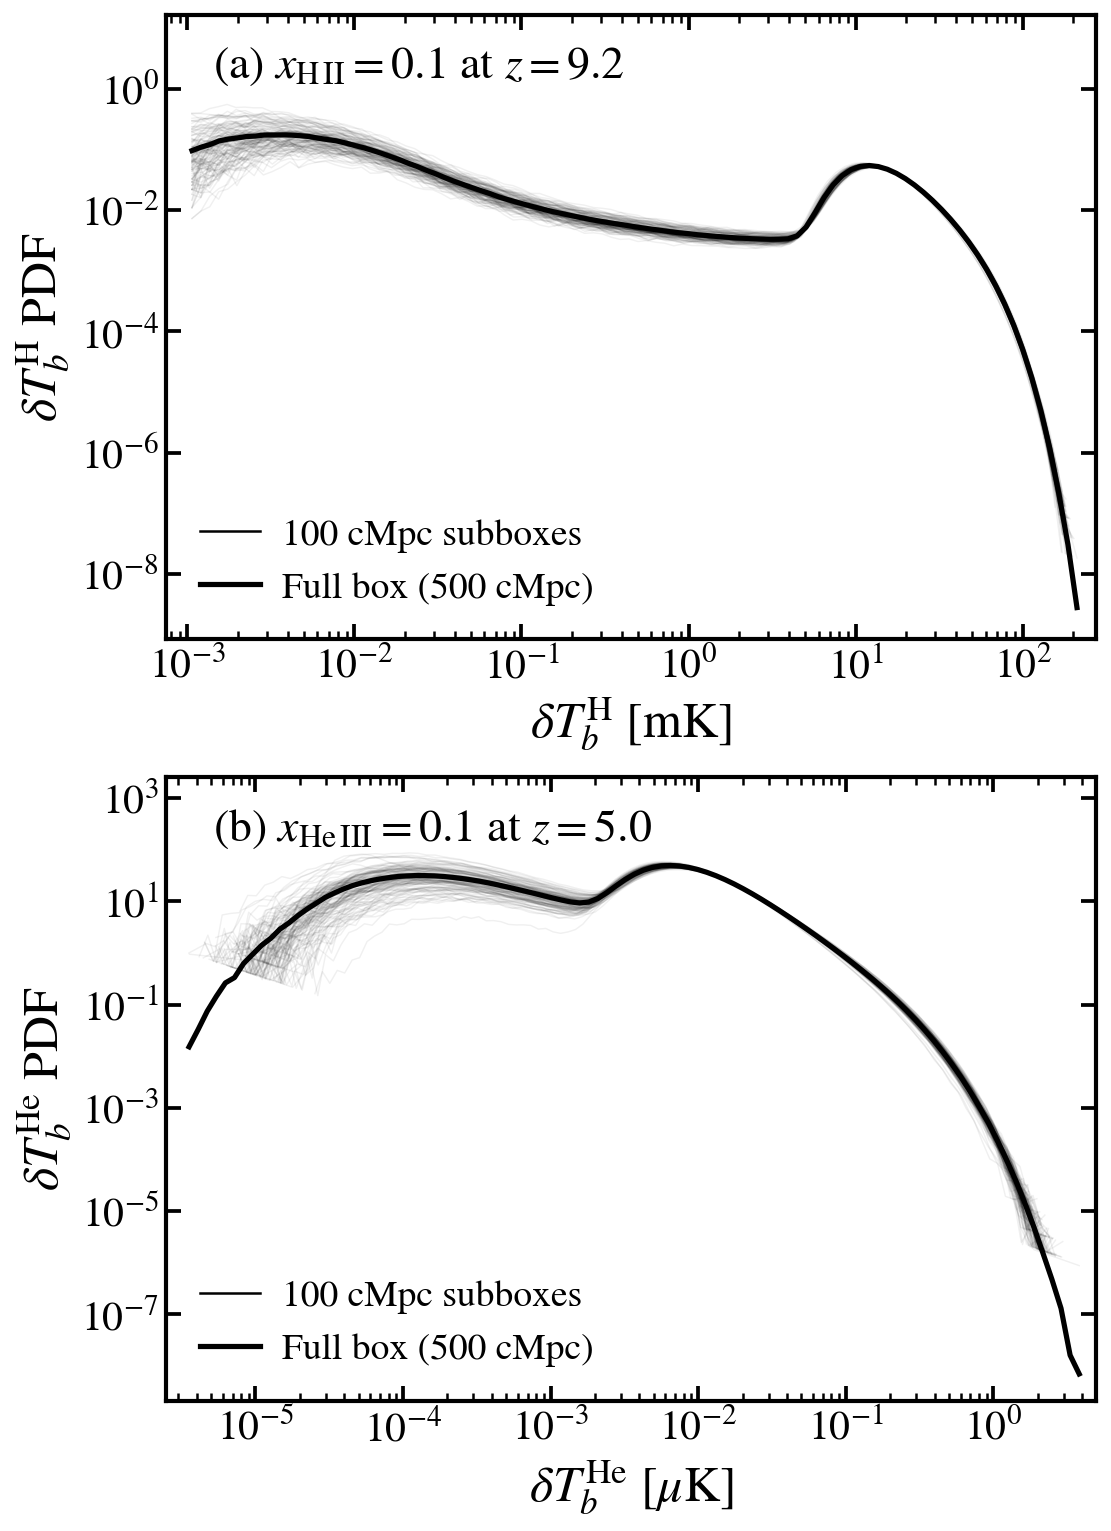

Saved: /orcd/data/mvogelsb/004/chcho/cell_by_cell/hydrogen/Tb_H/VID/VID_boxtest_HHe_onecolumn.pdf


In [2]:
import numpy as np
import pandas as pd
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt

# --------------------------------
# Publication-quality style
# --------------------------------
mpl.rcParams.update({
    "font.size": 18,          # [CHANGED] was 16
    "axes.labelsize": 24,     # [CHANGED] was 20
    "axes.titlesize": 24,     # [CHANGED] was 20
    "xtick.labelsize": 20,    # [CHANGED] was 16
    "ytick.labelsize": 20,    # [CHANGED] was 16
    "axes.linewidth": 2.0,
    "xtick.major.width": 1.8,
    "ytick.major.width": 1.8,
    "xtick.minor.width": 1.2,
    "ytick.minor.width": 1.2,
    "xtick.major.size": 7,
    "ytick.major.size": 7,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})

STATS_DIR = "/orcd/data/mvogelsb/004/chcho/cell_by_cell/hydrogen/Tb_H/VID"
SNAP_H    = 177
SNAP_HE   = 406

STATS_DIR_He = "/orcd/data/mvogelsb/004/chcho/cell_by_cell/helium/Tb_He/VID"
def load_positive_side(fpath):
    df = pd.read_csv(fpath)
    if df.empty or "side" not in df.columns:
        return None
    d = df[(df["side"] == "pos") & (df["vid_prob"] > 0)]
    return d.sort_values("Tb") if not d.empty else None


def panel_positive_vid(ax, full_csv, subbox_glob_pattern, xlabel, ylabel, panel_label):
    """panel_label now carries the full annotation text (letter + x_ion + z),
    supplied by the caller — no separate z text block anymore."""

    subbox_files = sorted(glob.glob(subbox_glob_pattern))
    if not subbox_files:
        raise FileNotFoundError(f"No subbox CSVs matching {subbox_glob_pattern}")

    all_tb, all_vid = [], []
    first = True
    for fpath in subbox_files:
        d = load_positive_side(fpath)
        if d is None:
            continue
        ax.plot(
            d["Tb"], d["vid_prob"],
            color="black", alpha=0.06, lw=0.7,
            label="100 cMpc subboxes" if first else None,
            zorder=2,
        )
        all_tb.append(d["Tb"].values)
        all_vid.append(d["vid_prob"].values)
        first = False

    d_full = load_positive_side(full_csv)
    if d_full is None:
        raise ValueError(f"No usable positive-side data in {full_csv}")

    ax.plot(
        d_full["Tb"], d_full["vid_prob"],
        color="black", lw=2.5, zorder=5,
        label="Full box (500 cMpc)",
    )
    all_tb.append(d_full["Tb"].values)
    all_vid.append(d_full["vid_prob"].values)

    ax.set_xscale("log")
    ax.set_yscale("log")

    tb_all  = np.concatenate(all_tb)
    vid_all = np.concatenate(all_vid)
    ax.set_xlim(tb_all.min() * 0.7, tb_all.max() * 1.3)
    # [CHANGED] more headroom above the curves so the panel-label text
    # (placed at y=0.93 in axes coords) has clear log-decades of empty
    # space above the data rather than sitting close to the peak
    ax.set_ylim(vid_all.min() * 0.3, vid_all.max() * 30.0)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)   # [CHANGED] now passed per panel, not hardcoded

    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.minorticks_on()

    # [CHANGED] single annotation carrying letter + ionization fraction + z
    ax.text(
        0.05, 0.95, panel_label,
        transform=ax.transAxes,
        fontsize=22, ha="left", va="top",
    )

    leg = ax.legend(fontsize=18, loc="lower left", frameon=False,
                     handlelength=1.6, handletextpad=0.6)
    for line in leg.get_lines():
        line.set_alpha(1.0)
        if line.get_label() == "100 cMpc subboxes":
            line.set_linewidth(1.2)


fig, (ax_h, ax_he) = plt.subplots(
    2, 1,
    figsize=(8, 12),
    gridspec_kw={"hspace": 0.22},
)

panel_positive_vid(
    ax_h,
    full_csv=f"{STATS_DIR}/VID_full_{SNAP_H:03d}.csv",
    subbox_glob_pattern=f"{STATS_DIR}/VID_{SNAP_H:03d}_sub_*.csv",
    xlabel=r"$\delta T_b^{\mathrm{H}}\ [\mathrm{mK}]$",
    ylabel=r"$\delta T^\mathrm{H}_b$ PDF",
    panel_label=r"(a) $x_\mathrm{H\,II} = 0.1$ at $z=9.2$",
)

panel_positive_vid(
    ax_he,
    full_csv=f"{STATS_DIR_He}/VID_He_full_{SNAP_HE:03d}.csv",
    subbox_glob_pattern=f"{STATS_DIR_He}/VID_He_{SNAP_HE:03d}_sub_*.csv",
    xlabel=r"$\delta T_b^{\mathrm{He}}\ [\mu\mathrm{K}]$",
    ylabel=r"$\delta T^\mathrm{He}_b$ PDF",
    panel_label=r"(b) $x_\mathrm{He\,III} = 0.1$ at $z=5.0$",
)

plt.tight_layout()
out = f"{STATS_DIR}/VID_boxtest_HHe_onecolumn.pdf"
fig.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

---

# Previous code

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob

def plot_vid_subbox_comparison(
    snap: int,
    z: float,
    stats_dir: str = "./bubble_stats",
    linthresh: float = 0.001,
    figsize: tuple = (8, 6),
    save_path: str = None,
):
    """
    Overlay all 125 subbox VIDs (faint) against the full-box VID (bold).

    Assumes CSV columns from save_vid_to_csv:
        pos columns: T_pos, VID_pos
        neg columns: T_neg, VID_neg
    Adjust column names below if yours differ.
    """

    fig, ax = plt.subplots(figsize=figsize)

    # -----------------------------------------------
    # Load and plot 125 subbox VIDs
    # -----------------------------------------------
    subbox_files = sorted(glob.glob(f"{stats_dir}/VID_{snap:03d}_sub_*.csv"))

    if len(subbox_files) == 0:
        raise FileNotFoundError(f"No subbox VID files found in {stats_dir}")

    sub_pos_list = []
    sub_neg_list = []

    for i, fpath in enumerate(subbox_files):
        df = pd.read_csv(fpath)

        # --- positive side ---
        mask_pos = df["VID_pos"] > 0
        if mask_pos.any():
            ax.plot(
                df.loc[mask_pos, "T_pos"],
                df.loc[mask_pos, "VID_pos"],
                color="steelblue", alpha=0.12, lw=0.7,
                label="Subboxes (100 cMpc)" if i == 0 else None,
            )
            sub_pos_list.append(df.loc[mask_pos].set_index("T_pos")["VID_pos"])

        # --- negative side ---
        mask_neg = df["VID_neg"] > 0
        if mask_neg.any():
            ax.plot(
                df.loc[mask_neg, "T_neg"],
                df.loc[mask_neg, "VID_neg"],
                color="tomato", alpha=0.12, lw=0.7,
                label="Subboxes negative (100 cMpc)" if i == 0 else None,
            )
            sub_neg_list.append(df.loc[mask_neg].set_index("T_neg")["VID_neg"])

    # -----------------------------------------------
    # Subbox mean + 1-sigma envelope
    # -----------------------------------------------
    def plot_envelope(ax, series_list, color, label):
        """Align on common index, interpolate, compute mean ± std."""
        combined = pd.concat(series_list, axis=1).sort_index()
        combined = combined.interpolate(method="index", limit_direction="both")
        mean = combined.mean(axis=1)
        std  = combined.std(axis=1)
        ax.plot(mean.index, mean.values, color=color, lw=1.5,
                ls="--", label=f"{label} mean")
        ax.fill_between(mean.index,
                        (mean - std).clip(lower=1e-10),
                        (mean + std),
                        color=color, alpha=0.15, label=f"{label} ±1σ")

    if sub_pos_list:
        plot_envelope(ax, sub_pos_list, color="steelblue",
                      label="Subbox +$T_b$")
    if sub_neg_list:
        plot_envelope(ax, sub_neg_list, color="tomato",
                      label="Subbox $-T_b$")

    # -----------------------------------------------
    # Full-box VID on top
    # -----------------------------------------------
    full_file = f"{stats_dir}/VID_full_{snap:03d}.csv"
    df_full = pd.read_csv(full_file)

    mask_pos = df_full["VID_pos"] > 0
    mask_neg = df_full["VID_neg"] > 0

    if mask_pos.any():
        ax.plot(
            df_full.loc[mask_pos, "T_pos"],
            df_full.loc[mask_pos, "VID_pos"],
            color="navy", lw=2.2, zorder=5,
            label="Full box (500 cMpc)",
        )
    if mask_neg.any():
        ax.plot(
            df_full.loc[mask_neg, "T_neg"],
            df_full.loc[mask_neg, "VID_neg"],
            color="darkred", lw=2.2, zorder=5,
            label="Full box negative (500 cMpc)",
        )

    # -----------------------------------------------
    # Axes: symlog x (handles ±Tb), log y
    # -----------------------------------------------
    ax.set_xscale("symlog", linthresh=linthresh)
    ax.set_yscale("log")

    ax.set_xlabel(r"$T_b$ [mK]", fontsize=13)
    ax.set_ylabel(r"$\Delta^2_{\rm VID}$  or  $P(T_b)$", fontsize=13)
    ax.set_title(
        rf"VID box-size test — Snap {snap:03d}, $z={z:.2f}$"
        "\n"
        r"100 cMpc subboxes (faint) vs 500 cMpc full box (bold)",
        fontsize=11,
    )

    ax.legend(fontsize=8, ncol=2, loc="upper left")
    ax.grid(True, which="both", ls=":", lw=0.5, alpha=0.5)

    plt.tight_layout()

    out = save_path or f"./bubble_stats/VID_boxtest_{snap:03d}.pdf"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  Saved: {out}")

  125 subbox VIDs saved.


KeyError: 'VID_pos'

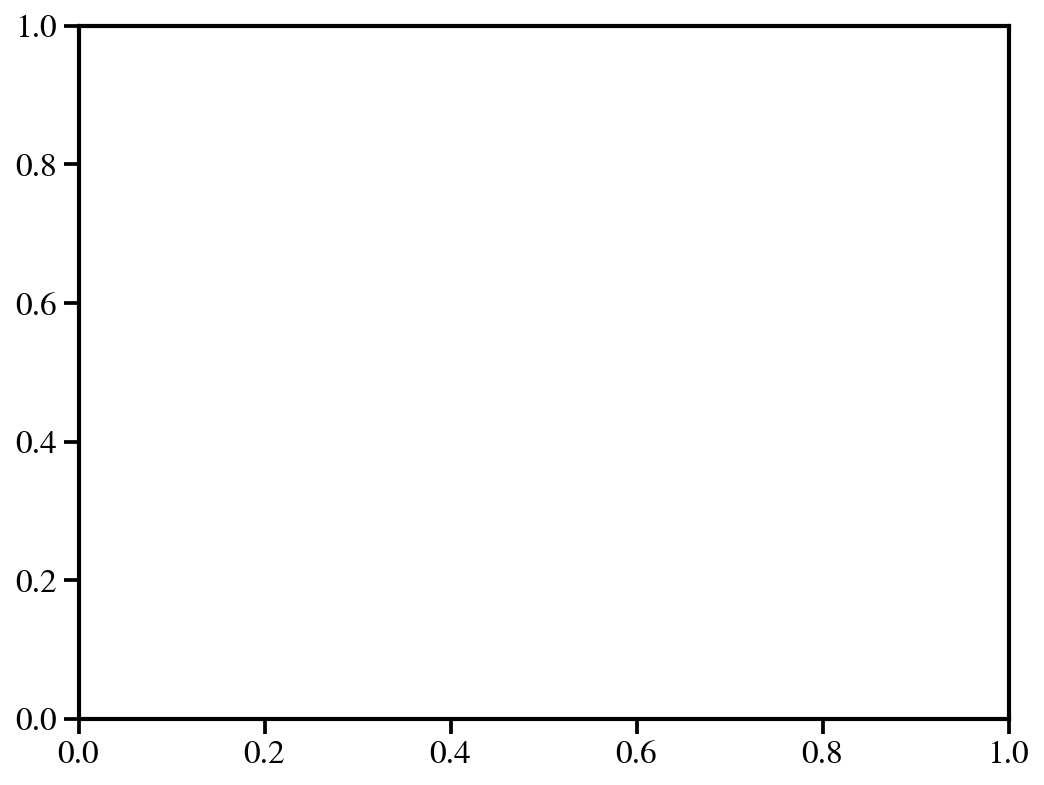

In [8]:
print(f"  {subbox_idx} subbox VIDs saved.")

    # --- NEW ---
plot_vid_subbox_comparison(
    snap=snap,
    z=z,
    stats_dir="./bubble_stats",
    linthresh=0.001,
)

VID_177.csv is saved!


/tmp/ipykernel_707193/521729793.py:391: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


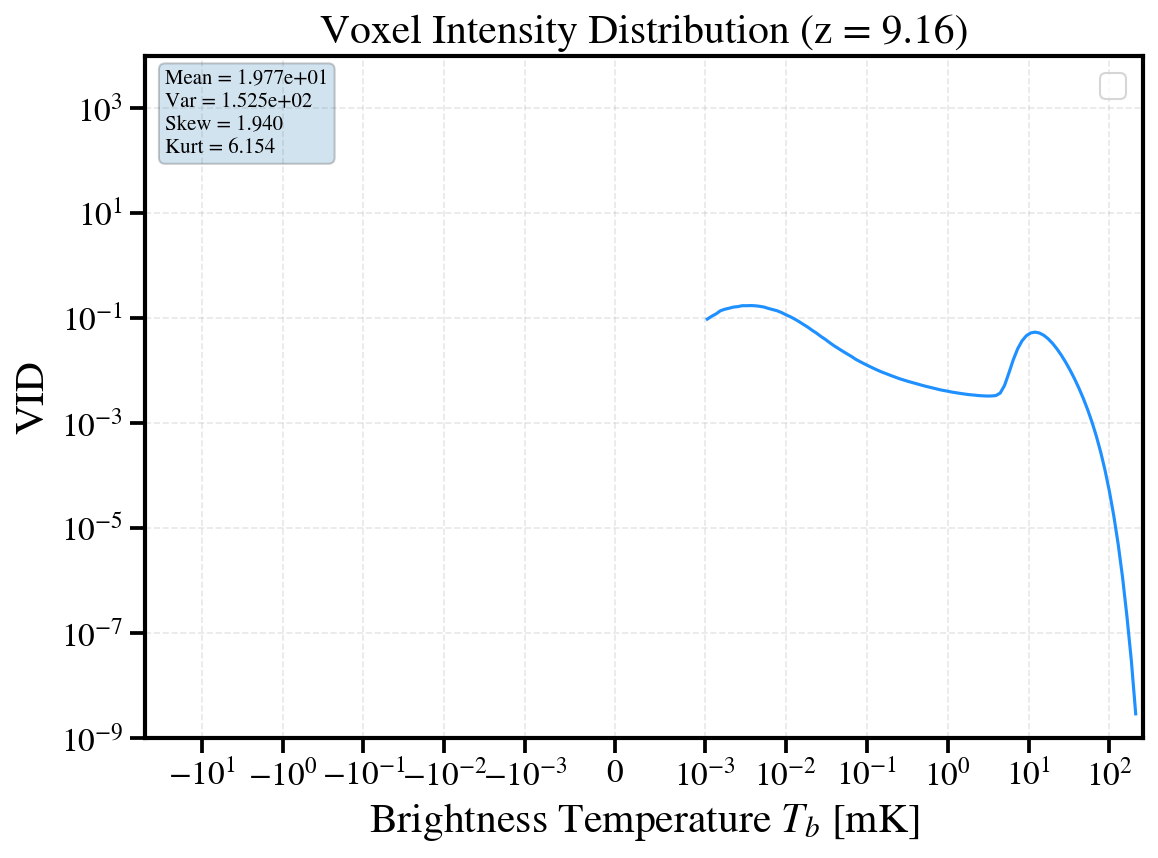

In [43]:
DIR = "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_H/Tb_H"

PS_files = [
    f"{DIR}/PS_177.out",
    #f"{DIR}/PS_203.out",
    #f"{DIR}/PS_220.out",
    #f"{DIR}/PS_242.out",
    #f"{DIR}/PS_264.out",
    #f"{DIR}/PS_283.out",
    #f"{DIR}/PS_300.out",
    #f"{DIR}/PS_318.out",
    #f"{DIR}/PS_338.out",
]

voxel_res = 500 / 640

for PS_file in PS_files:

    # -----------------------------------
    # Snapshot number
    # -----------------------------------
    snap = int(PS_file.split("_")[-1].split(".")[0])

    hdf5_file = f"/orcd/data/mvogelsb/004/chcho/compute_J_alpha_H/Tb_H/RIN_{snap:03d}.hdf5"

    # -----------------------------------
    # Redshift
    # -----------------------------------
    z = get_redshift(PS_file)

    # -----------------------------------
    # NEW VID function
    # -----------------------------------
    results_pos, results_neg, stats = calculate_vid_logbins(
        hdf5_file=hdf5_file,
        resolution_cMpc=voxel_res,
        bins=100
    )


    #
    # Saving the results
    #
    save_vid_to_csv(
        results_pos,
        results_neg,
        stats,
        filename=f"./bubble_stats/All_VID_{snap:03d}.csv"
    )
    print(f"VID_{snap:03d}.csv is saved!")

    # -----------------------------------
    # NEW plotting function
    # -----------------------------------
    plot_vid(
        results_pos,
        results_neg,
        z=z,
        stats=stats,
        linthresh=0.001
    )

## Hydrogen VID (LUMINA)

/tmp/ipykernel_707193/2817616901.py:267: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


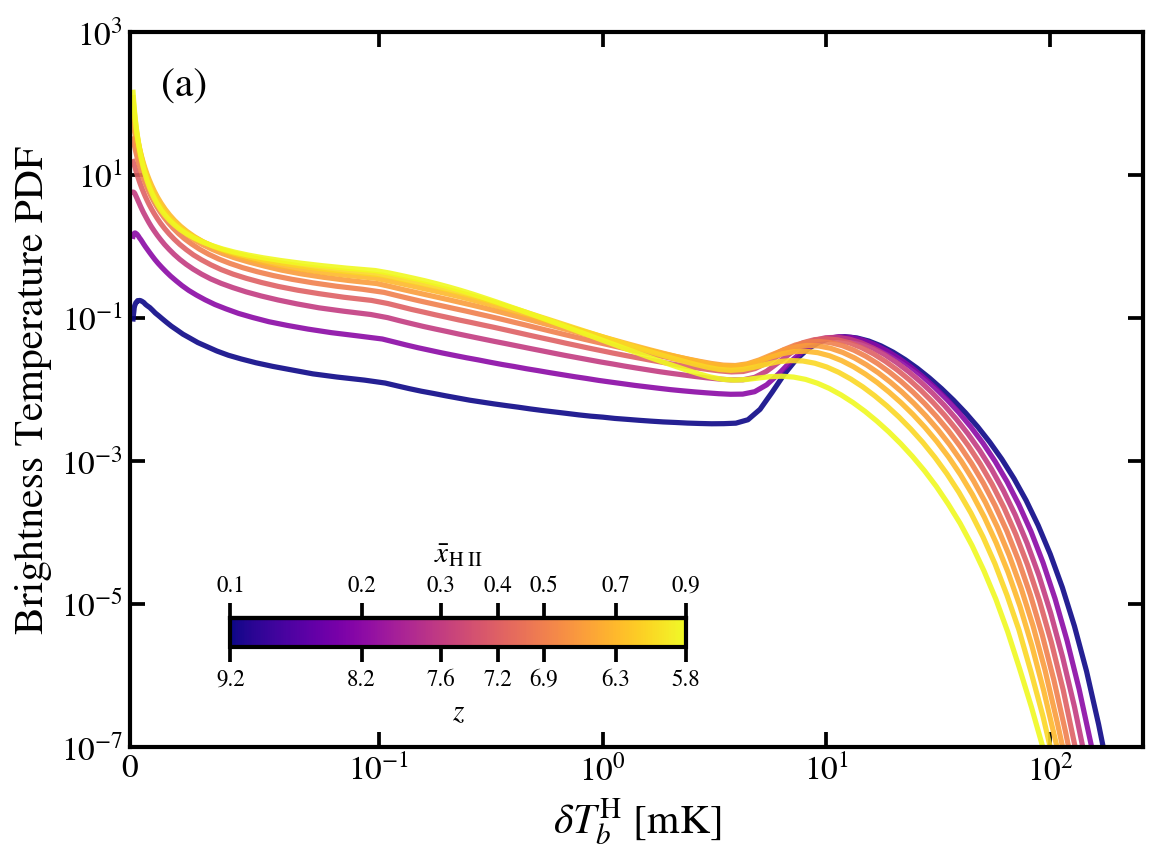

In [47]:
# --------------------------------
# Input files
# --------------------------------

PS_files = [
    "/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/Tb_H/PS_177.out",
    "/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/Tb_H/PS_203.out",
    "/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/Tb_H/PS_220.out",
    "/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/Tb_H/PS_242.out",
    "/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/Tb_H/PS_264.out",
    "/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/Tb_H/PS_283.out",
    "/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/Tb_H/PS_300.out",
    "/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/Tb_H/PS_318.out",
    "/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/Tb_H/PS_338.out",
]

# --------------------------------
# Run
# --------------------------------

plot_vid_from_csv(PS_files)

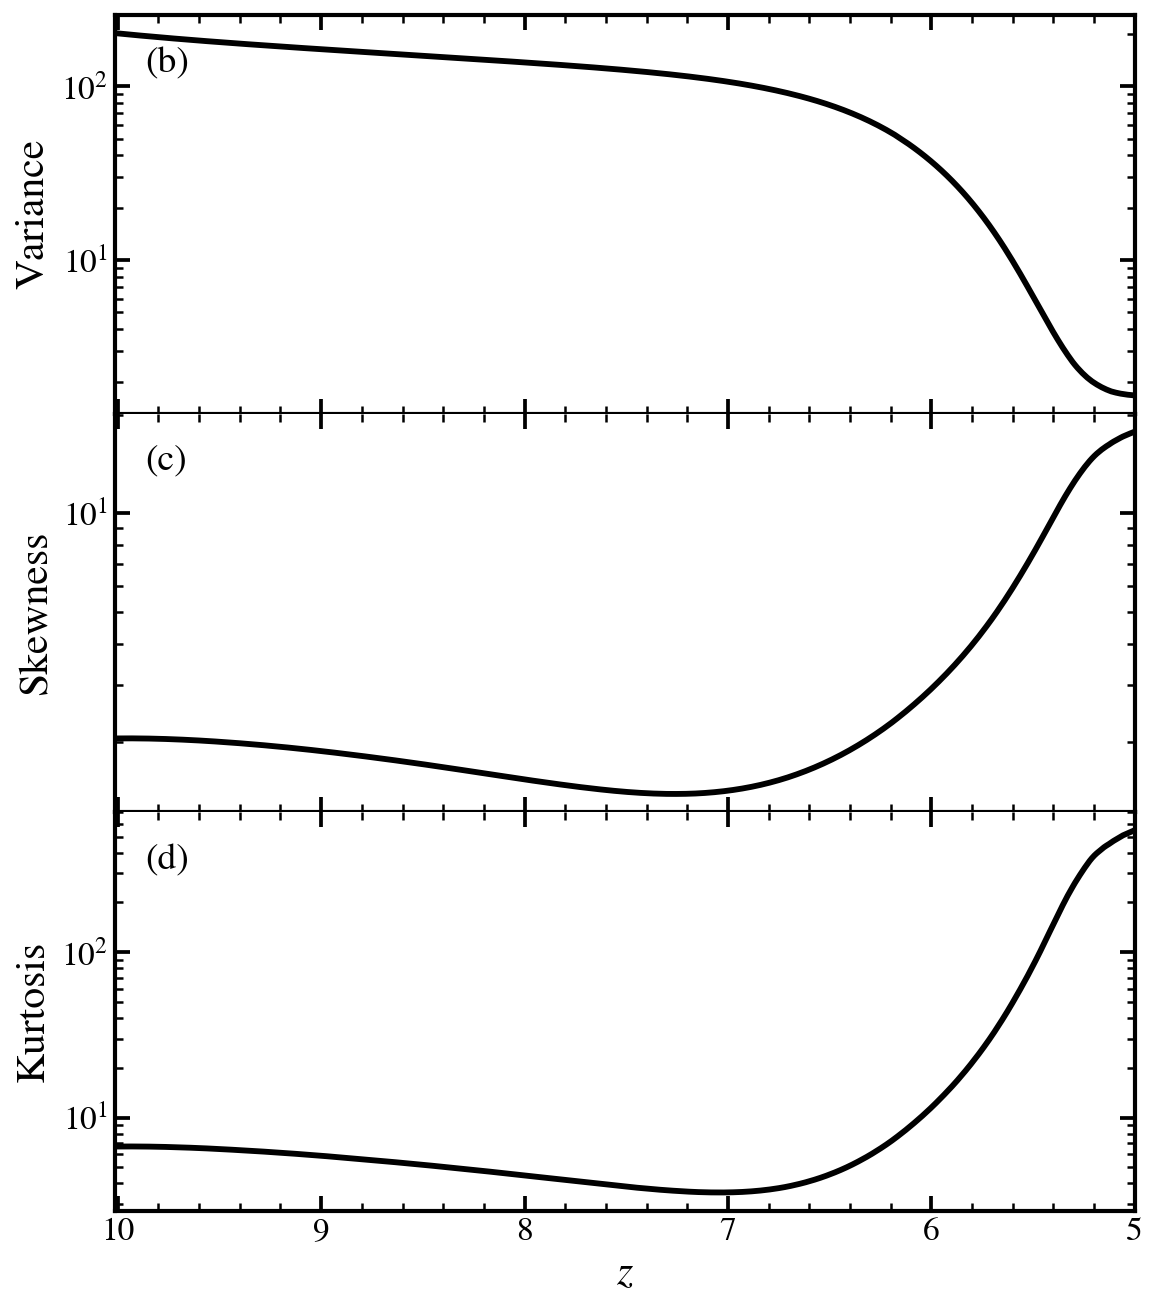

78707

In [11]:
# =====================================
# Read data
# =====================================

df = pd.read_csv("vid_stats_summary_156_406.csv")

z = df["z"]

# =====================================
# Better colors
# =====================================

colors = {
    "variance": "black", #royalblue
    "skewness": "black", #deeppink
    "kurtosis": "black" #limegreen

}

labels = [
    r"Variance",
    r"Skewness",
    r"Kurtosis"
]

cols = [
    "variance",
    "skewness",
    "kurtosis"
]

panel_labels = [
    r"(b)",
    r"(c)",
    r"(d)"
]

# =====================================
# Figure (attached stacked panels)
# =====================================

fig, axes = plt.subplots(
    3, 1,
    figsize=(8, 9),
    sharex=True,
    gridspec_kw={"hspace": 0.0}   # <- attach panels tightly
)

# =====================================
# Plot each panel
# =====================================

for i, (ax, col, label, panel) in enumerate(
    zip(axes, cols, labels, panel_labels)
):

    values = df[col].copy()

    # safe for log scale
    values = np.where(values > 0, values, np.nan)

    ax.plot(
        z,
        values,
        color=colors[col],
        linewidth=2.8
    )

    # reverse redshift direction (high -> low)
    ax.set_xlim(max(z), min(z))

    # log y-axis
    ax.set_yscale("log")

    # ticks
    ax.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True
    )

    ax.minorticks_on()

    # y label
    ax.set_ylabel(label)

    # remove top spine overlap look
    if i != 0:
        ax.spines["top"].set_visible(False)

    # panel label
    ax.text(
        0.03,
        0.92,
        panel,
        transform=ax.transAxes,
        fontsize=18,
        ha="left",
        va="top"
    )

# =====================================
# X-axis only at bottom
# =====================================

axes[-1].set_xlabel(r"$z$")

for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)

# =====================================
# Tight layout
# =====================================

plt.tight_layout()

# plt.savefig(
#     "VID_statistics_stacked_log.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

gc.collect()

## Helium VID (LUMINA)

/tmp/ipykernel_2304531/4078841039.py:281: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


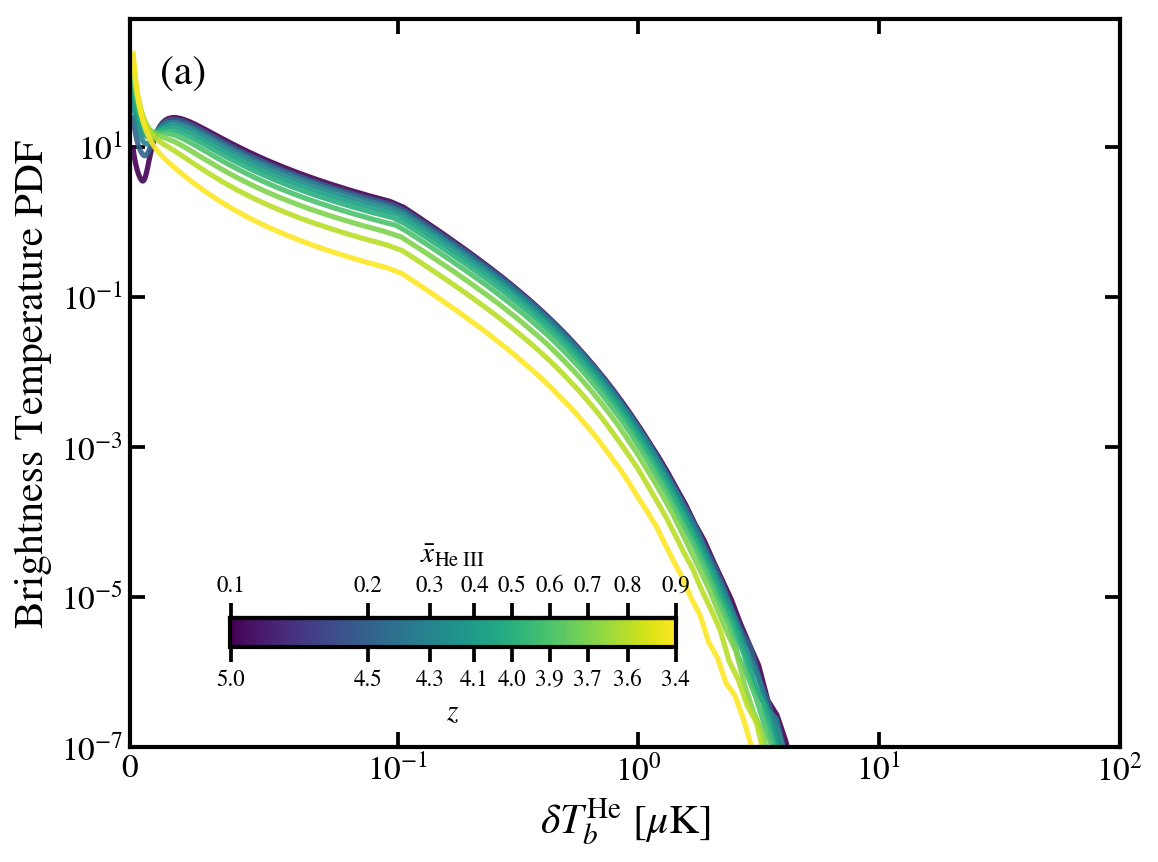

In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# --------------------------------
# Publication-quality style
# --------------------------------

mpl.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,

    # thicker axis box
    "axes.linewidth": 2.0,

    # thicker major/minor ticks
    "xtick.major.width": 1.8,
    "ytick.major.width": 1.8,
    "xtick.minor.width": 1.2,
    "ytick.minor.width": 1.2,

    "xtick.major.size": 7,
    "ytick.major.size": 7,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,

    # figure quality
    "figure.dpi": 150,
    "savefig.dpi": 300,
})

# --------------------------------
# Input files
# --------------------------------

PS_files = [
    #"./TS_TK/He/Tb/PS_Tb_He_156.out",
    #"./TS_TK/He/Tb/PS_Tb_He_169.out",
    #"./TS_TK/He/Tb/PS_Tb_He_181.out",
    #"./TS_TK/He/Tb/PS_Tb_He_195.out",
    #"./TS_TK/He/Tb/PS_Tb_He_209.out",
    #"./TS_TK/He/Tb/PS_Tb_He_224.out",
    #"./TS_TK/He/Tb/PS_Tb_He_255.out",
    #"./TS_TK/He/Tb/PS_Tb_He_289.out",
    #"./TS_TK/He/Tb/PS_Tb_He_325.out",
    #"./TS_TK/He/Tb/PS_Tb_He_364.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_406.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_450.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_471.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_487.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_500.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_514.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_529.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_558.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_596.out",
]

# --------------------------------
# Main function
# --------------------------------

def plot_vid_from_csv(PS_files):

    fig, ax = plt.subplots(figsize=(8, 6))

    zs = []
    snaps = []

    # --------------------------------
    # Collect redshifts
    # --------------------------------

    for PS_file in PS_files:
        snap = int(PS_file.split("_")[-1].split(".")[0])
        z = get_redshift(PS_file)

        snaps.append(snap)
        zs.append(z)

    zs = np.array(zs)

    # --------------------------------
    # Colormap
    # --------------------------------

    cmap = plt.get_cmap("viridis_r")
    norm = mpl.colors.Normalize(
        vmin=zs.min(),
        vmax=zs.max()
    )

    # --------------------------------
    # Plot curves
    # --------------------------------

    for snap, z in zip(snaps, zs):

        filename = f"./bubble_stats/All_He_VID_{snap:03d}.csv"

        Tb, vid = load_vid_csv(filename)

        # avoid log(0)
        vid = np.where(
            vid > 0,
            vid,
            1e-20
        )

        ax.plot(
            Tb,
            vid,
            color=cmap(norm(z)),
            lw=2.5,
            alpha=0.9
        )

    # --------------------------------
    # Axis scales
    # --------------------------------

    ax.set_xscale(
        "symlog",
        linthresh=0.1
    )

    ax.set_yscale("log")

    # --------------------------------
    # Labels
    # --------------------------------

    ax.set_xlabel(
        r"$\delta T_b^{\mathrm{He}}\ [\mu$K]"
    )

    # Better than just "VID"
    ax.set_ylabel(
        "Brightness Temperature PDF"
    )

    # --------------------------------
    # Limits
    # --------------------------------

    ax.set_xlim(0.0, 100)
    ax.set_ylim(1e-7, 5e2)

    # --------------------------------
    # Tick style
    # --------------------------------

    ax.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True
    )

    ax.minorticks_on()

    # --------------------------------
    # Embedded horizontal colorbar
    # --------------------------------

    sm = mpl.cm.ScalarMappable(
        cmap=cmap,
        norm=norm
    )
    sm.set_array([])

    cax = inset_axes(
        ax,
        width="45%",
        height="4%",
        loc="lower left",
        borderpad=3.0
    )

    cbar = fig.colorbar(
        sm,
        cax=cax,
        orientation="horizontal"
    )

    cbar.set_label(
        r"$z$",
        fontsize=14
    )

    cbar.ax.tick_params(
        labelsize=11
    )

    # --------------------------------
    # Exact z ↔ x_HII mapping
    # --------------------------------

    # exact mapping
    xhii_vals = np.array([
        0.90,
        0.80,
        0.70,
        0.60,
        0.50,
        0.40,
        0.30,
        0.20,
        0.10
    ])
    
    z_match = np.array([
        3.439090,
        3.606240,
        3.746897,
        3.880495,
        4.011606,
        4.144300,
        4.299100,
        4.517370,
        4.999257
    ])

    # bottom ticks = z
    cbar.set_ticks(z_match)
    cbar.set_ticklabels(
        [f"{z:.1f}" for z in z_match]
    )

    # high-z on left
    cbar.ax.invert_xaxis()

    # --------------------------------
    # Top axis = ionized fraction
    # --------------------------------

    top_ax = cbar.ax.twiny()
    top_ax.set_xlim(
        cbar.ax.get_xlim()
    )

    top_ax.set_xticks(z_match)
    top_ax.set_xticklabels(
        [f"{x:.1f}" for x in xhii_vals],
        fontsize=11
    )

    top_ax.set_xlabel(
        r"$\bar{x}_{\mathrm{He \ III}}$",
        fontsize=14,
        labelpad=6
    )

    # --------------------------------
    # Panel label
    # --------------------------------

    ax.text(
        0.03,
        0.95,
        r"(a)",
        transform=ax.transAxes,
        fontsize=20,
        ha="left",
        va="top"
    )

    # --------------------------------
    # Save / show
    # --------------------------------

    # plt.savefig(
    #     "VID_HI.png",
    #     dpi=300,
    #     bbox_inches="tight"
    # )

    plt.tight_layout()
    plt.show()


# --------------------------------
# Run
# --------------------------------

plot_vid_from_csv(PS_files)

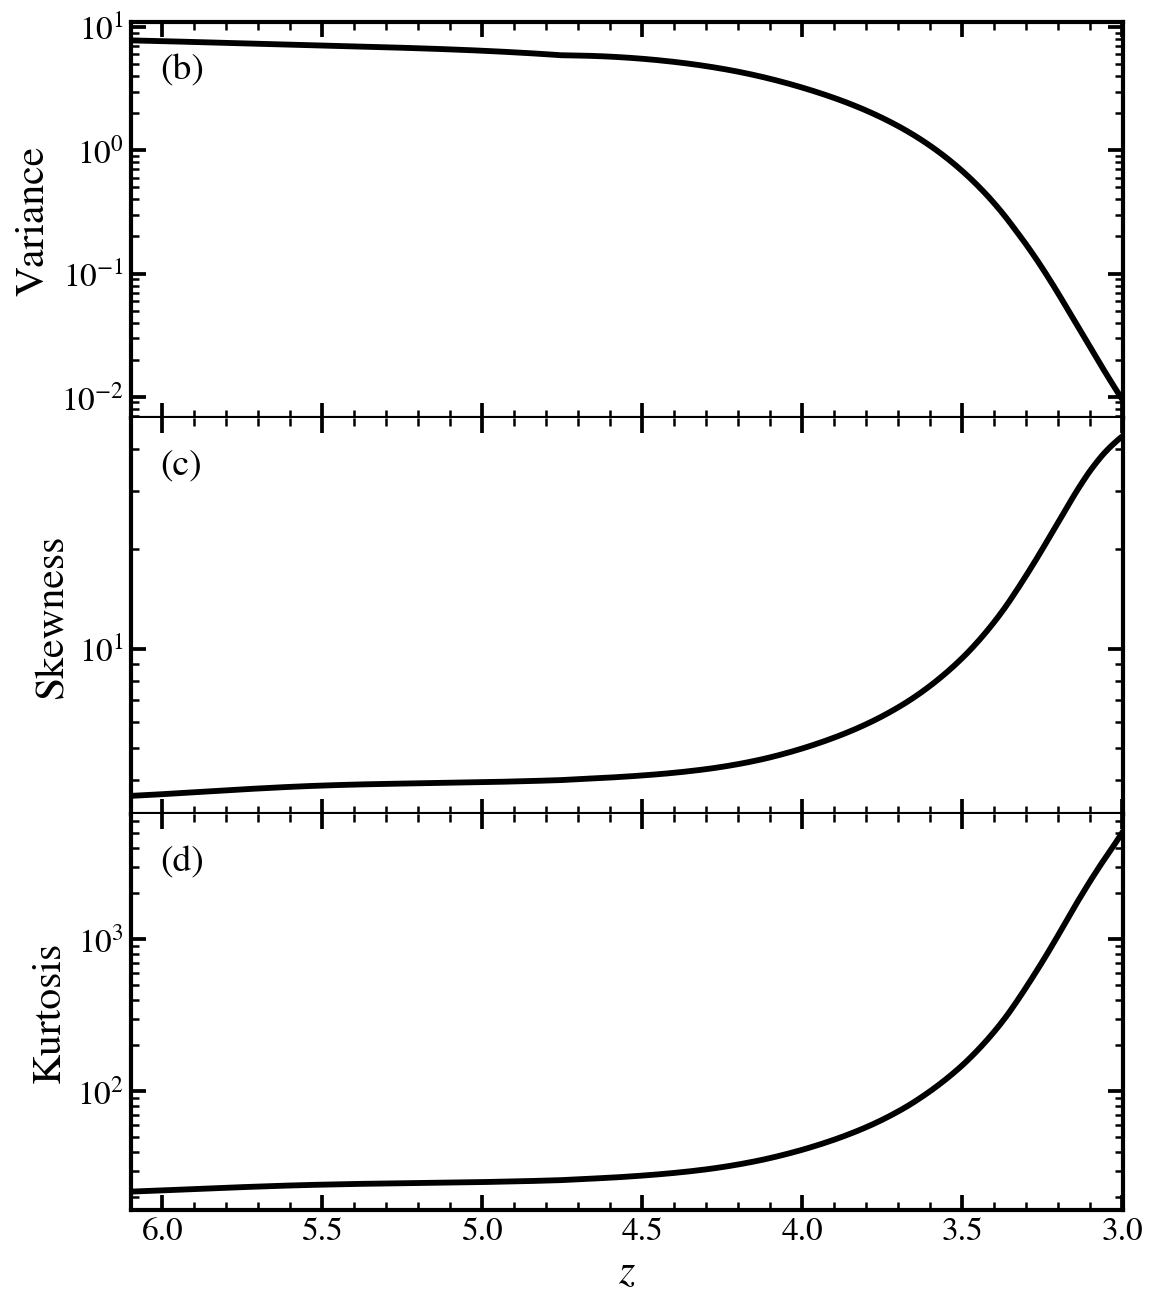

123746

In [14]:
# =====================================
# Read data
# =====================================

df = pd.read_csv("vid_stats_summary_He.csv")

z = df["z"]

# =====================================
# Better colors
# =====================================

colors = {
    "variance": "black",
    "skewness": "black",
    "kurtosis": "black"

}

labels = [
    r"Variance",
    r"Skewness",
    r"Kurtosis"
]

cols = [
    "variance",
    "skewness",
    "kurtosis"
]

panel_labels = [
    r"(b)",
    r"(c)",
    r"(d)"
]

# =====================================
# Figure (attached stacked panels)
# =====================================

fig, axes = plt.subplots(
    3, 1,
    figsize=(8, 9),
    sharex=True,
    gridspec_kw={"hspace": 0.0}   # <- attach panels tightly
)

# =====================================
# Plot each panel
# =====================================

for i, (ax, col, label, panel) in enumerate(
    zip(axes, cols, labels, panel_labels)
):

    values = df[col].copy()

    # safe for log scale
    values = np.where(values > 0, values, np.nan)

    ax.plot(
        z,
        values,
        color=colors[col],
        linewidth=2.8
    )

    # reverse redshift direction (high -> low)
    ax.set_xlim(max(z), min(z))

    # log y-axis
    ax.set_yscale("log")

    # ticks
    ax.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True
    )

    ax.minorticks_on()

    # y label
    ax.set_ylabel(label)

    # remove top spine overlap look
    if i != 0:
        ax.spines["top"].set_visible(False)

    # panel label
    ax.text(
        0.03,
        0.92,
        panel,
        transform=ax.transAxes,
        fontsize=18,
        ha="left",
        va="top"
    )

# =====================================
# X-axis only at bottom
# =====================================

axes[-1].set_xlabel(r"$z$")

for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)

# =====================================
# Tight layout
# =====================================

plt.tight_layout()

# plt.savefig(
#     "VID_statistics_stacked_log.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

gc.collect()

---

## Log bin test

In [8]:
import numpy as np
import h5py
from scipy.stats import skew, kurtosis



def calculate_vid_logbins(hdf5_file, resolution_cMpc, bins=50):

    with h5py.File(hdf5_file, "r") as f:
        tb_cube = f["rin"][:]

    voxels = tb_cube.flatten()

    stats = {
        'mean': np.mean(voxels),
        'variance': np.var(voxels),
        'skewness': skew(voxels),
        'kurtosis': kurtosis(voxels)
    }

    voxel_volume = resolution_cMpc**3
    total_volume = len(voxels) * voxel_volume

    # ===================================
    # POSITIVE
    # ===================================
    vox_pos = voxels[voxels > 0]

    if len(vox_pos) > 0:
        # 1. Set a realistic observational floor
        PHYSICAL_FLOOR = 0.001 # mK (Anything below this is noise to SKA)
        
        # 2. Force vmin to never drop below the floor
        vmin = max(vox_pos.min(), PHYSICAL_FLOOR)
        vmax = vox_pos.max()
        if vmin == vmax:
            vmax = vmin * 1.01

        bins_pos = np.logspace(np.log10(vmin), np.log10(vmax), bins)

        counts_pos, edges_pos = np.histogram(vox_pos, bins=bins_pos)

        centers_pos = 0.5 * (edges_pos[:-1] + edges_pos[1:])
        widths_pos = np.diff(edges_pos)
        widths_pos = np.where(widths_pos > 0, widths_pos, 1e-20)

        vid_prob_pos = counts_pos / (len(voxels) * widths_pos)
        vid_phys_pos = counts_pos / (widths_pos * total_volume)

    else:
        centers_pos = np.array([])
        vid_prob_pos = np.array([])
        vid_phys_pos = np.array([])

    # ===================================
    # NEGATIVE
    # ===================================
    vox_neg = -voxels[voxels < 0]

    if len(vox_neg) > 0:
        vmin, vmax = vox_neg.min(), vox_neg.max()
        if vmin == vmax:
            vmax = vmin * 1.01

        bins_neg = np.logspace(np.log10(vmin), np.log10(vmax), bins)

        counts_neg, edges_neg = np.histogram(vox_neg, bins=bins_neg)

        centers_neg = -0.5 * (edges_neg[:-1] + edges_neg[1:])
        widths_neg = np.diff(edges_neg)
        widths_neg = np.where(widths_neg > 0, widths_neg, 1e-20)

        vid_prob_neg = counts_neg / (len(voxels) * widths_neg)
        vid_phys_neg = counts_neg / (widths_neg * total_volume)

    else:
        centers_neg = np.array([])
        vid_prob_neg = np.array([])
        vid_phys_neg = np.array([])

    results_pos = (centers_pos, vid_prob_pos, vid_phys_pos)
    results_neg = (centers_neg, vid_prob_neg, vid_phys_neg)

    return results_pos, results_neg, stats

def plot_vid(results_pos, results_neg, z, stats=None, linthresh=1.0):

    centers_pos, vid_prob_pos, _ = results_pos
    centers_neg, vid_prob_neg, _ = results_neg

    plt.figure(figsize=(8,6))

    # -----------------------------------
    # Plot BOTH sides
    # -----------------------------------
    if len(centers_pos) > 0:
        plt.plot(centers_pos, vid_prob_pos, color='dodgerblue')

    if len(centers_neg) > 0:
        plt.plot(centers_neg, vid_prob_neg, color='dodgerblue')

    # -----------------------------------
    # Symmetric log scale
    # -----------------------------------
    plt.xscale("symlog", linthresh=linthresh)
    plt.yscale("log")

    # -----------------------------------
    # Labels
    # -----------------------------------
    plt.xlabel("Brightness Temperature $T_b$ [mK]")
    plt.ylabel("VID")

    plt.xlim(-50, 260)
    plt.ylim(1e-9, 1e4)

    plt.grid(True, which="both", ls="--", alpha=0.3)

    plt.title(f"Voxel Intensity Distribution (z = {z:.2f})")

    plt.legend()

    # -----------------------------------
    # Stats
    # -----------------------------------
    if stats is not None:
        textstr = (
            f"Mean = {stats['mean']:.3e}\n"
            f"Var = {stats['variance']:.3e}\n"
            f"Skew = {stats['skewness']:.3f}\n"
            f"Kurt = {stats['kurtosis']:.3f}"
        )

        plt.text(0.02, 0.98, textstr,
                 transform=plt.gca().transAxes,
                 verticalalignment='top',
                 fontsize=10,
                 bbox=dict(boxstyle="round", alpha=0.2))

    plt.tight_layout()
    plt.show()
    

def save_vid_to_csv(results_pos, results_neg, stats, filename):
    
    centers_pos, vid_prob_pos, vid_phys_pos = results_pos
    centers_neg, vid_prob_neg, vid_phys_neg = results_neg

    # Positive side
    df_pos = pd.DataFrame({
        "Tb": centers_pos,
        "vid_prob": vid_prob_pos,
        "vid_phys": vid_phys_pos,
        "side": "pos"
    })

    # Negative side
    df_neg = pd.DataFrame({
        "Tb": centers_neg,
        "vid_prob": vid_prob_neg,
        "vid_phys": vid_phys_neg,
        "side": "neg"
    })

    # Combine
    df = pd.concat([df_neg, df_pos], ignore_index=True)

    # Save
    df.to_csv(filename, index=False)

    # Save stats separately
    stats_file = filename.replace(".csv", "_stats.csv")
    pd.DataFrame([stats]).to_csv(stats_file, index=False)

NameError: name 'get_redshift' is not defined

## LUMINA Hydrogen

In [6]:
DIR = "/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/Tb_H"

PS_files = [
    f"{DIR}/PS_177.out",
    f"{DIR}/PS_203.out",
    f"{DIR}/PS_220.out",
    f"{DIR}/PS_242.out",
    f"{DIR}/PS_264.out",
    f"{DIR}/PS_283.out",
    f"{DIR}/PS_300.out",
    f"{DIR}/PS_318.out",
    f"{DIR}/PS_338.out",
]

voxel_res = 500 / 640

for PS_file in PS_files:

    # -----------------------------------
    # Snapshot number
    # -----------------------------------
    snap = int(PS_file.split("_")[-1].split(".")[0])

    hdf5_file = f"/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/H/Tb/Tb_H_{snap:03d}.hdf5"

    # -----------------------------------
    # Redshift
    # -----------------------------------
    z = get_redshift(PS_file)

    # -----------------------------------
    # NEW VID function
    # -----------------------------------
    results_pos, results_neg, stats = calculate_vid_logbins(
        hdf5_file=hdf5_file,
        resolution_cMpc=voxel_res,
        bins=100
    )


    #
    # Saving the results
    #
    save_vid_to_csv(
        results_pos,
        results_neg,
        stats,
        filename=f"./bubble_stats/new_VID_{snap:03d}.csv"
    )
    print(f"VID_{snap:03d}.csv is saved!")

    # -----------------------------------
    # NEW plotting function
    # -----------------------------------
    plot_vid(
        results_pos,
        results_neg,
        z=z,
        stats=stats,
        linthresh=0.001
    )

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/H/Tb/Tb_H_177.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl

def plot_multiple_vid(vid_list, zs, linthresh=0.1):
    """
    Plot multiple VID curves (positive side only) with redshift colormap

    Parameters:
    - vid_list: list of (results_pos, results_neg, stats)
    - zs: array of redshifts
    """

    plt.figure(figsize=(8,6))

    # -----------------------------------
    # Colormap setup
    # -----------------------------------
    cmap = plt.get_cmap("plasma_r")   # high z dark, low z bright
    norm = mpl.colors.Normalize(vmin=np.min(zs), vmax=np.max(zs))

    # -----------------------------------
    # Loop over snapshots
    # -----------------------------------
    for (results_pos, _, _), z in zip(vid_list, zs):

        centers_pos, vid_prob_pos, _ = results_pos

        if len(centers_pos) == 0:
            continue

        color = cmap(norm(z))

        plt.plot(
            centers_pos,
            vid_prob_pos,
            color=color,
            lw=2,
            label=f"z={z:.2f}"
        )

    # -----------------------------------
    # Axes scaling
    # -----------------------------------
    plt.xscale("symlog", linthresh=linthresh)
    plt.yscale("log")

    plt.xlabel("Brightness Temperature $T_b$ [mK]")
    plt.ylabel("VID")

    plt.xlim(0.01, 260)   # positive side only
    plt.ylim(1e-9, 1e4)

    plt.grid(True, which="both", ls="--", alpha=0.3)

    # -----------------------------------
    # Colorbar (BETTER than legend)
    # -----------------------------------
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = plt.colorbar(sm)
    cbar.set_label("Redshift z")

    # Optional legend (can be cluttered)
    # plt.legend()

    plt.title("Voxel Intensity Distribution Evolution")

    plt.tight_layout()
    plt.show()

### Get the Summary file

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# =====================================
# Paths
# =====================================
base_hdf5 = "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_H/Tb_H"
base_ps   = "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_H/Tb_H"
import gc

# =====================================
# Snapshot range
# =====================================
snap_range = range(156, 407)  # 406 included

# =====================================
# Find all files and filter by range
# =====================================
hdf5_files_all = sorted(glob.glob(f"{base_hdf5}/RIN_*.hdf5"))

hdf5_files = []
for f in hdf5_files_all:
    snap = int(f.split("_")[-1].split(".")[0])
    if snap in snap_range:
        hdf5_files.append(f)

print(f"Using {len(hdf5_files)} snapshots in range 156–406")

all_stats = []

# =====================================
# Loop
# =====================================
for hdf5_file in hdf5_files:

    snap = int(hdf5_file.split("_")[-1].split(".")[0])
    ps_file = f"{base_ps}/PS_{snap}.out"

    if not os.path.exists(ps_file):
        print(f"[SKIP] Missing PS file for snapshot {snap}")
        continue

    print(f"Processing snapshot {snap}")

    # -----------------------------------
    # Run VID (unchanged)
    # -----------------------------------
    results_pos, results_neg, stats = calculate_vid_logbins(
        hdf5_file=hdf5_file,
        resolution_cMpc=500/640,
        bins=100
    )

    # -----------------------------------
    # Get redshift
    # -----------------------------------
    z = get_redshift(ps_file)

    # -----------------------------------
    # Store
    # -----------------------------------
    all_stats.append({
        "snap": snap,
        "z": z,
        "mean": stats["mean"],
        "variance": stats["variance"],
        "skewness": stats["skewness"],
        "kurtosis": stats["kurtosis"]
    })
    del results_pos, results_neg, stats
    gc.collect()


# =====================================
# Save CSV
# =====================================
df = pd.DataFrame(all_stats)
df = df.sort_values("z", ascending=False)

df.to_csv("vid_stats_summary_156_406.csv", index=False)

print("Saved: vid_stats_summary_156_406.csv")

Using 25 snapshots in range 156–406
Processing snapshot 156
Processing snapshot 177
Processing snapshot 181
Processing snapshot 190
Processing snapshot 196
Processing snapshot 203
Processing snapshot 209
Processing snapshot 215
Processing snapshot 220
Processing snapshot 227
Processing snapshot 234
Processing snapshot 242
Processing snapshot 255
Processing snapshot 264
Processing snapshot 273
Processing snapshot 283
Processing snapshot 289
Processing snapshot 300
Processing snapshot 309
Processing snapshot 318
Processing snapshot 325
Processing snapshot 332
Processing snapshot 338
Processing snapshot 364
Processing snapshot 406
Saved: vid_stats_summary_156_406.csv


Using 251 snapshots in range 156–406
Processing snapshot 156
Processing snapshot 157
Processing snapshot 158
Processing snapshot 159
Processing snapshot 160
Processing snapshot 161
Processing snapshot 162
Processing snapshot 163
Processing snapshot 164
Processing snapshot 165
Processing snapshot 166
Processing snapshot 167
Processing snapshot 168
Processing snapshot 169
Processing snapshot 170
Processing snapshot 171
Processing snapshot 172
Processing snapshot 173
Processing snapshot 174
Processing snapshot 175
Processing snapshot 176
Processing snapshot 177
Processing snapshot 178
Processing snapshot 179
Processing snapshot 180
Processing snapshot 181
Processing snapshot 182
Processing snapshot 183
Processing snapshot 184
Processing snapshot 185
Processing snapshot 186
Processing snapshot 187
Processing snapshot 188
Processing snapshot 189
Processing snapshot 190
Processing snapshot 191
Processing snapshot 192
Processing snapshot 193
Processing snapshot 194
Processing snapshot 195
Pro

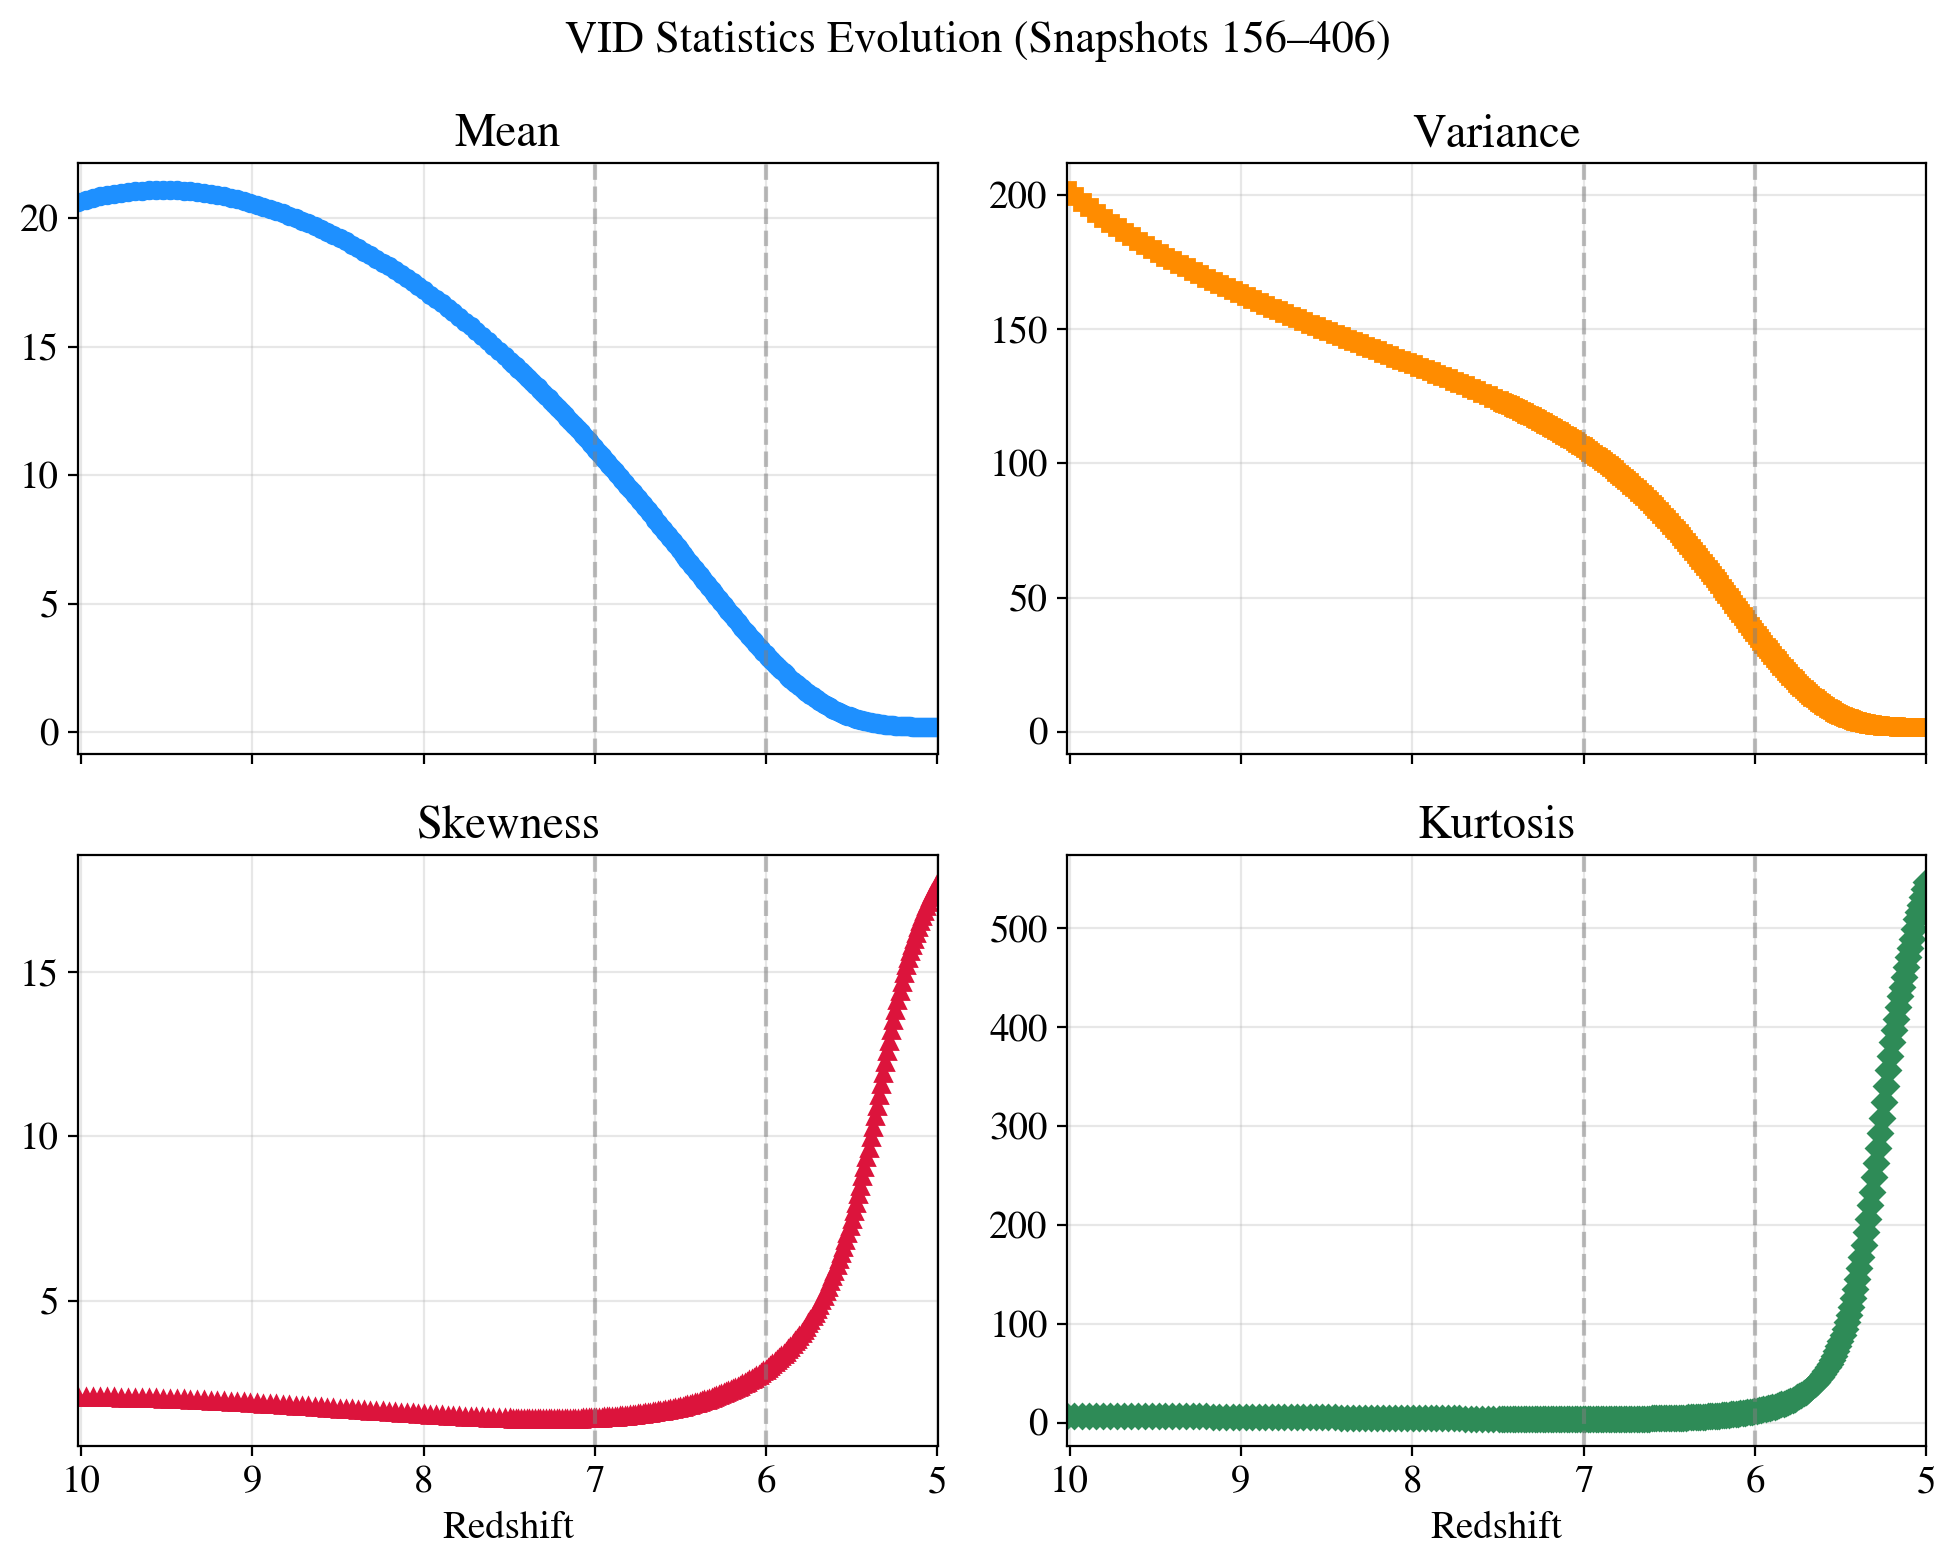

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# =====================================
# Paths
# =====================================
base_hdf5 = "/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/H/Tb"
base_ps   = "./TS_TK/H/Tb"
import gc

# =====================================
# Snapshot range
# =====================================
snap_range = range(156, 407)  # 406 included

# =====================================
# Find all files and filter by range
# =====================================
hdf5_files_all = sorted(glob.glob(f"{base_hdf5}/Tb_H_*.hdf5"))

hdf5_files = []
for f in hdf5_files_all:
    snap = int(f.split("_")[-1].split(".")[0])
    if snap in snap_range:
        hdf5_files.append(f)

print(f"Using {len(hdf5_files)} snapshots in range 156–406")

all_stats = []

# =====================================
# Loop
# =====================================
for hdf5_file in hdf5_files:

    snap = int(hdf5_file.split("_")[-1].split(".")[0])
    ps_file = f"{base_ps}/PS_Tb_H_{snap}.out"

    if not os.path.exists(ps_file):
        print(f"[SKIP] Missing PS file for snapshot {snap}")
        continue

    print(f"Processing snapshot {snap}")

    # -----------------------------------
    # Run VID (unchanged)
    # -----------------------------------
    results_pos, results_neg, stats = calculate_vid_logbins(
        hdf5_file=hdf5_file,
        resolution_cMpc=500/640,
        bins=100
    )

    # -----------------------------------
    # Get redshift
    # -----------------------------------
    z = get_redshift(ps_file)

    # -----------------------------------
    # Store
    # -----------------------------------
    all_stats.append({
        "snap": snap,
        "z": z,
        "mean": stats["mean"],
        "variance": stats["variance"],
        "skewness": stats["skewness"],
        "kurtosis": stats["kurtosis"]
    })
    del results_pos, results_neg, stats
    gc.collect()


# =====================================
# Save CSV
# =====================================
df = pd.DataFrame(all_stats)
df = df.sort_values("z", ascending=False)

df.to_csv("vid_stats_summary_156_406.csv", index=False)

print("Saved: vid_stats_summary_156_406.csv")

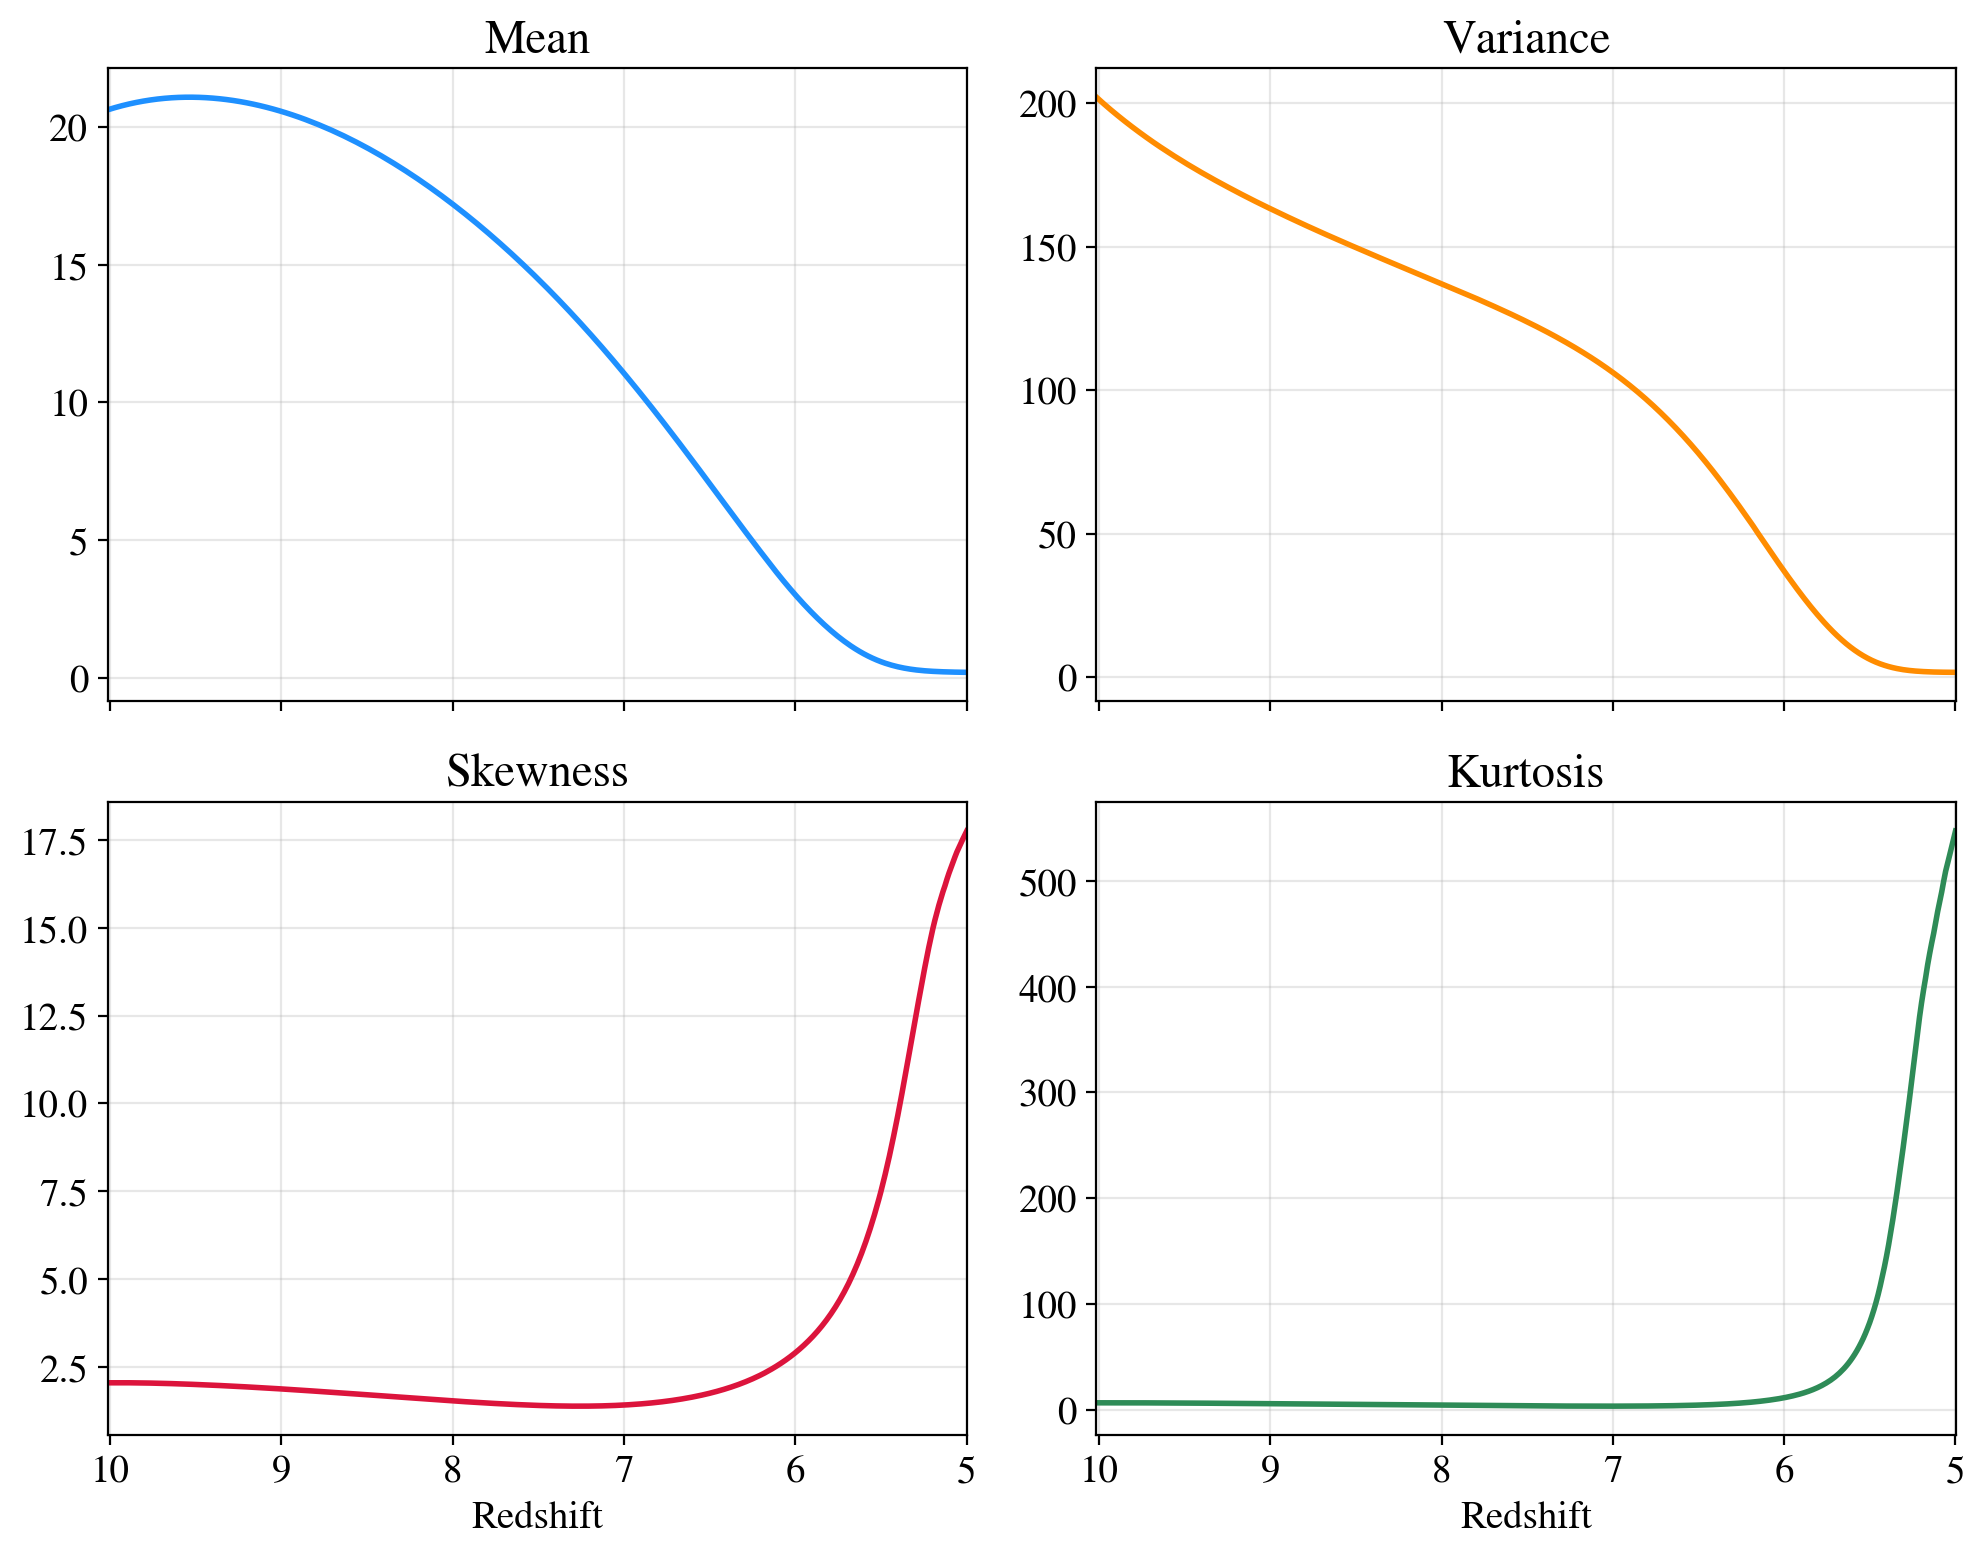

In [6]:
import gc
# =====================================
# Plot
# =====================================

df = pd.read_csv("vid_stats_summary_156_406.csv")
z = df["z"]

colors = {
    "mean": "dodgerblue",
    "variance": "darkorange",
    "skewness": "crimson",
    "kurtosis": "seagreen"
}

fig, axes = plt.subplots(2, 2, figsize=(10,8), sharex=True)
axes = axes.flatten()

labels = ["Mean", "Variance", "Skewness", "Kurtosis"]
cols   = ["mean", "variance", "skewness", "kurtosis"]
markers = ["o", "s", "^", "D"]

for ax, col, label, m in zip(axes, cols, labels, markers):

    ax.plot(
        z,
        df[col],
        #marker=m,
        color=colors[col],
        linewidth=2
    )

    ax.set_title(label)
    ax.grid(alpha=0.3)

    # Force redshift direction (high → low)
    ax.set_xlim(max(z), min(z))

# Labels
axes[2].set_xlabel("Redshift")
axes[3].set_xlabel("Redshift")

# Optional: mark key epochs
#for ax in axes:
#    ax.axvline(7, linestyle="--", color="gray", alpha=0.5)
#    ax.axvline(6, linestyle="--", color="gray", alpha=0.5)

#plt.suptitle("VID Statistics Evolution", fontsize=16)
plt.tight_layout()
plt.show()

### Getting them all

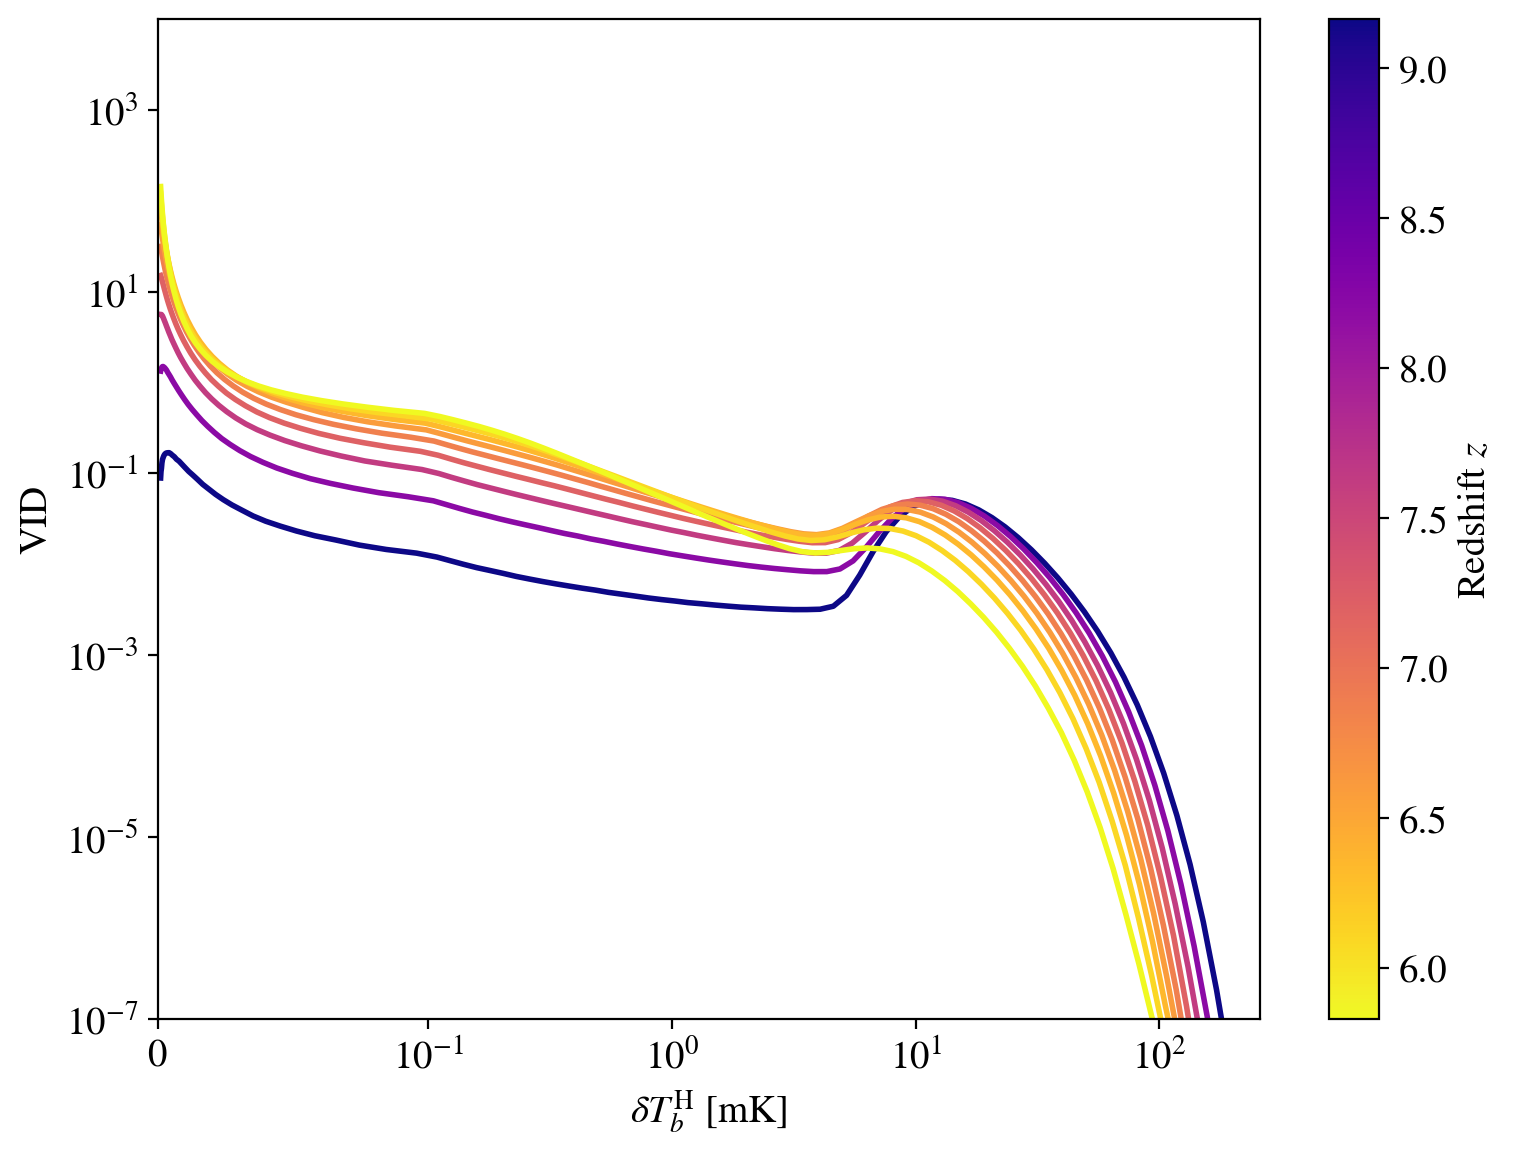

In [27]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

PS_files = [
    "./TS_TK/H/Tb/PS_Tb_H_177.out",
    "./TS_TK/H/Tb/PS_Tb_H_203.out",
    "./TS_TK/H/Tb/PS_Tb_H_220.out",
    "./TS_TK/H/Tb/PS_Tb_H_242.out",
    "./TS_TK/H/Tb/PS_Tb_H_264.out",
    "./TS_TK/H/Tb/PS_Tb_H_283.out",
    "./TS_TK/H/Tb/PS_Tb_H_300.out",
    "./TS_TK/H/Tb/PS_Tb_H_318.out",
    "./TS_TK/H/Tb/PS_Tb_H_338.out",
]

voxel_res = 500 / 640


def plot_vid_from_csv(PS_files):

    fig, ax = plt.subplots(figsize=(8,6))   # ✅ FIX

    zs = []
    snaps = []

    for PS_file in PS_files:
        snap = int(PS_file.split("_")[-1].split(".")[0])
        z = get_redshift(PS_file)

        snaps.append(snap)
        zs.append(z)

    zs = np.array(zs)

    cmap = plt.get_cmap("plasma_r")
    norm = mpl.colors.Normalize(vmin=zs.min(), vmax=zs.max())

    for snap, z in zip(snaps, zs):

        filename = f"./bubble_stats/new_VID_{snap:03d}.csv"
        Tb, vid = load_vid_csv(filename)

        vid = np.where(vid > 0, vid, 1e-20)

        ax.plot(
            Tb,
            vid,
            color=cmap(norm(z)),
            lw=2
        )

    # Axes settings
    #ax.set_xscale("symlog", linthresh=0.001)
    ax.set_xscale("symlog", linthresh=0.1)
    ax.set_yscale("log")

    ax.set_xlabel(r"$\delta T^{\mathrm{H}}_b$ [mK]")
    ax.set_ylabel("VID")

    ax.set_xlim(0.0, 260)
    
    ax.set_ylim(1e-7, 1e4)

    #ax.grid(True, which="both", ls="--", alpha=0.3)

    # -----------------------------------
    # FIXED colorbar
    # -----------------------------------
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)   # ✅ THIS FIXES IT
    cbar.set_label(r"Redshift $z$")

    #ax.set_title("Voxel Intensity Distribution Evolution")

    plt.tight_layout()
    plt.show()

plot_vid_from_csv(PS_files)

## THESAN-1 Hydrogen

In [7]:
def calculate_vid_logbins(hdf5_file, resolution_cMpc, bins=50):

    with h5py.File(hdf5_file, "r") as f:
        tb_cube = f["Tb"][:]

    voxels = tb_cube.flatten()

    stats = {
        'mean': np.mean(voxels),
        'variance': np.var(voxels),
        'skewness': skew(voxels),
        'kurtosis': kurtosis(voxels)
    }

    voxel_volume = resolution_cMpc**3
    total_volume = len(voxels) * voxel_volume

    # ===================================
    # POSITIVE
    # ===================================
    vox_pos = voxels[voxels > 0]

    if len(vox_pos) > 0:
        # 1. Set a realistic observational floor
        PHYSICAL_FLOOR = 0.001 # mK (Anything below this is noise to SKA)
        
        # 2. Force vmin to never drop below the floor
        vmin = max(vox_pos.min(), PHYSICAL_FLOOR)
        vmax = vox_pos.max()
        if vmin == vmax:
            vmax = vmin * 1.01

        bins_pos = np.logspace(np.log10(vmin), np.log10(vmax), bins)

        counts_pos, edges_pos = np.histogram(vox_pos, bins=bins_pos)

        centers_pos = 0.5 * (edges_pos[:-1] + edges_pos[1:])
        widths_pos = np.diff(edges_pos)
        widths_pos = np.where(widths_pos > 0, widths_pos, 1e-20)

        vid_prob_pos = counts_pos / (len(voxels) * widths_pos)
        vid_phys_pos = counts_pos / (widths_pos * total_volume)

    else:
        centers_pos = np.array([])
        vid_prob_pos = np.array([])
        vid_phys_pos = np.array([])

    # ===================================
    # NEGATIVE
    # ===================================
    vox_neg = -voxels[voxels < 0]

    if len(vox_neg) > 0:
        vmin, vmax = vox_neg.min(), vox_neg.max()
        if vmin == vmax:
            vmax = vmin * 1.01

        bins_neg = np.logspace(np.log10(vmin), np.log10(vmax), bins)

        counts_neg, edges_neg = np.histogram(vox_neg, bins=bins_neg)

        centers_neg = -0.5 * (edges_neg[:-1] + edges_neg[1:])
        widths_neg = np.diff(edges_neg)
        widths_neg = np.where(widths_neg > 0, widths_neg, 1e-20)

        vid_prob_neg = counts_neg / (len(voxels) * widths_neg)
        vid_phys_neg = counts_neg / (widths_neg * total_volume)

    else:
        centers_neg = np.array([])
        vid_prob_neg = np.array([])
        vid_phys_neg = np.array([])

    results_pos = (centers_pos, vid_prob_pos, vid_phys_pos)
    results_neg = (centers_neg, vid_prob_neg, vid_phys_neg)

    return results_pos, results_neg, stats

def plot_vid(results_pos, results_neg, z, stats=None, linthresh=1.0):

    centers_pos, vid_prob_pos, _ = results_pos
    centers_neg, vid_prob_neg, _ = results_neg

    plt.figure(figsize=(8,6))

    # -----------------------------------
    # Plot BOTH sides
    # -----------------------------------
    if len(centers_pos) > 0:
        plt.plot(centers_pos, vid_prob_pos, color='dodgerblue')

    if len(centers_neg) > 0:
        plt.plot(centers_neg, vid_prob_neg, color='dodgerblue')

    # -----------------------------------
    # Symmetric log scale
    # -----------------------------------
    plt.xscale("symlog", linthresh=linthresh)
    plt.yscale("log")

    # -----------------------------------
    # Labels
    # -----------------------------------
    plt.xlabel("Brightness Temperature $T_b$ [mK]")
    plt.ylabel("VID")

    plt.xlim(-50, 260)
    plt.ylim(1e-9, 1e4)

    plt.grid(True, which="both", ls="--", alpha=0.3)

    plt.title(f"Voxel Intensity Distribution (z = {z:.2f})")

    plt.legend()

    # -----------------------------------
    # Stats
    # -----------------------------------
    if stats is not None:
        textstr = (
            f"Mean = {stats['mean']:.3e}\n"
            f"Var = {stats['variance']:.3e}\n"
            f"Skew = {stats['skewness']:.3f}\n"
            f"Kurt = {stats['kurtosis']:.3f}"
        )

        plt.text(0.02, 0.98, textstr,
                 transform=plt.gca().transAxes,
                 verticalalignment='top',
                 fontsize=10,
                 bbox=dict(boxstyle="round", alpha=0.2))

    plt.tight_layout()
    plt.show()
    
def get_redshift(ps_file):
    with open(ps_file) as f:
        return float(f.readline().strip())


def save_vid_to_csv(results_pos, results_neg, stats, filename):
    
    centers_pos, vid_prob_pos, vid_phys_pos = results_pos
    centers_neg, vid_prob_neg, vid_phys_neg = results_neg

    # Positive side
    df_pos = pd.DataFrame({
        "Tb": centers_pos,
        "vid_prob": vid_prob_pos,
        "vid_phys": vid_phys_pos,
        "side": "pos"
    })

    # Negative side
    df_neg = pd.DataFrame({
        "Tb": centers_neg,
        "vid_prob": vid_prob_neg,
        "vid_phys": vid_phys_neg,
        "side": "neg"
    })

    # Combine
    df = pd.concat([df_neg, df_pos], ignore_index=True)

    # Save
    df.to_csv(filename, index=False)

    # Save stats separately
    stats_file = filename.replace(".csv", "_stats.csv")
    pd.DataFrame([stats]).to_csv(stats_file, index=False)

THESAN-1_VID_105.csv is saved!


/tmp/ipykernel_2962089/1819890450.py:115: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


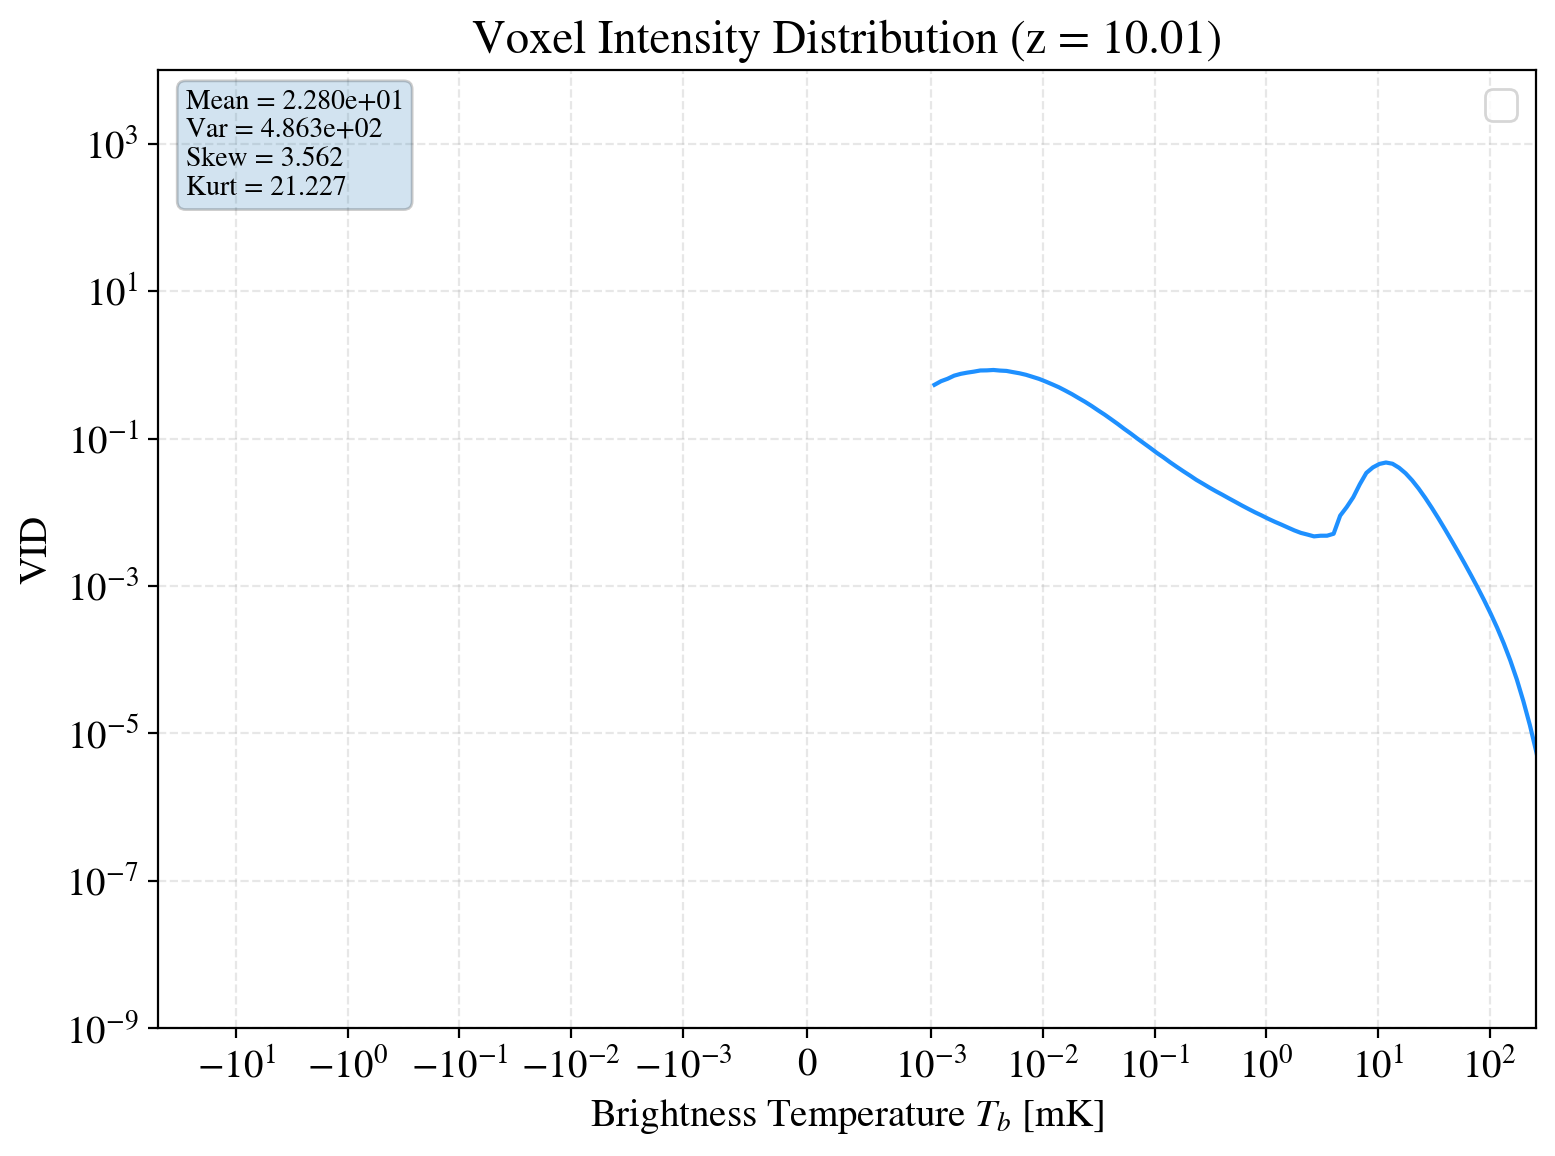

THESAN-1_VID_139.csv is saved!


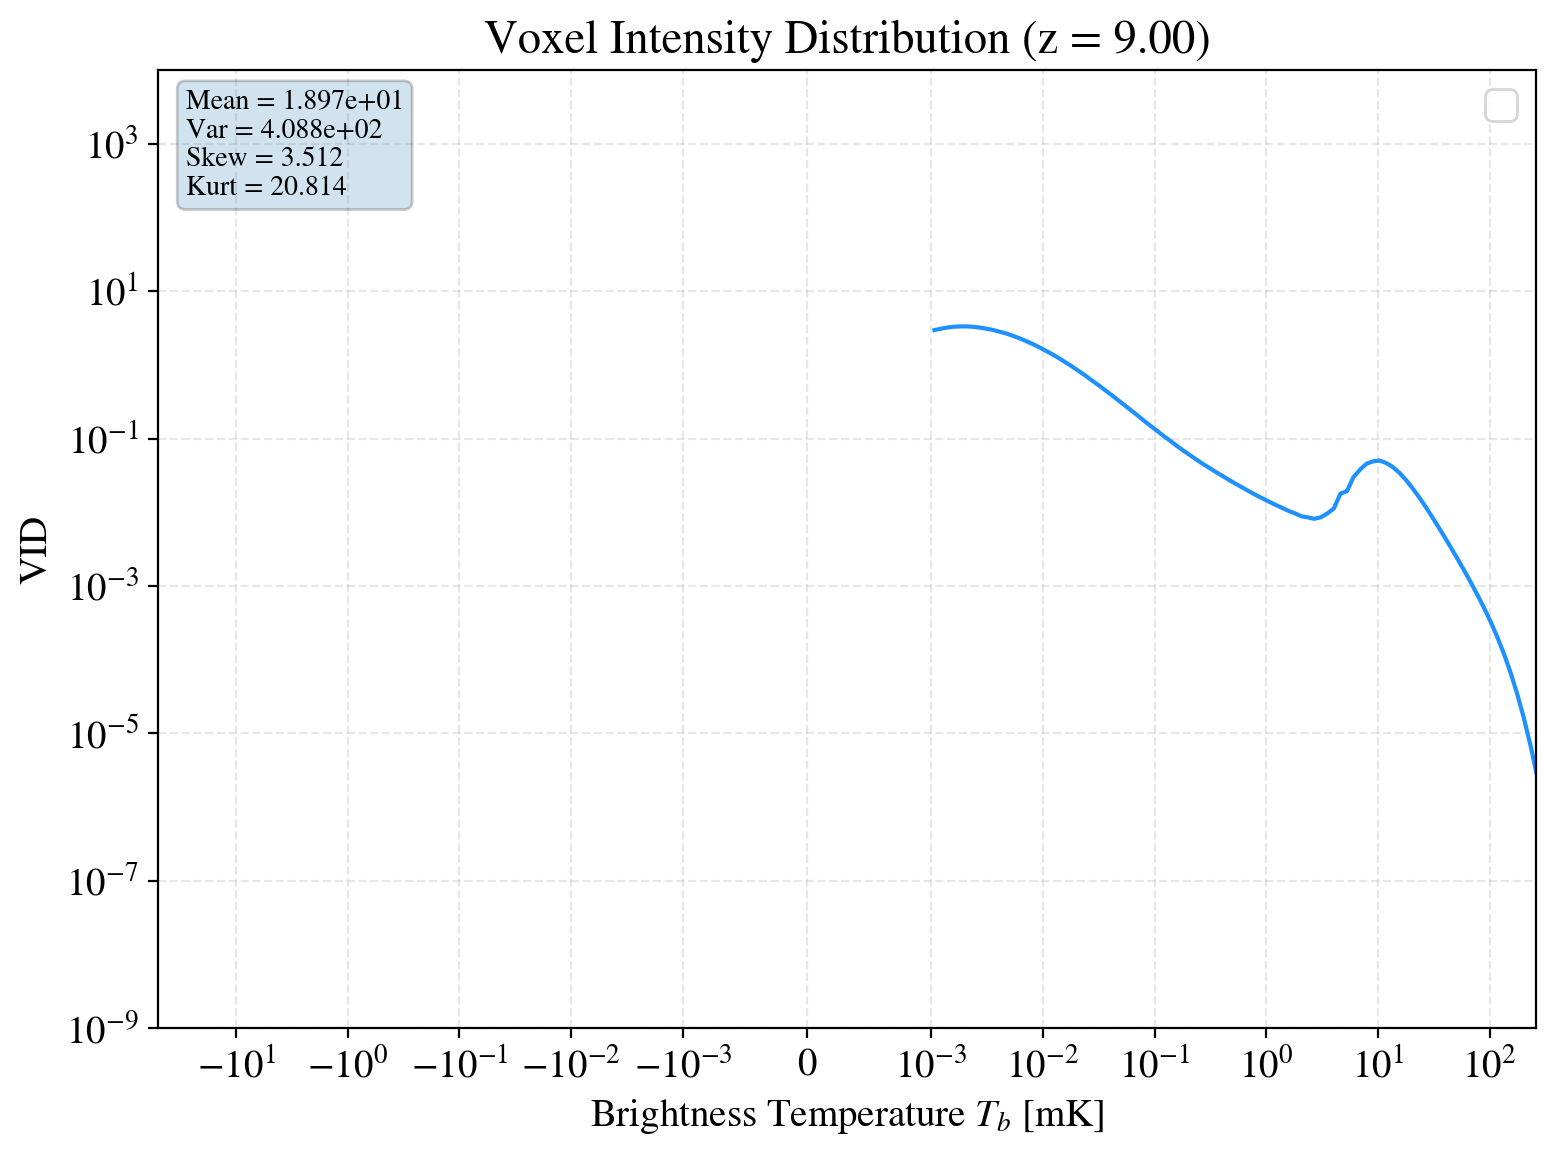

THESAN-1_VID_182.csv is saved!


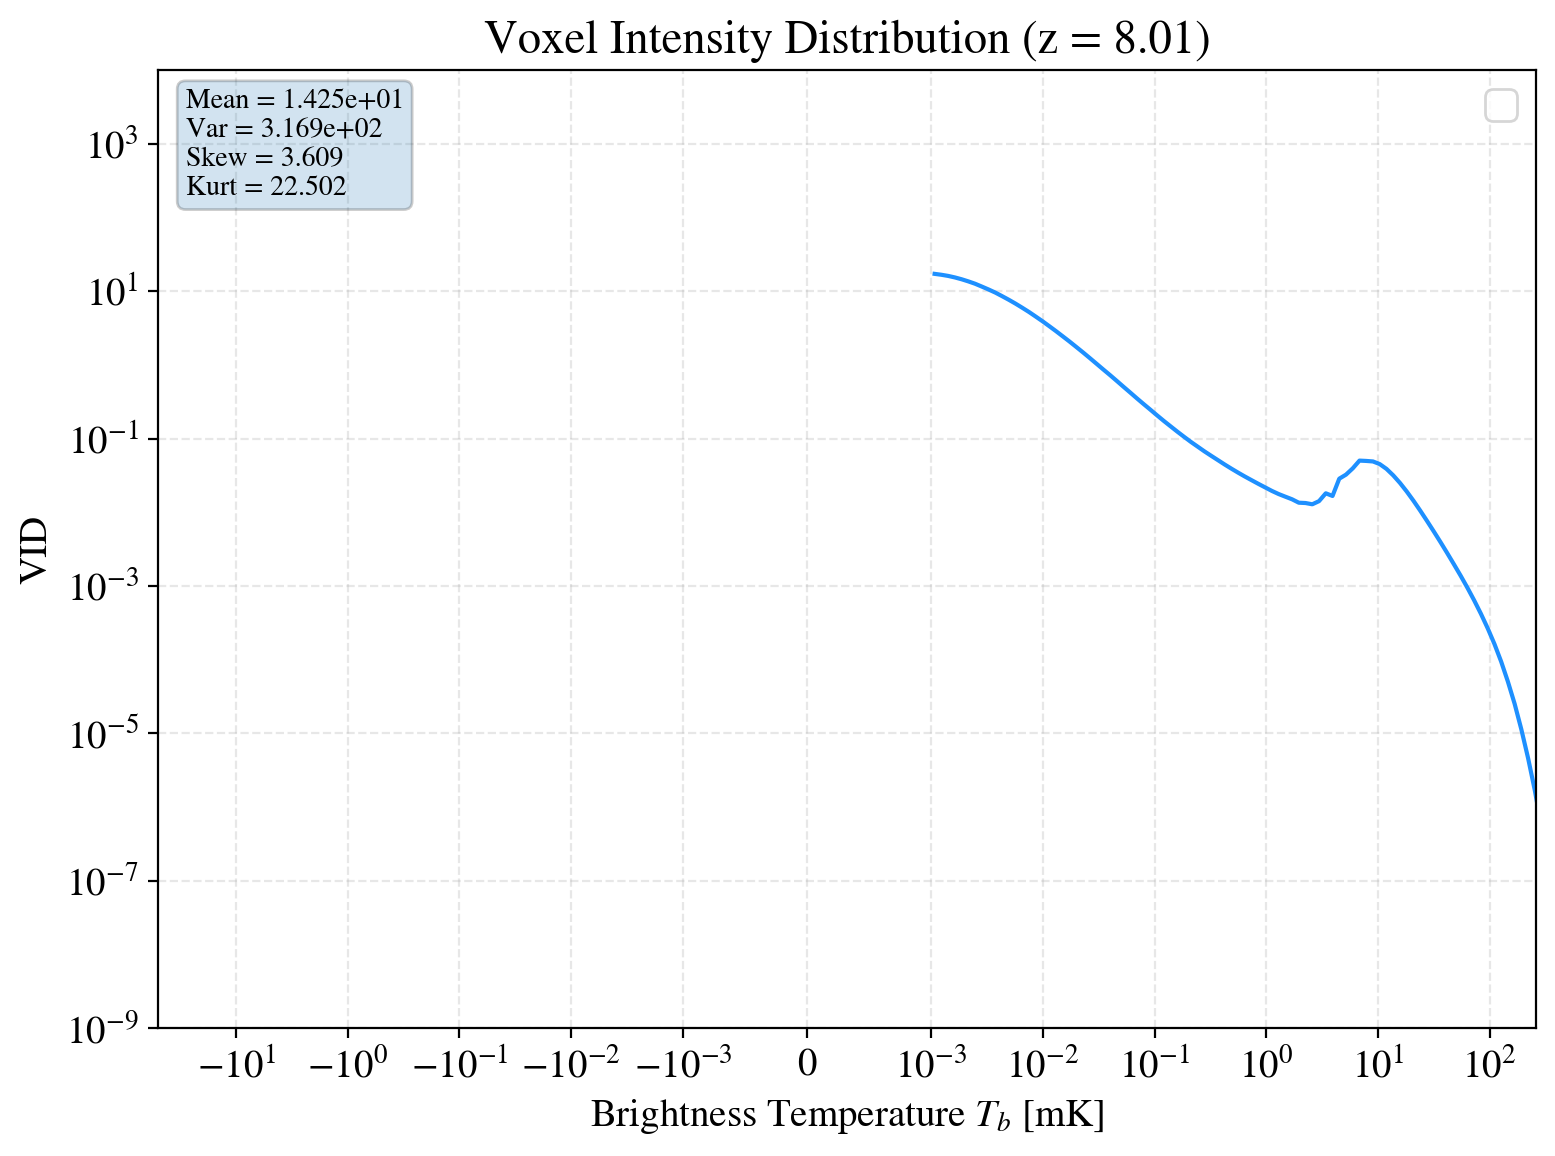

THESAN-1_VID_240.csv is saved!


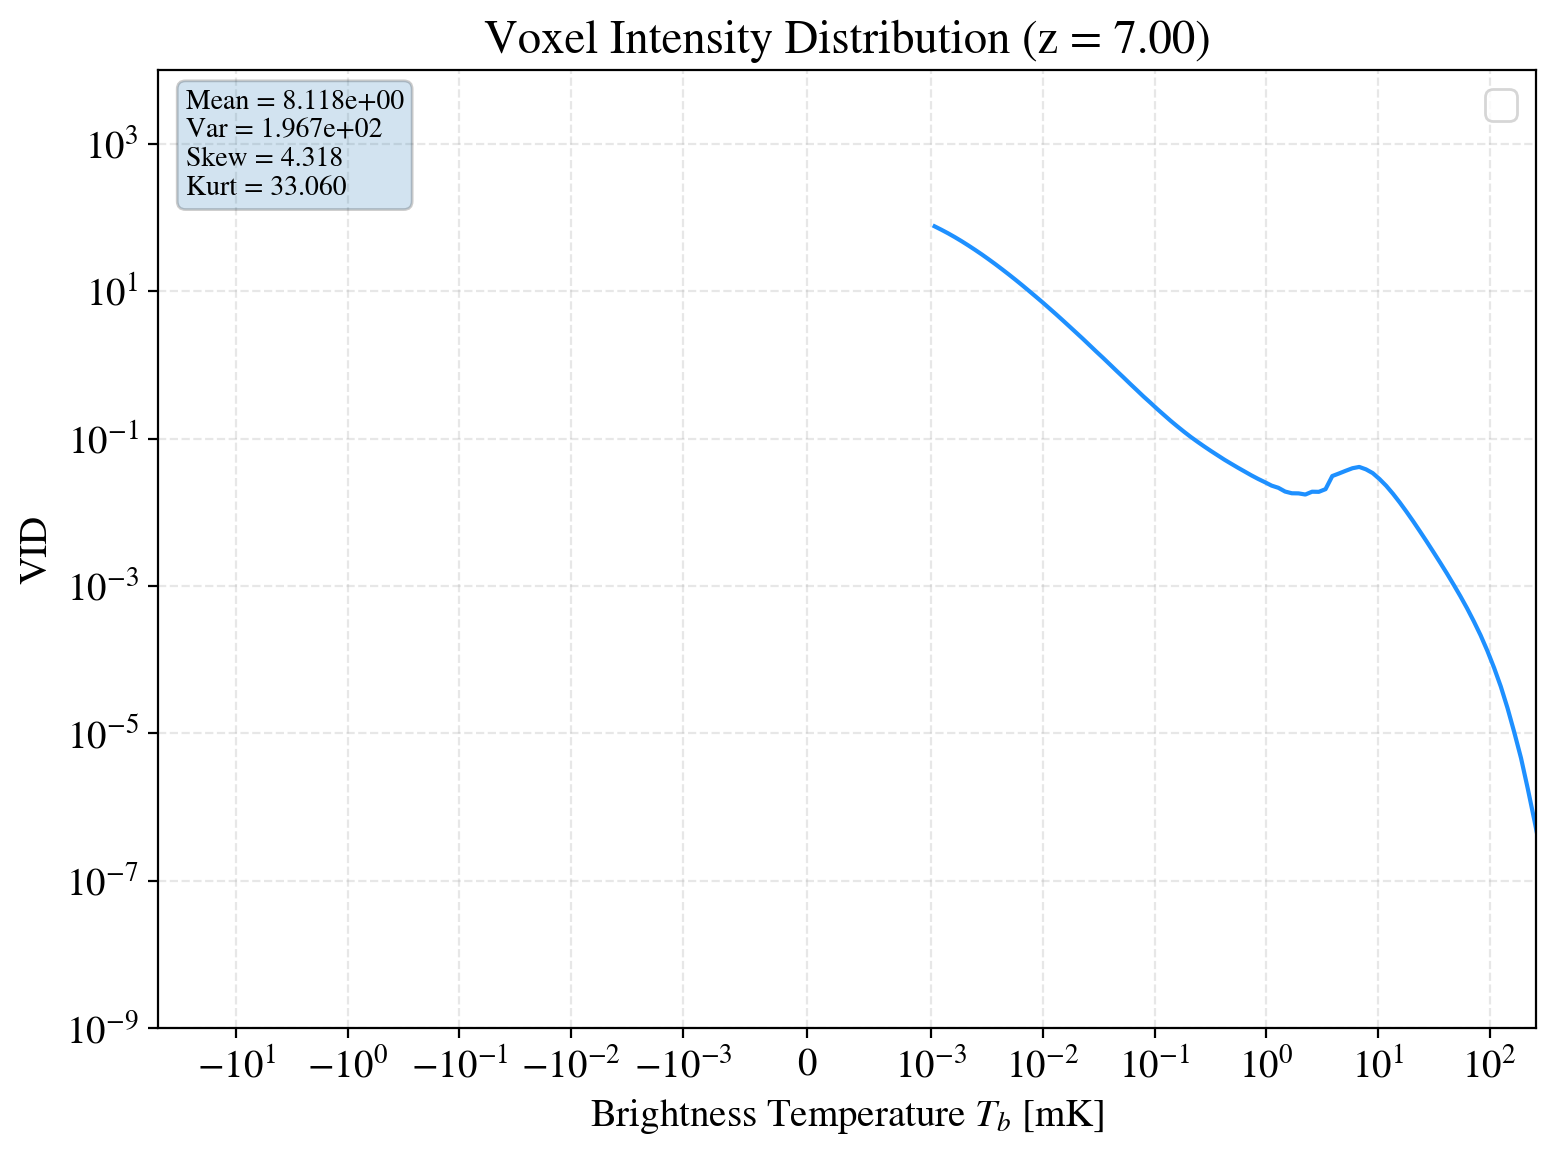

THESAN-1_VID_318.csv is saved!


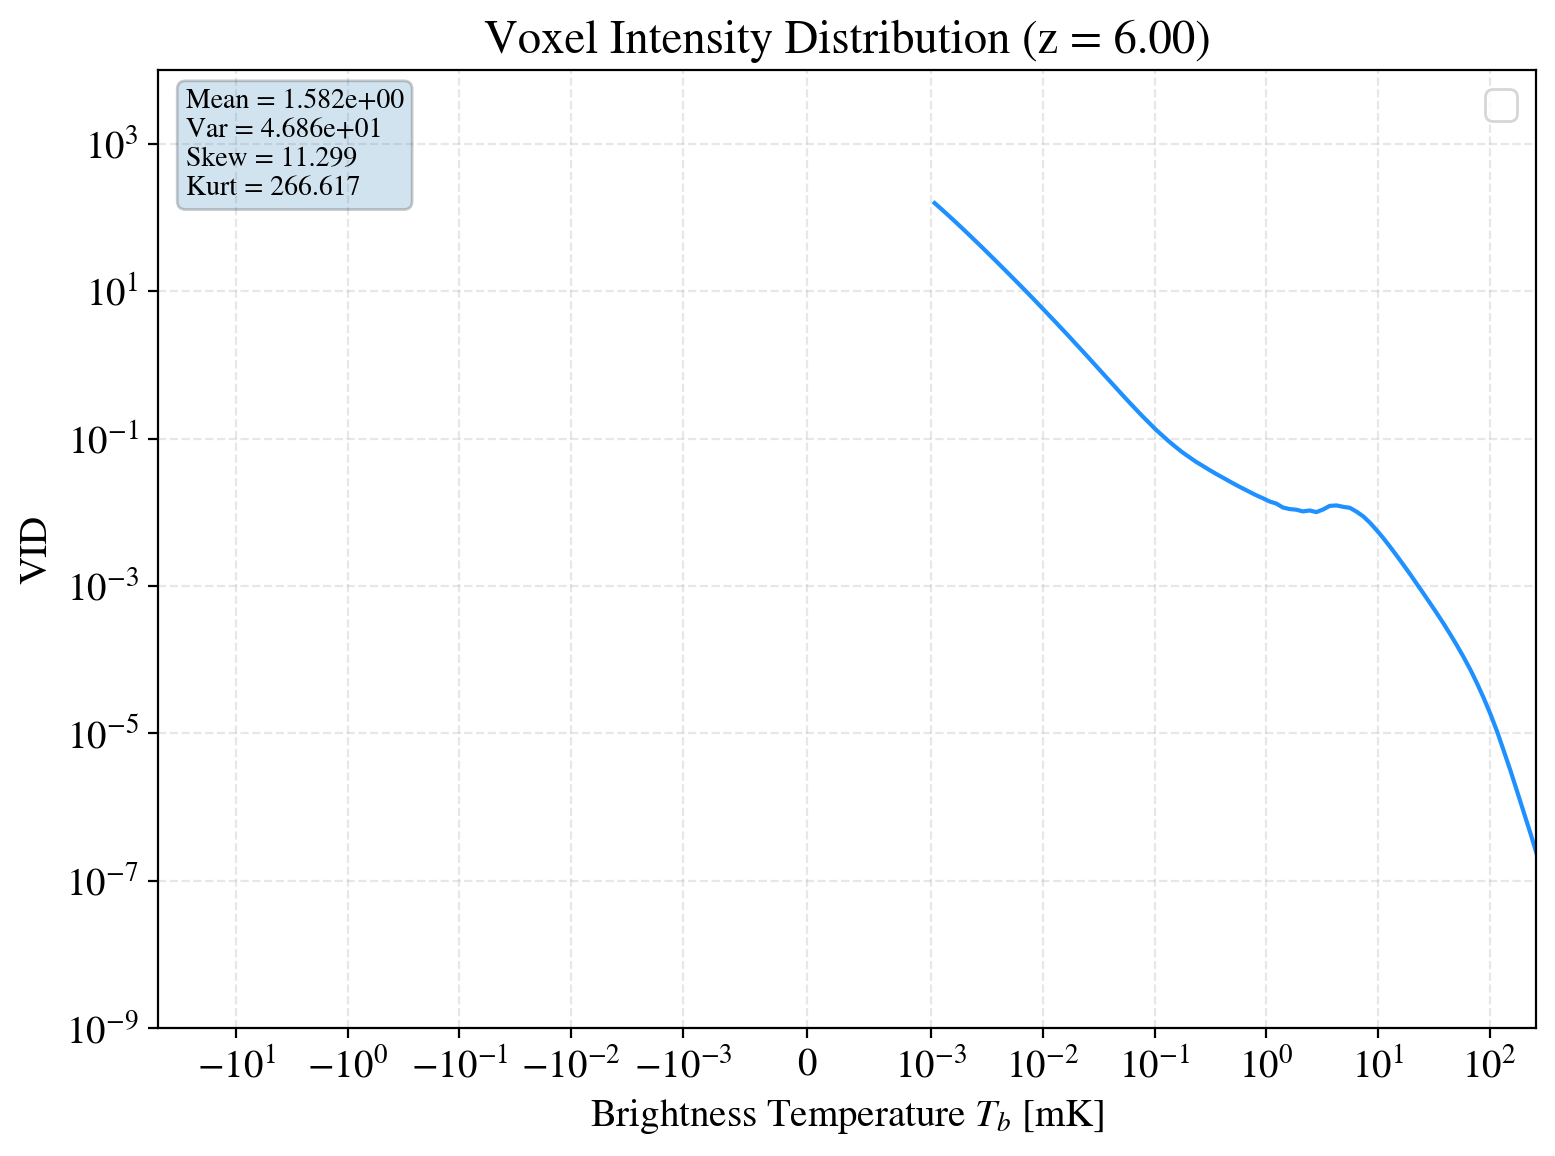

THESAN-1_VID_369.csv is saved!


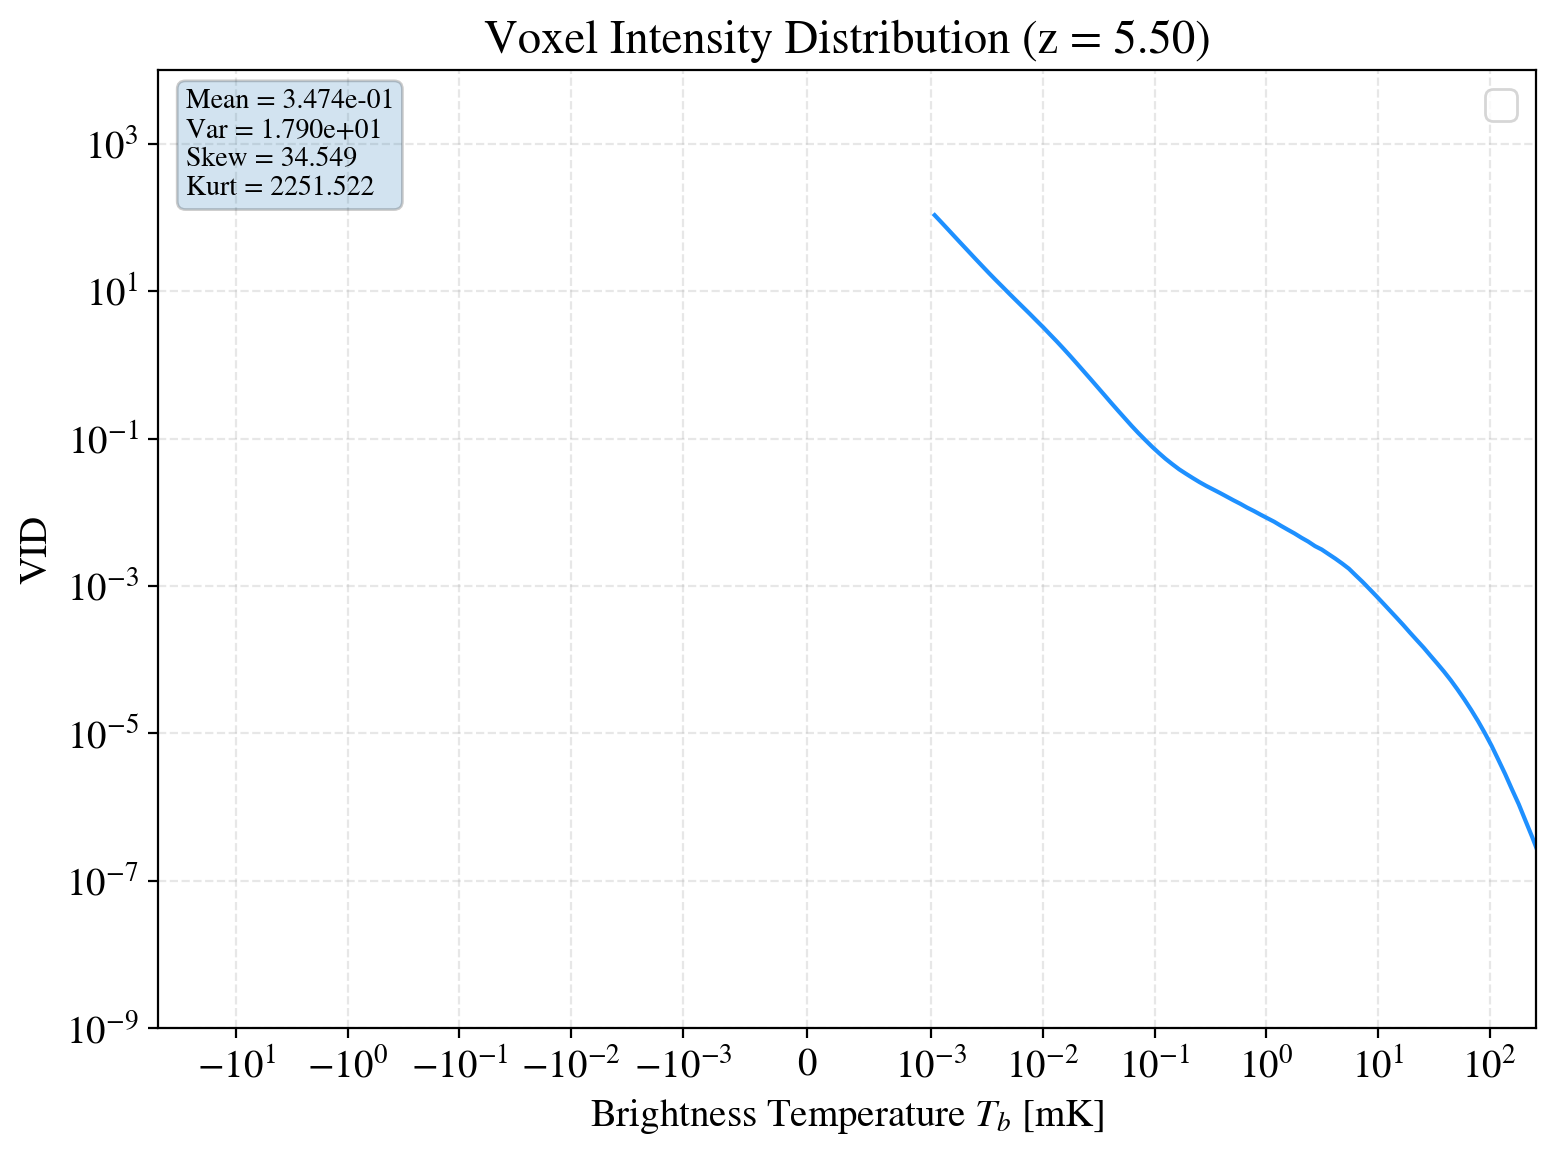

In [8]:
path = "./past/original/Thesan-1/PS_H_Tb_"

snaps = [105, 139, 182, 240, 318, 369]

PS_files = [f"{path}{snap:03d}.out" for snap in snaps]

voxel_res = 95.5 / 512

for PS_file in PS_files:

    # -----------------------------------
    # Snapshot number
    # -----------------------------------
    snap = int(PS_file.split("_")[-1].split(".")[0])

    hdf5_file = f"./past/original/Thesan-1/H_Tb_{snap:03d}.hdf5"

    # -----------------------------------
    # Redshift
    # -----------------------------------
    z = get_redshift(PS_file)

    # -----------------------------------
    # NEW VID function
    # -----------------------------------
    results_pos, results_neg, stats = calculate_vid_logbins(
        hdf5_file=hdf5_file,
        resolution_cMpc=voxel_res,
        bins=100
    )


    #
    # Saving the results
    #
    save_vid_to_csv(
        results_pos,
        results_neg,
        stats,
        filename=f"./bubble_stats/THESAN-1_VID_{snap:03d}.csv"
    )
    print(f"THESAN-1_VID_{snap:03d}.csv is saved!")

    # -----------------------------------
    # NEW plotting function
    # -----------------------------------
    plot_vid(
        results_pos,
        results_neg,
        z=z,
        stats=stats,
        linthresh=0.001
    )

<>:38: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:38: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
/tmp/ipykernel_2962089/4235939699.py:38: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  ax.set_xlabel("Brightness Temperature $\delta T_b$ [mK]")


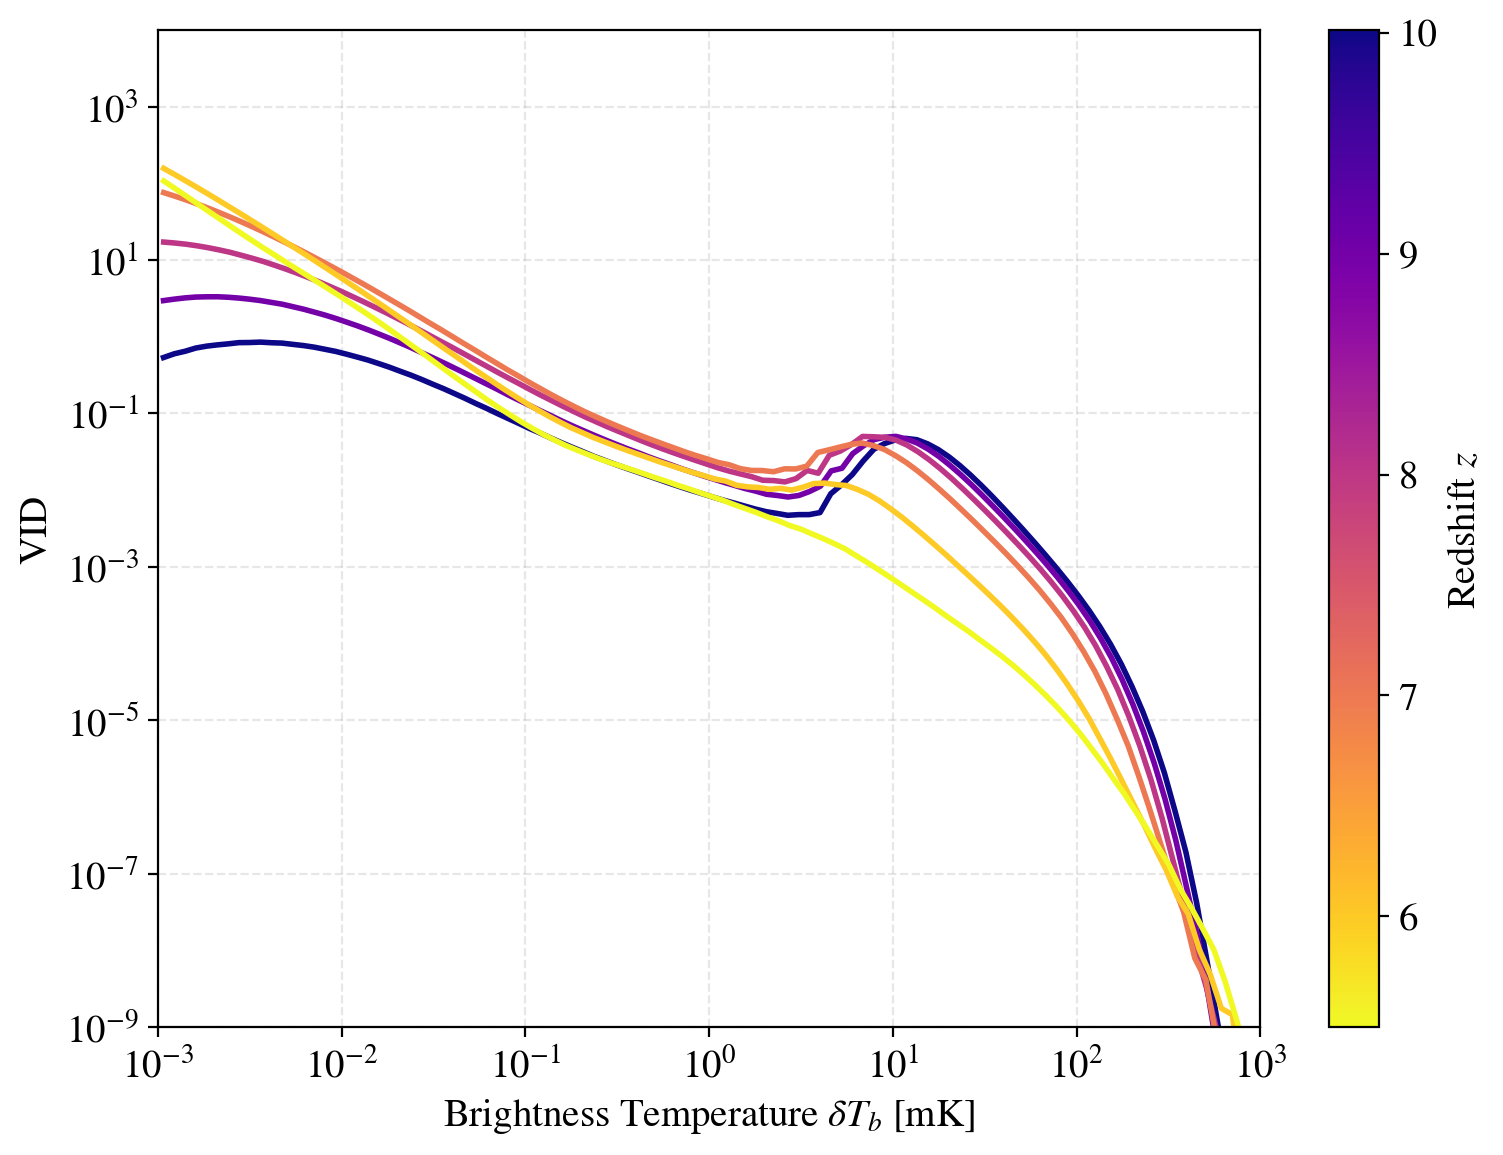

In [15]:
def plot_vid_from_csv(PS_files):

    fig, ax = plt.subplots(figsize=(8,6))   # ✅ FIX

    zs = []
    snaps = []

    for PS_file in PS_files:
        snap = int(PS_file.split("_")[-1].split(".")[0])
        z = get_redshift(PS_file)

        snaps.append(snap)
        zs.append(z)

    zs = np.array(zs)

    cmap = plt.get_cmap("plasma_r")
    norm = mpl.colors.Normalize(vmin=zs.min(), vmax=zs.max())

    for snap, z in zip(snaps, zs):

        filename = f"./bubble_stats/THESAN-1_VID_{snap:03d}.csv"
        Tb, vid = load_vid_csv(filename)

        vid = np.where(vid > 0, vid, 1e-20)

        ax.plot(
            Tb,
            vid,
            color=cmap(norm(z)),
            lw=2
        )

    # Axes settings
    ax.set_xscale("symlog", linthresh=0.001)
    ax.set_yscale("log")

    ax.set_xlabel("Brightness Temperature $\delta T_b$ [mK]")
    ax.set_ylabel("VID")

    ax.set_xlim(1.0e-3, 1000)
    ax.set_ylim(1e-9, 1e4)

    ax.grid(True, which="both", ls="--", alpha=0.3)

    # -----------------------------------
    # FIXED colorbar
    # -----------------------------------
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)   # ✅ THIS FIXES IT
    cbar.set_label(r"Redshift $z$")

    #ax.set_title("Voxel Intensity Distribution Evolution")

    plt.tight_layout()
    plt.show()

plot_vid_from_csv(PS_files)

In [17]:
import gc
# =====================================
# Paths
# =====================================
base = "./past/original/Thesan-1/"

# =====================================
# Snapshot range
# =====================================
snap_range = range(105, 370)  # 369 included

# =====================================
# Find all files and filter by range
# =====================================
hdf5_files_all = sorted(glob.glob(f"{base}/H_Tb_*.hdf5"))

hdf5_files = []
for f in hdf5_files_all:
    snap = int(f.split("_")[-1].split(".")[0])
    if snap in snap_range:
        hdf5_files.append(f)

print(f"Using {len(hdf5_files)} snapshots in range 105-369")

all_stats = []

# =====================================
# Loop
# =====================================
for hdf5_file in hdf5_files:

    snap = int(hdf5_file.split("_")[-1].split(".")[0])
    ps_file = f"{base}/PS_H_Tb_{snap}.out"

    if not os.path.exists(ps_file):
        print(f"[SKIP] Missing PS file for snapshot {snap}")
        continue

    print(f"Processing snapshot {snap}")

    # -----------------------------------
    # Run VID (unchanged)
    # -----------------------------------
    results_pos, results_neg, stats = calculate_vid_logbins(
        hdf5_file=hdf5_file,
        resolution_cMpc=voxel_res,
        bins=100
    )

    # -----------------------------------
    # Get redshift
    # -----------------------------------
    z = get_redshift(ps_file)

    # -----------------------------------
    # Store
    # -----------------------------------
    all_stats.append({
        "snap": snap,
        "z": z,
        "mean": stats["mean"],
        "variance": stats["variance"],
        "skewness": stats["skewness"],
        "kurtosis": stats["kurtosis"]
    })
    del results_pos, results_neg, stats
    gc.collect()


# =====================================
# Save CSV
# =====================================
df = pd.DataFrame(all_stats)
df = df.sort_values("z", ascending=False)

df.to_csv("vid_stats_summary_THESAN-1.csv", index=False)

print("Saved: vid_stats_summary_THESAN-1.csv")

Using 265 snapshots in range 105-369
Processing snapshot 105
Processing snapshot 106
Processing snapshot 107
Processing snapshot 108
Processing snapshot 109
Processing snapshot 110
Processing snapshot 111
Processing snapshot 112
Processing snapshot 113
Processing snapshot 114
Processing snapshot 115
Processing snapshot 116
Processing snapshot 117
Processing snapshot 118
Processing snapshot 119
Processing snapshot 120
Processing snapshot 121
Processing snapshot 122
Processing snapshot 123
Processing snapshot 124
Processing snapshot 125
Processing snapshot 126
Processing snapshot 127
Processing snapshot 128
Processing snapshot 129
Processing snapshot 130
Processing snapshot 131
Processing snapshot 132
Processing snapshot 133
Processing snapshot 134
Processing snapshot 135
Processing snapshot 136
Processing snapshot 137
Processing snapshot 138
Processing snapshot 139
Processing snapshot 140
Processing snapshot 141
Processing snapshot 142
Processing snapshot 143
Processing snapshot 144
Pro

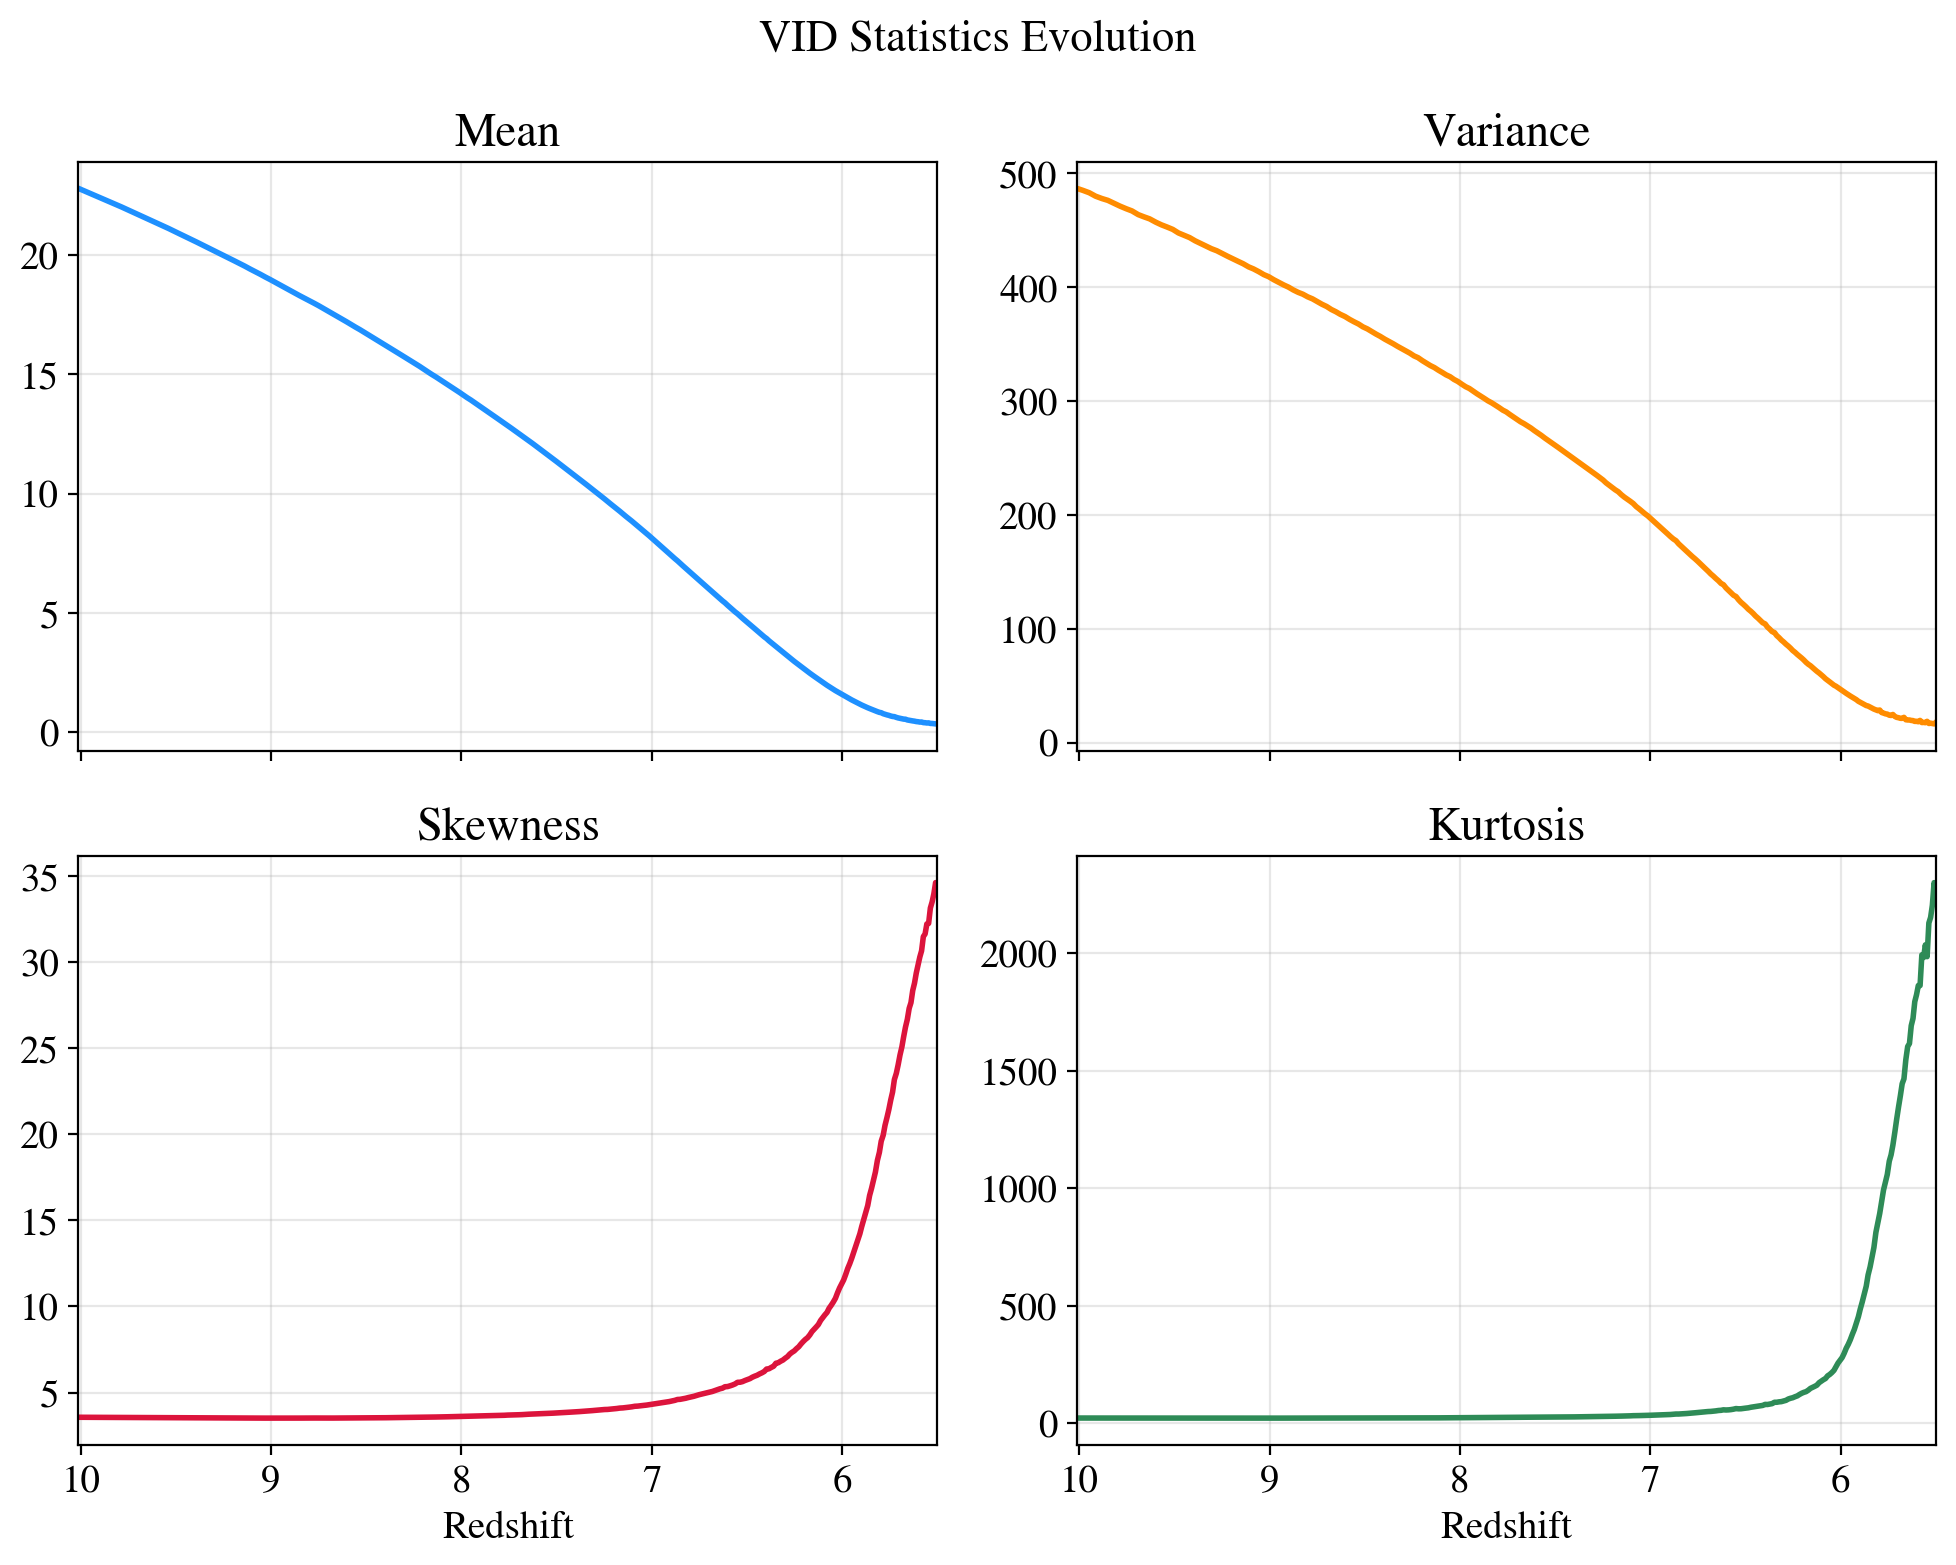

In [18]:

# =====================================
# Plot
# =====================================
z = df["z"]

colors = {
    "mean": "dodgerblue",
    "variance": "darkorange",
    "skewness": "crimson",
    "kurtosis": "seagreen"
}

fig, axes = plt.subplots(2, 2, figsize=(10,8), sharex=True)
axes = axes.flatten()

labels = ["Mean", "Variance", "Skewness", "Kurtosis"]
cols   = ["mean", "variance", "skewness", "kurtosis"]
markers = ["o", "s", "^", "D"]

for ax, col, label, m in zip(axes, cols, labels, markers):

    ax.plot(
        z,
        df[col],
        #marker=m,
        color=colors[col],
        linewidth=2
    )

    ax.set_title(label)
    ax.grid(alpha=0.3)

    # Force redshift direction (high → low)
    ax.set_xlim(max(z), min(z))

# Labels
axes[2].set_xlabel("Redshift")
axes[3].set_xlabel("Redshift")

# Optional: mark key epochs
#for ax in axes:
#    ax.axvline(7, linestyle="--", color="gray", alpha=0.5)
#    ax.axvline(6, linestyle="--", color="gray", alpha=0.5)

plt.suptitle("VID Statistics Evolution", fontsize=16)
plt.tight_layout()
plt.show()

## THESAN-2 Hydrogen

THESAN-2_VID_105.csv is saved!


/tmp/ipykernel_2962089/1819890450.py:115: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


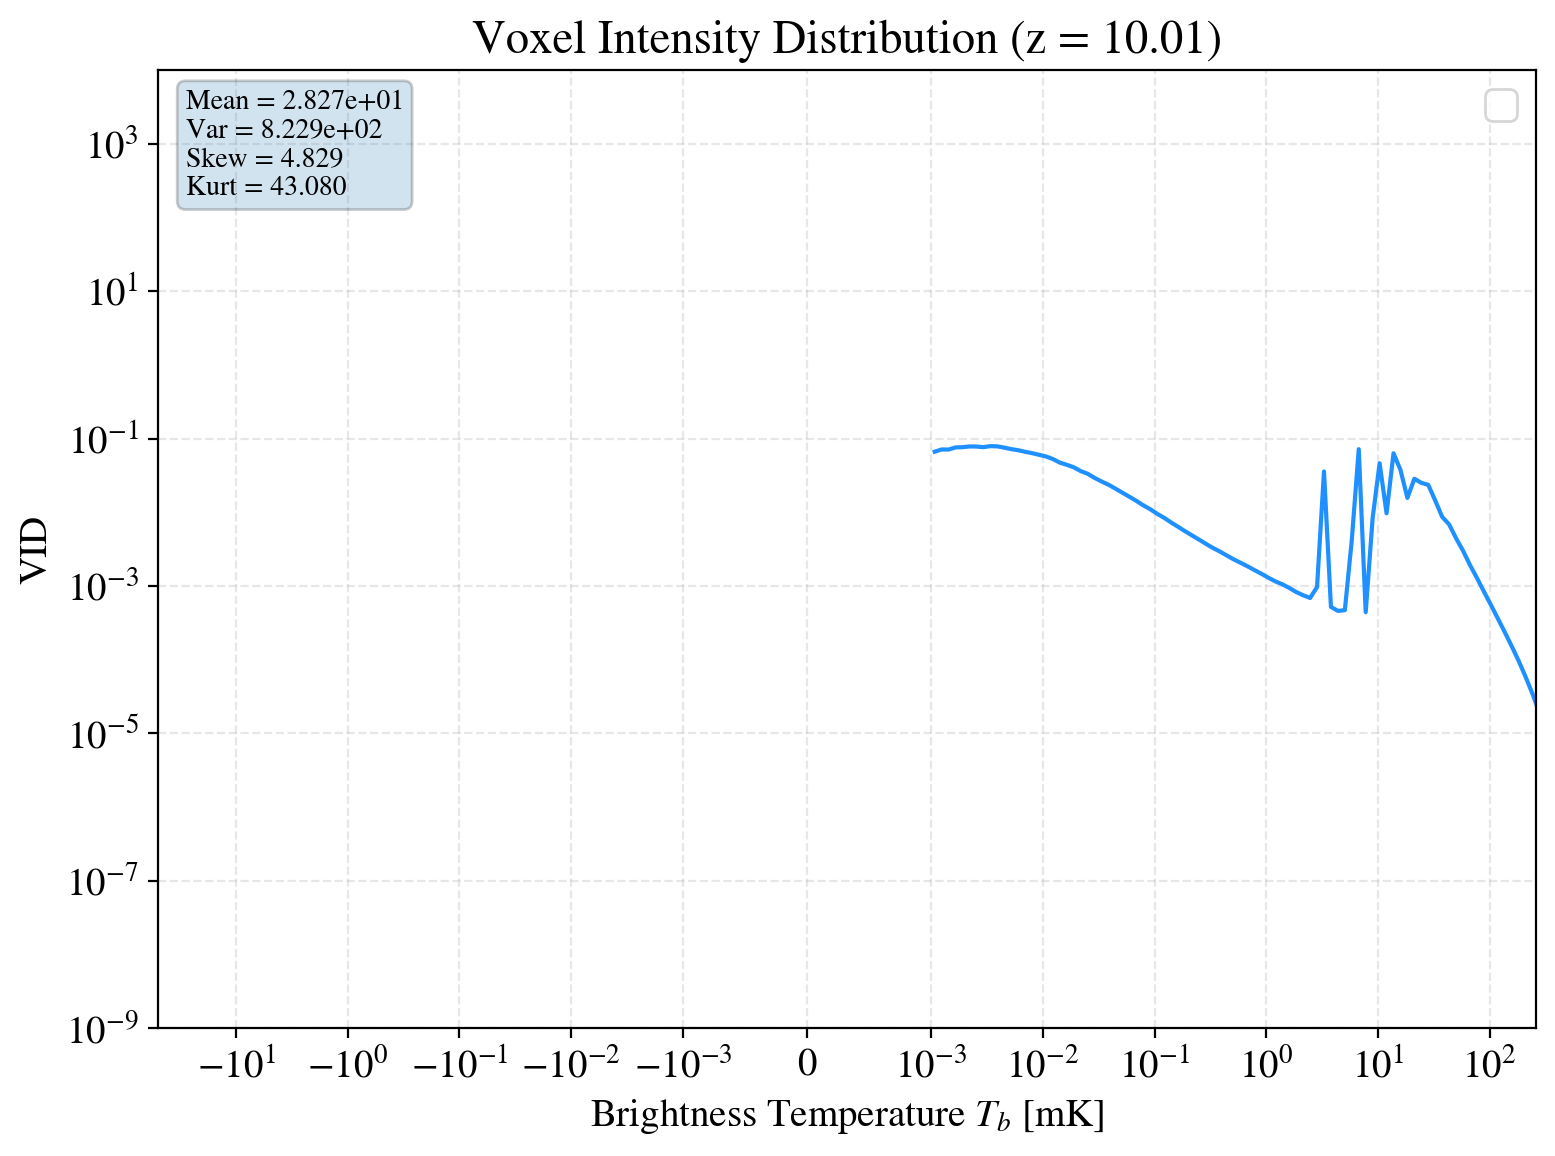

THESAN-2_VID_139.csv is saved!


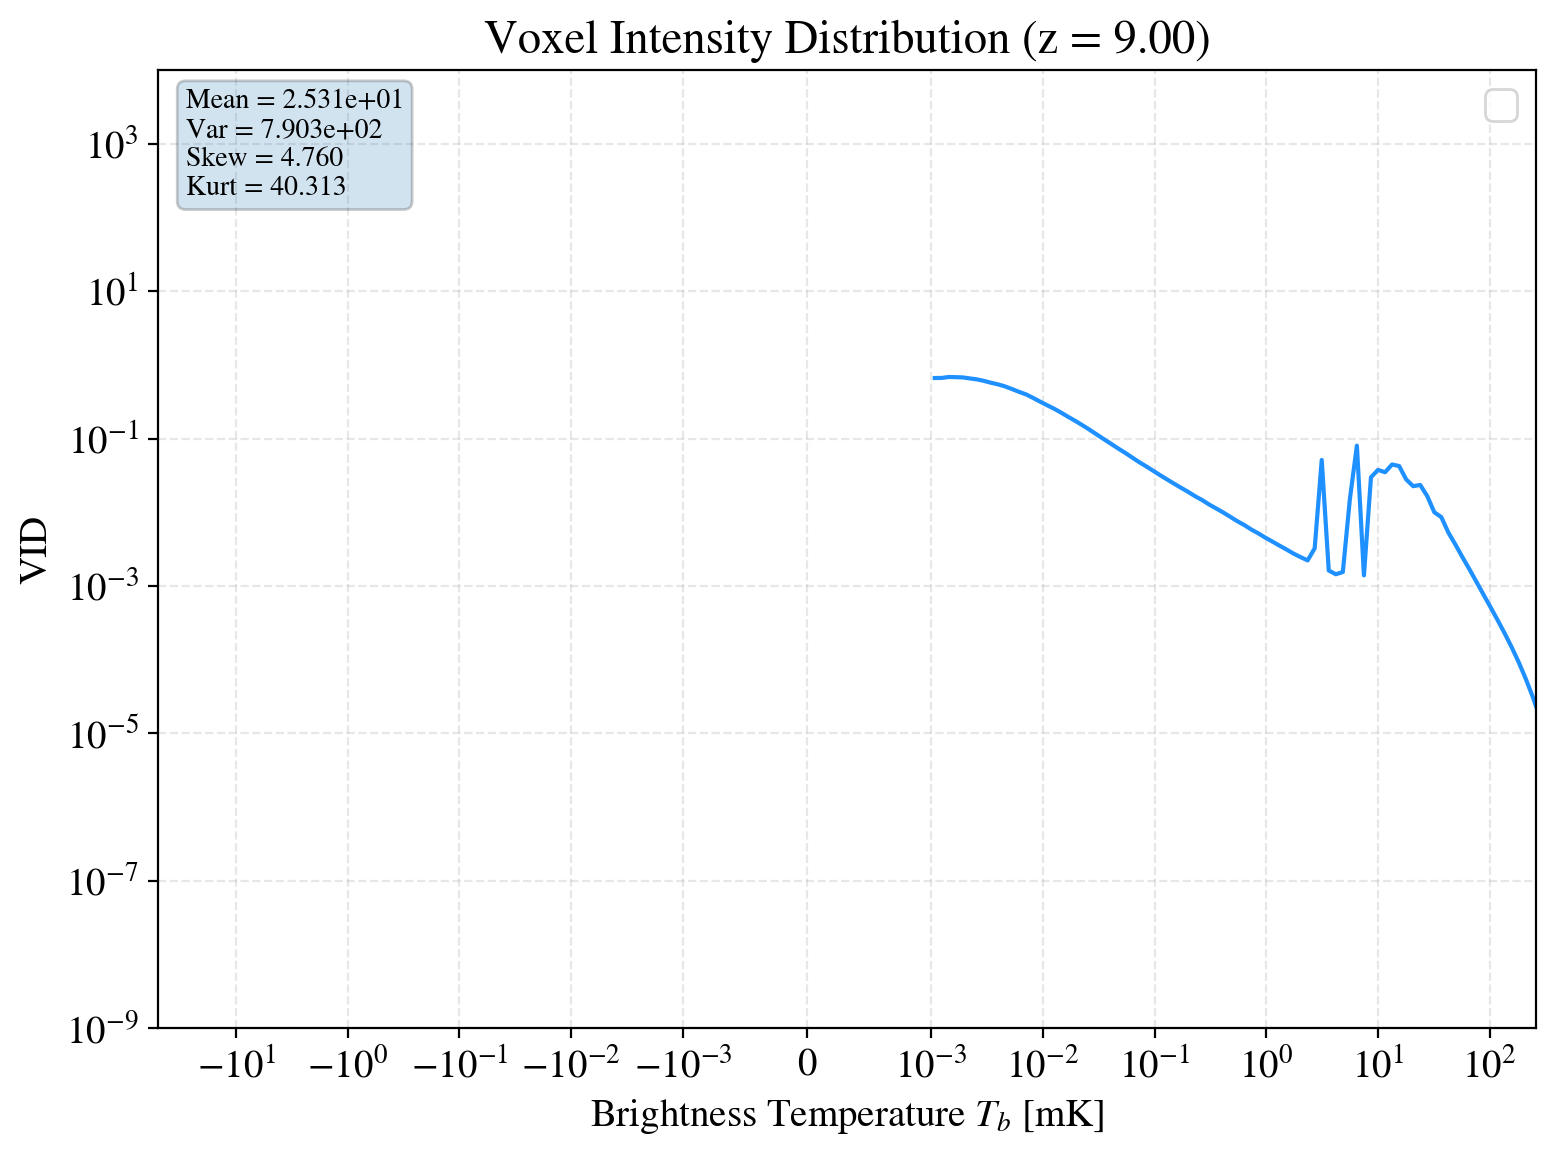

THESAN-2_VID_182.csv is saved!


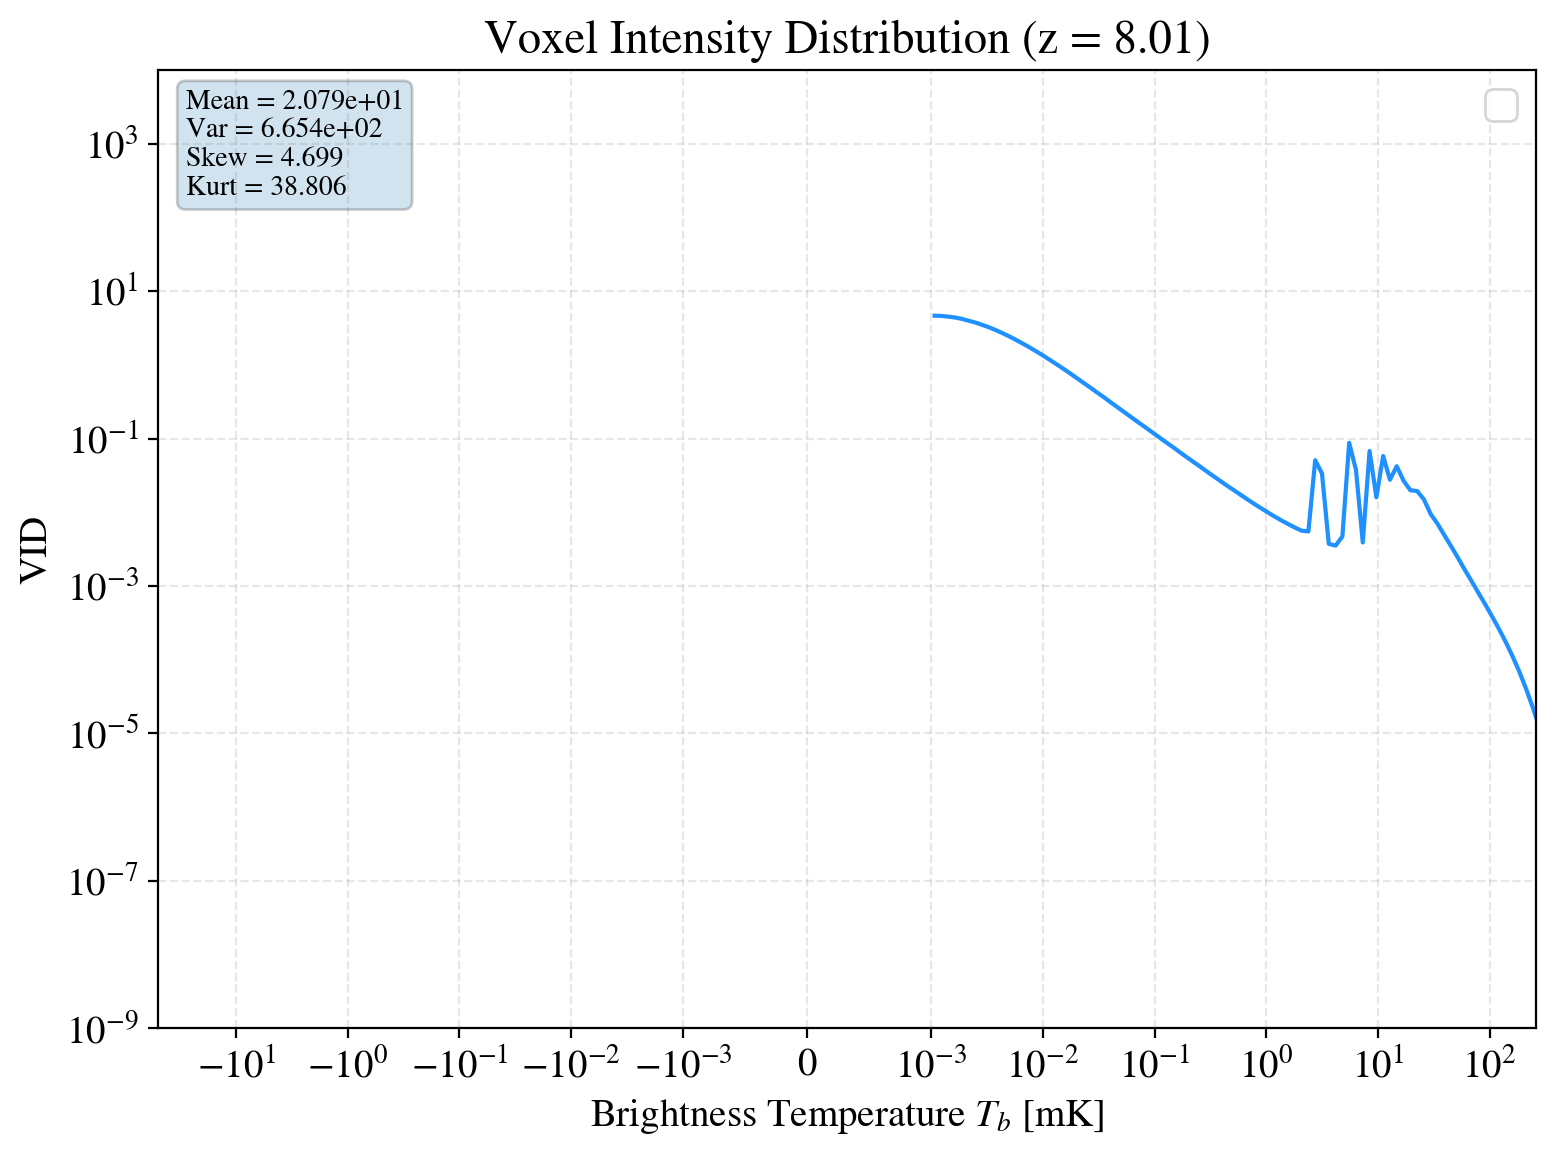

THESAN-2_VID_240.csv is saved!


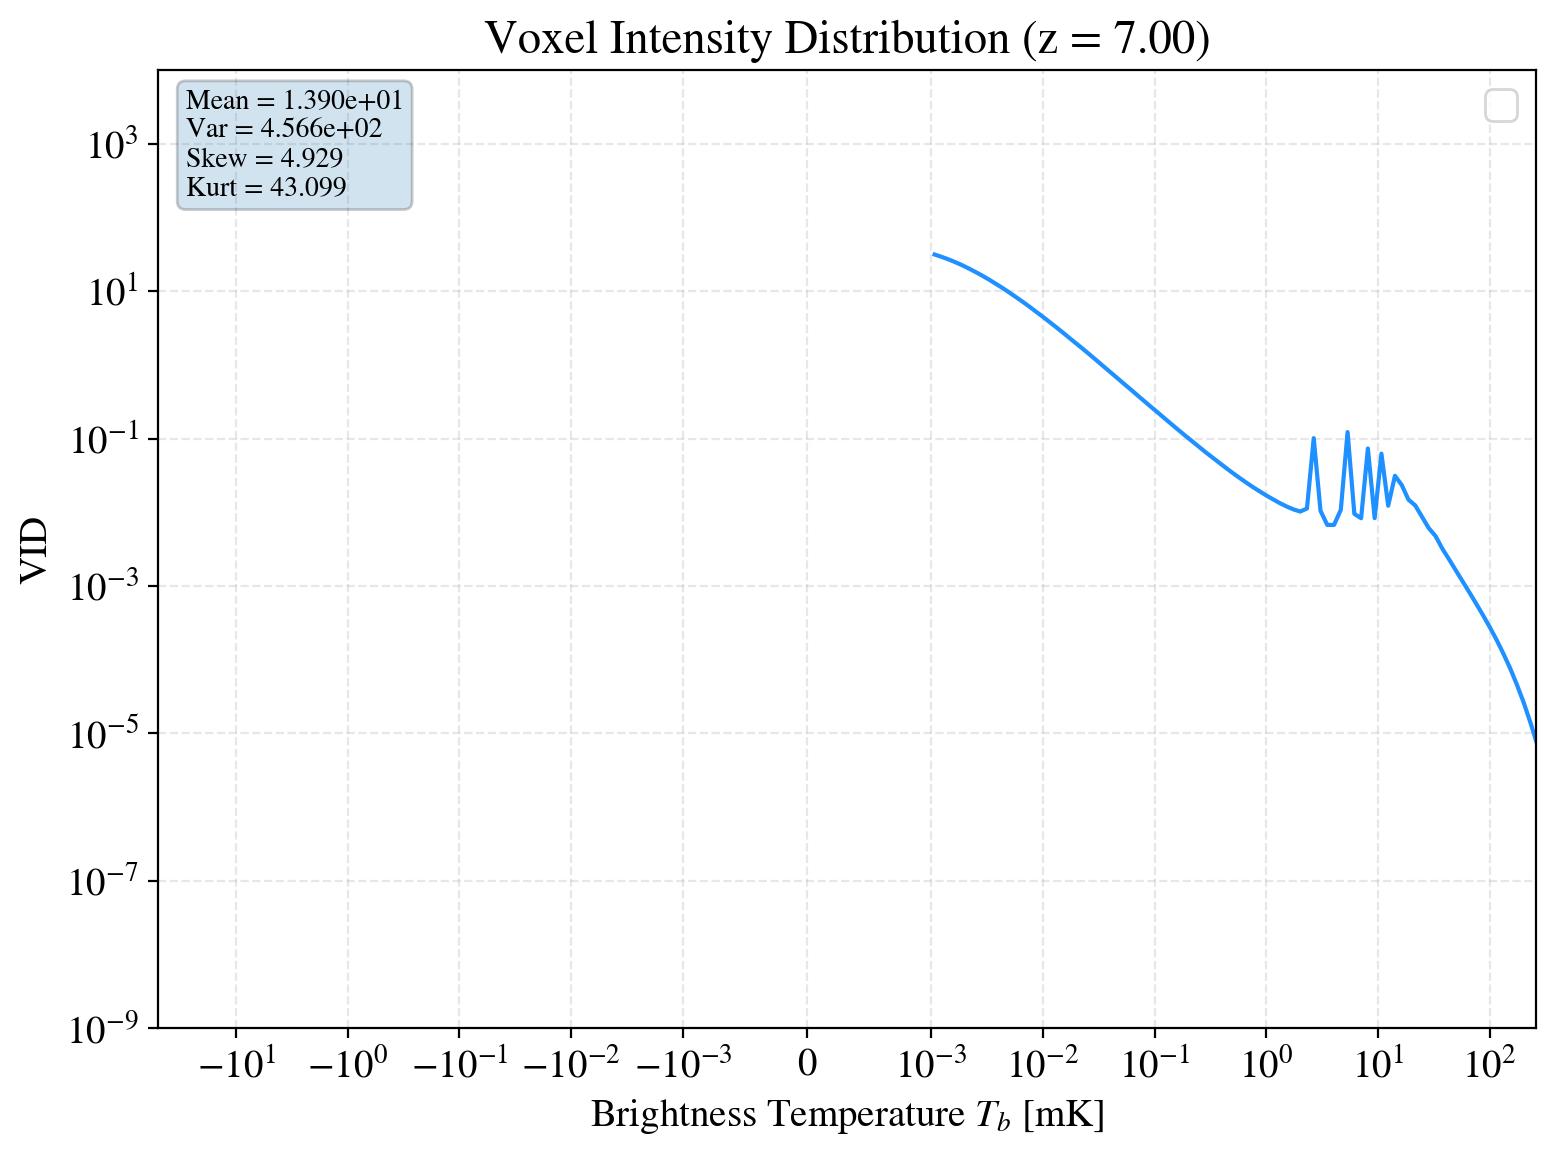

THESAN-2_VID_318.csv is saved!


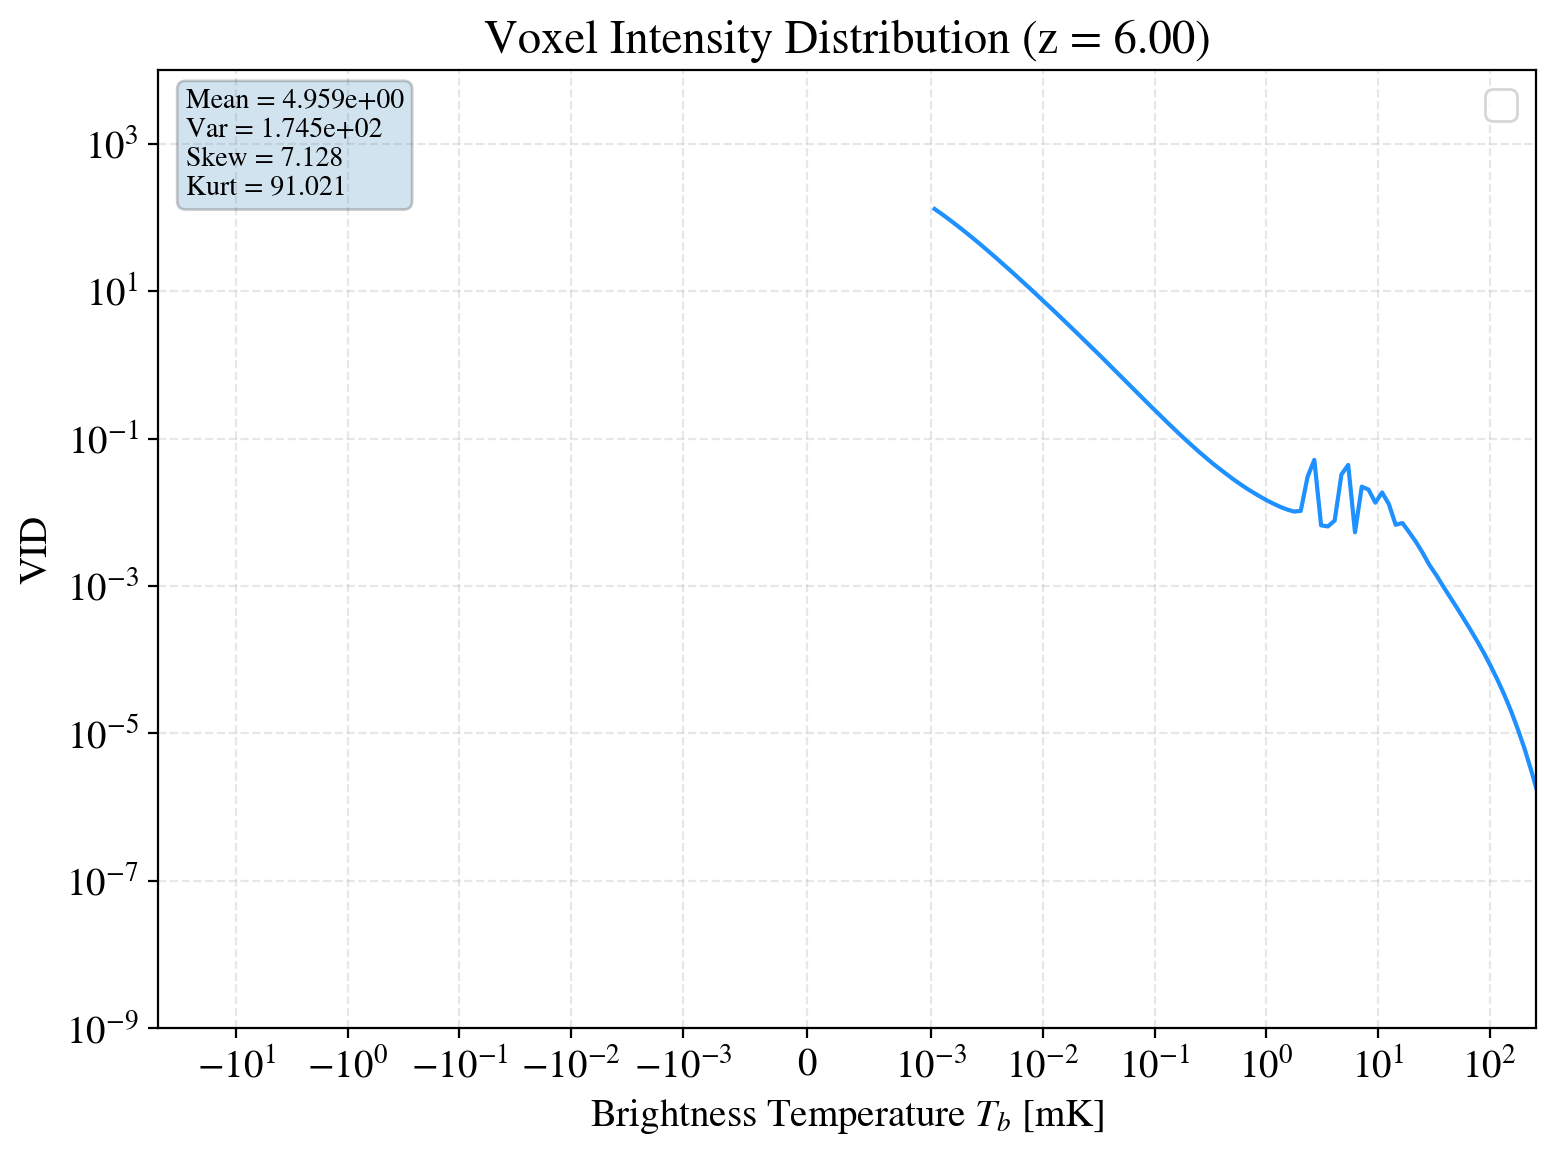

THESAN-2_VID_369.csv is saved!


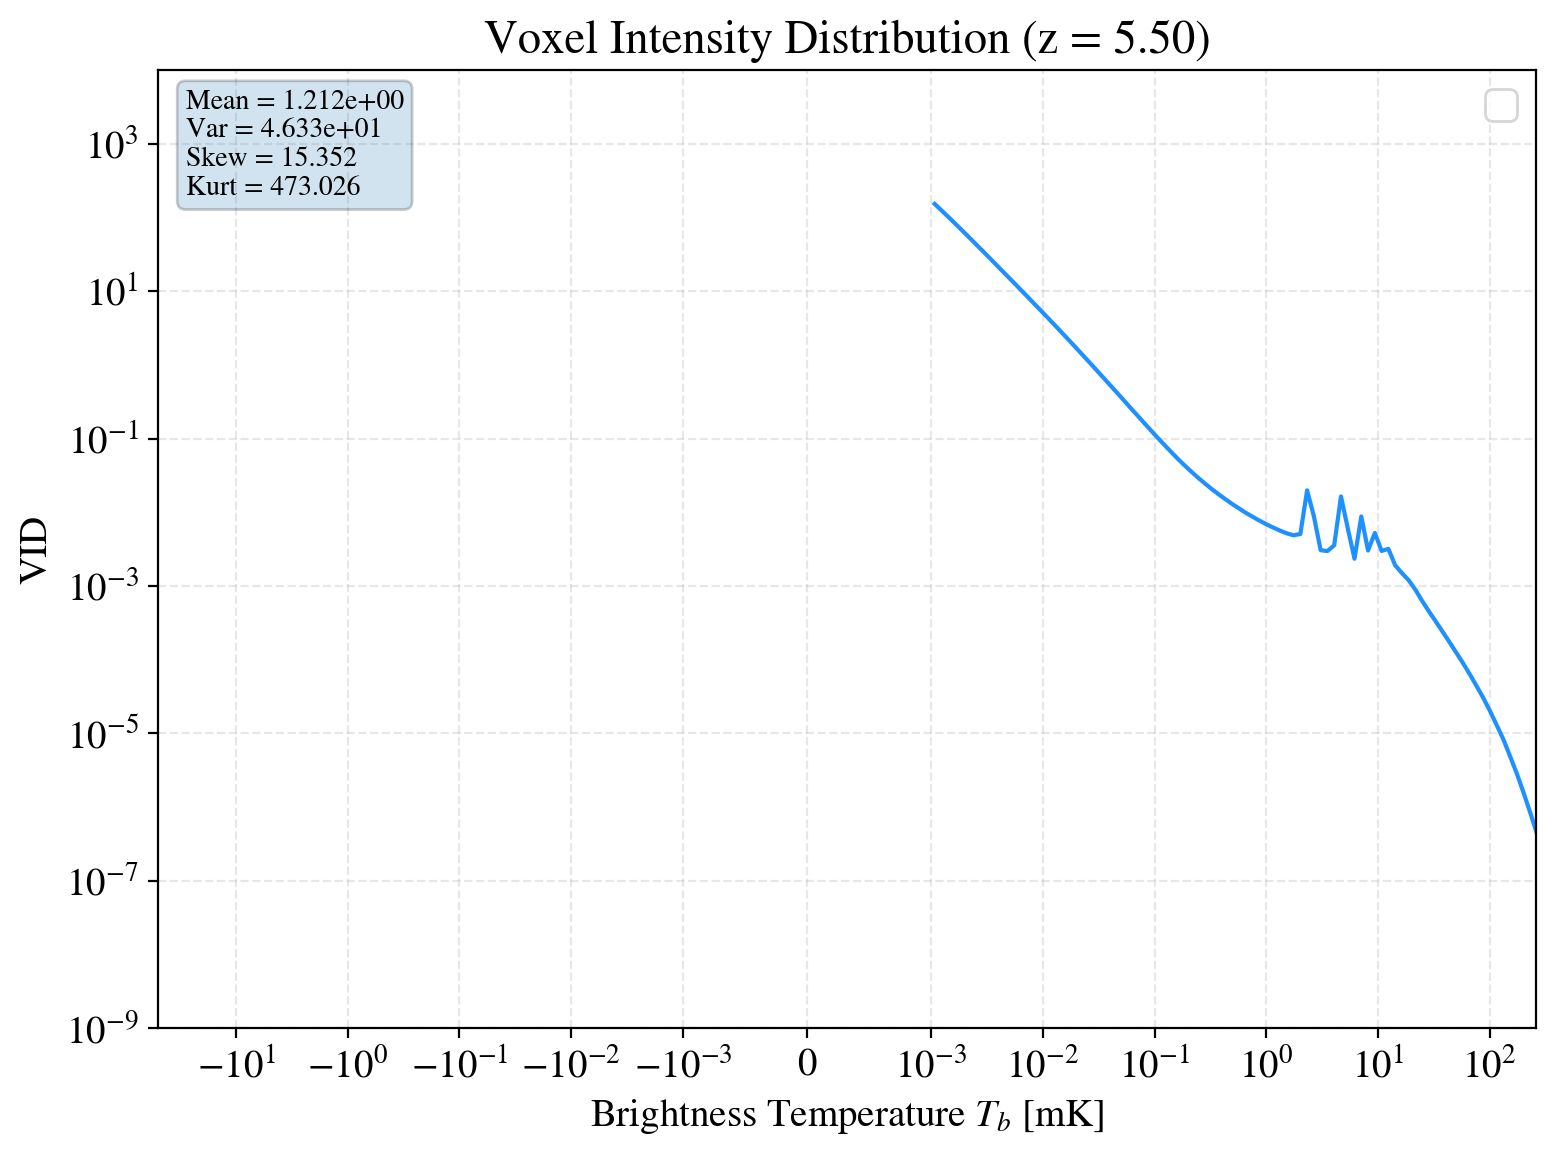

In [19]:
path = "./past/original/Thesan-2/PS_H_Tb_"

snaps = [136, 170, 213, 271, 349, 400]

files = [f"{path}{snap:03d}.out" for snap in snaps]

voxel_res = 95.5 / 512

for PS_file in PS_files:

    # -----------------------------------
    # Snapshot number
    # -----------------------------------
    snap = int(PS_file.split("_")[-1].split(".")[0])

    hdf5_file = f"./past/original/Thesan-2/H_Tb_{snap:03d}.hdf5"

    # -----------------------------------
    # Redshift
    # -----------------------------------
    z = get_redshift(PS_file)

    # -----------------------------------
    # NEW VID function
    # -----------------------------------
    results_pos, results_neg, stats = calculate_vid_logbins(
        hdf5_file=hdf5_file,
        resolution_cMpc=voxel_res,
        bins=100
    )


    #
    # Saving the results
    #
    save_vid_to_csv(
        results_pos,
        results_neg,
        stats,
        filename=f"./bubble_stats/THESAN-2_VID_{snap:03d}.csv"
    )
    print(f"THESAN-2_VID_{snap:03d}.csv is saved!")

    # -----------------------------------
    # NEW plotting function
    # -----------------------------------
    plot_vid(
        results_pos,
        results_neg,
        z=z,
        stats=stats,
        linthresh=0.001
    )

<>:38: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:38: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
/tmp/ipykernel_2962089/2955760229.py:38: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  ax.set_xlabel("Brightness Temperature $\delta T_b$ [mK]")


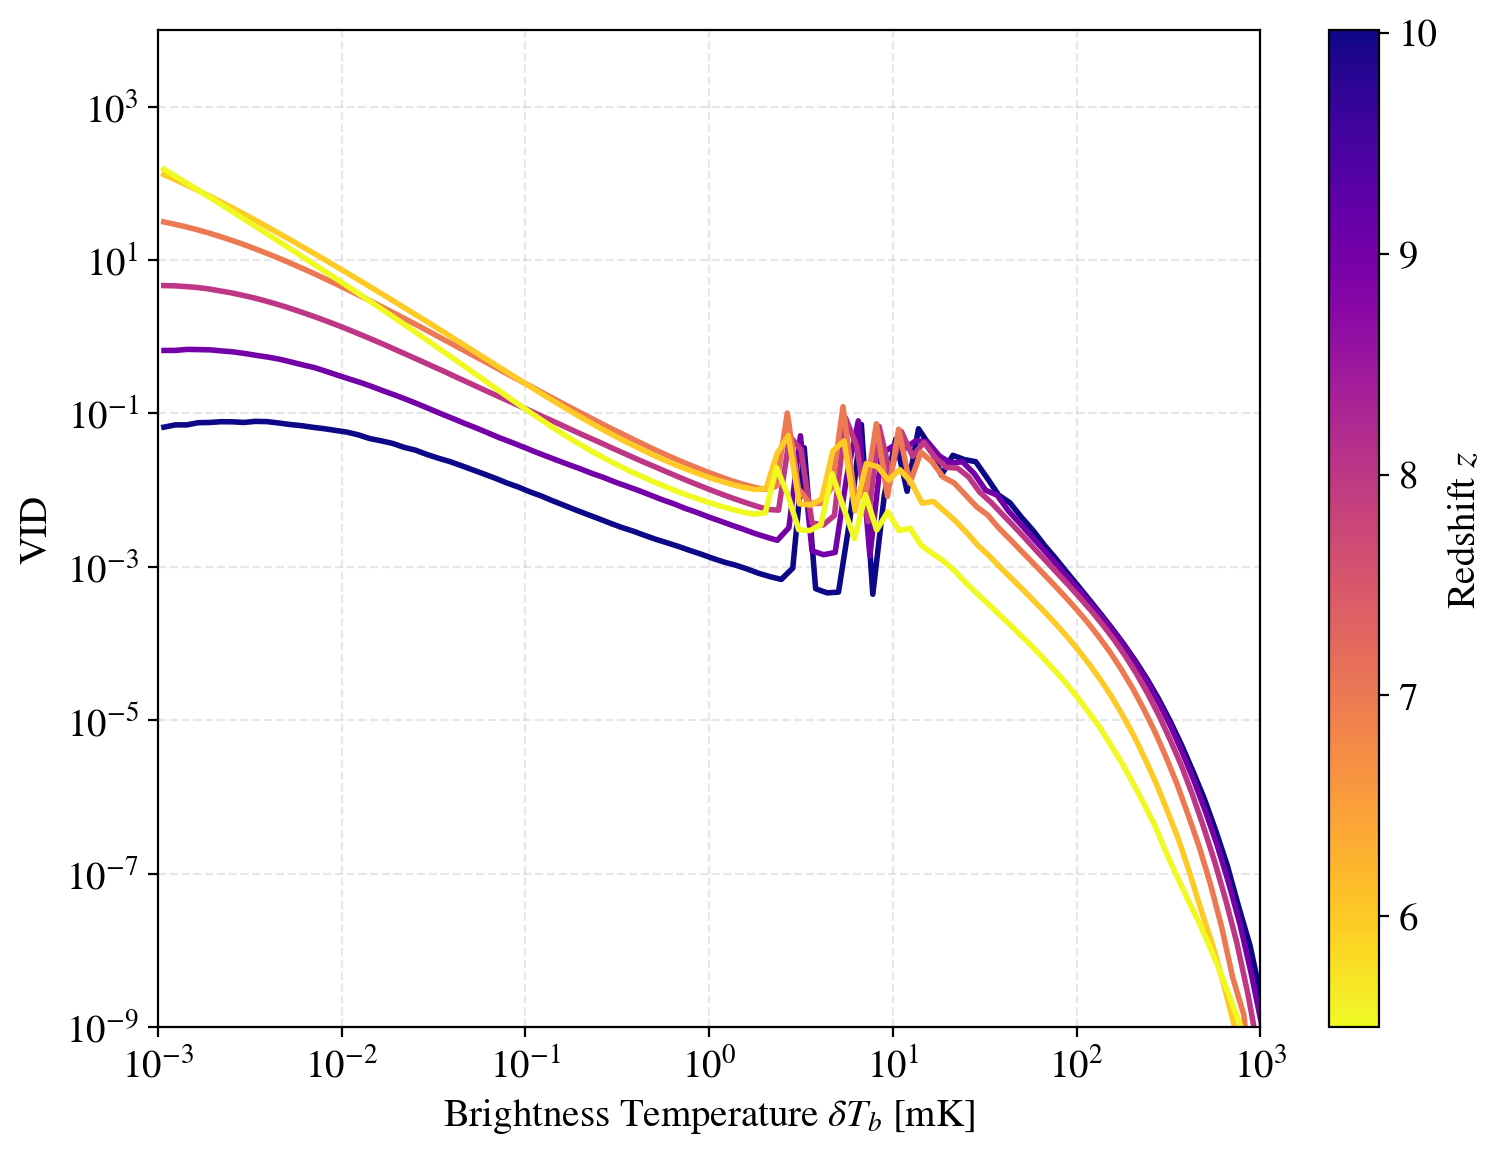

In [20]:
def plot_vid_from_csv(PS_files):

    fig, ax = plt.subplots(figsize=(8,6))   # ✅ FIX

    zs = []
    snaps = []

    for PS_file in PS_files:
        snap = int(PS_file.split("_")[-1].split(".")[0])
        z = get_redshift(PS_file)

        snaps.append(snap)
        zs.append(z)

    zs = np.array(zs)

    cmap = plt.get_cmap("plasma_r")
    norm = mpl.colors.Normalize(vmin=zs.min(), vmax=zs.max())

    for snap, z in zip(snaps, zs):

        filename = f"./bubble_stats/THESAN-2_VID_{snap:03d}.csv"
        Tb, vid = load_vid_csv(filename)

        vid = np.where(vid > 0, vid, 1e-20)

        ax.plot(
            Tb,
            vid,
            color=cmap(norm(z)),
            lw=2
        )

    # Axes settings
    ax.set_xscale("symlog", linthresh=0.001)
    ax.set_yscale("log")

    ax.set_xlabel("Brightness Temperature $\delta T_b$ [mK]")
    ax.set_ylabel("VID")

    ax.set_xlim(1.0e-3, 1000)
    ax.set_ylim(1e-9, 1e4)

    ax.grid(True, which="both", ls="--", alpha=0.3)

    # -----------------------------------
    # FIXED colorbar
    # -----------------------------------
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)   # ✅ THIS FIXES IT
    cbar.set_label(r"Redshift $z$")

    #ax.set_title("Voxel Intensity Distribution Evolution")

    plt.tight_layout()
    plt.show()

plot_vid_from_csv(PS_files)

In [21]:
import gc
# =====================================
# Paths
# =====================================
base = "./past/original/Thesan-2/"

# =====================================
# Snapshot range
# =====================================
snap_range = range(136, 401)  # 400 included

# =====================================
# Find all files and filter by range
# =====================================
hdf5_files_all = sorted(glob.glob(f"{base}/H_Tb_*.hdf5"))

hdf5_files = []
for f in hdf5_files_all:
    snap = int(f.split("_")[-1].split(".")[0])
    if snap in snap_range:
        hdf5_files.append(f)

print(f"Using {len(hdf5_files)} snapshots in range 136-400")

all_stats = []

# =====================================
# Loop
# =====================================
for hdf5_file in hdf5_files:

    snap = int(hdf5_file.split("_")[-1].split(".")[0])
    ps_file = f"{base}/PS_H_Tb_{snap}.out"

    if not os.path.exists(ps_file):
        print(f"[SKIP] Missing PS file for snapshot {snap}")
        continue

    print(f"Processing snapshot {snap}")

    # -----------------------------------
    # Run VID (unchanged)
    # -----------------------------------
    results_pos, results_neg, stats = calculate_vid_logbins(
        hdf5_file=hdf5_file,
        resolution_cMpc=voxel_res,
        bins=100
    )

    # -----------------------------------
    # Get redshift
    # -----------------------------------
    z = get_redshift(ps_file)

    # -----------------------------------
    # Store
    # -----------------------------------
    all_stats.append({
        "snap": snap,
        "z": z,
        "mean": stats["mean"],
        "variance": stats["variance"],
        "skewness": stats["skewness"],
        "kurtosis": stats["kurtosis"]
    })
    del results_pos, results_neg, stats
    gc.collect()


# =====================================
# Save CSV
# =====================================
df = pd.DataFrame(all_stats)
df = df.sort_values("z", ascending=False)

df.to_csv("vid_stats_summary_THESAN-2.csv", index=False)

print("Saved: vid_stats_summary_THESAN-2.csv")

Using 265 snapshots in range 136-400
Processing snapshot 136
Processing snapshot 137
Processing snapshot 138
Processing snapshot 139
Processing snapshot 140
Processing snapshot 141
Processing snapshot 142
Processing snapshot 143
Processing snapshot 144
Processing snapshot 145
Processing snapshot 146
Processing snapshot 147
Processing snapshot 148
Processing snapshot 149
Processing snapshot 150
Processing snapshot 151
Processing snapshot 152
Processing snapshot 153
Processing snapshot 154
Processing snapshot 155
Processing snapshot 156
Processing snapshot 157
Processing snapshot 158
Processing snapshot 159
Processing snapshot 160
Processing snapshot 161
Processing snapshot 162
Processing snapshot 163
Processing snapshot 164
Processing snapshot 165
Processing snapshot 166
Processing snapshot 167
Processing snapshot 168
Processing snapshot 169
Processing snapshot 170
Processing snapshot 171
Processing snapshot 172
Processing snapshot 173
Processing snapshot 174
Processing snapshot 175
Pro

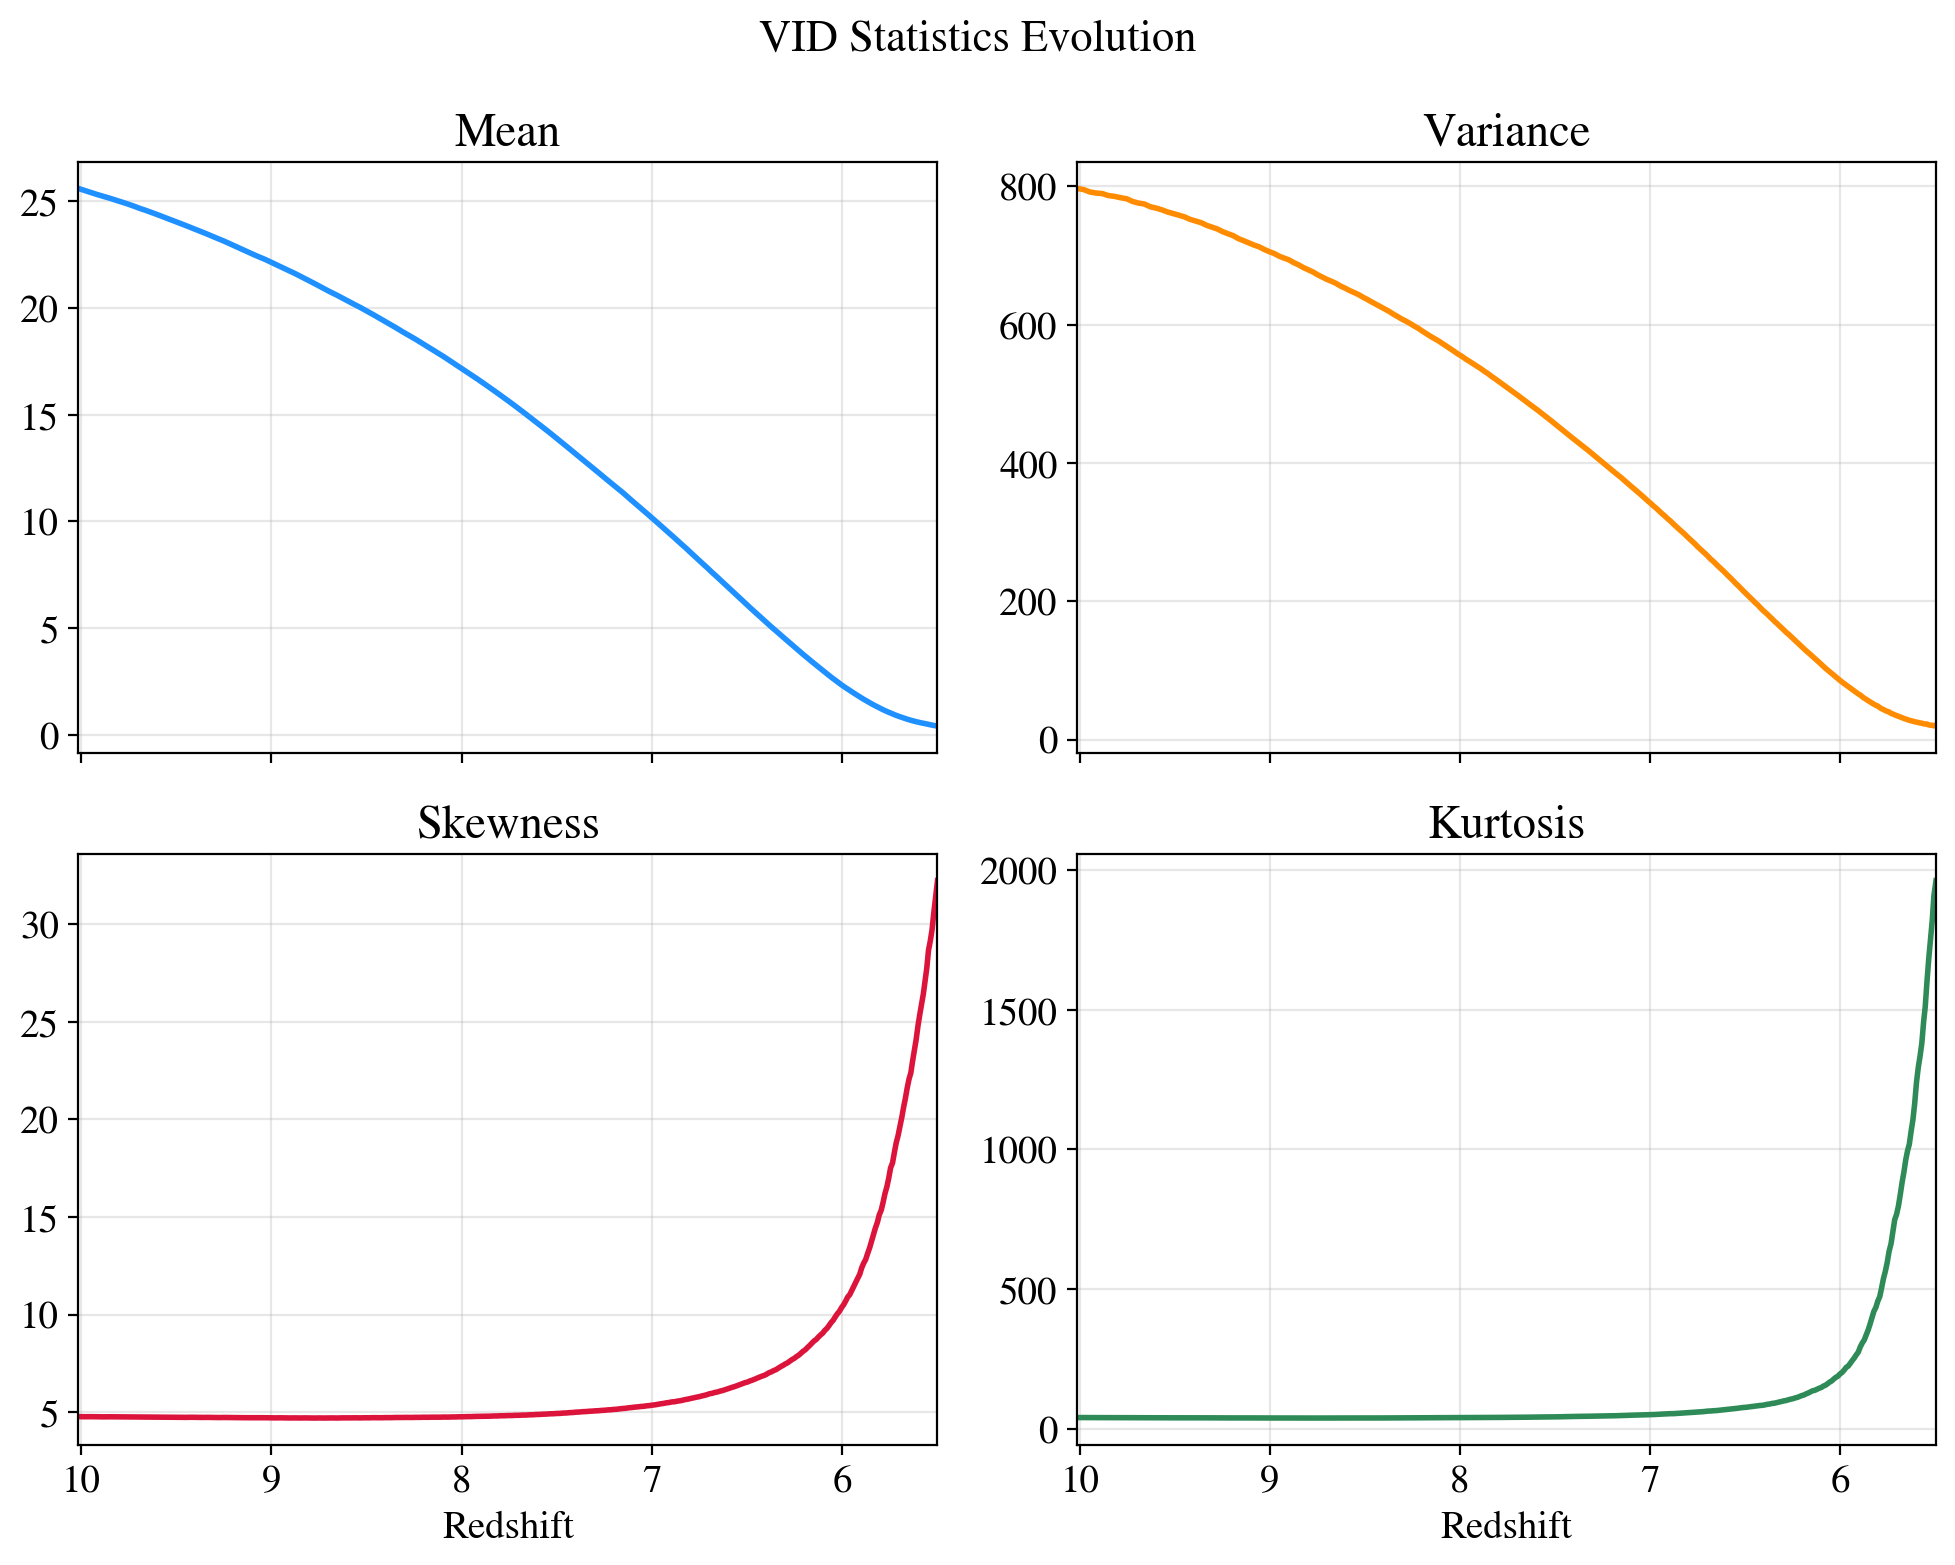

In [22]:

# =====================================
# Plot
# =====================================
z = df["z"]

colors = {
    "mean": "dodgerblue",
    "variance": "darkorange",
    "skewness": "crimson",
    "kurtosis": "seagreen"
}

fig, axes = plt.subplots(2, 2, figsize=(10,8), sharex=True)
axes = axes.flatten()

labels = ["Mean", "Variance", "Skewness", "Kurtosis"]
cols   = ["mean", "variance", "skewness", "kurtosis"]
markers = ["o", "s", "^", "D"]

for ax, col, label, m in zip(axes, cols, labels, markers):

    ax.plot(
        z,
        df[col],
        #marker=m,
        color=colors[col],
        linewidth=2
    )

    ax.set_title(label)
    ax.grid(alpha=0.3)

    # Force redshift direction (high → low)
    ax.set_xlim(max(z), min(z))

# Labels
axes[2].set_xlabel("Redshift")
axes[3].set_xlabel("Redshift")

# Optional: mark key epochs
#for ax in axes:
#    ax.axvline(7, linestyle="--", color="gray", alpha=0.5)
#    ax.axvline(6, linestyle="--", color="gray", alpha=0.5)

plt.suptitle("VID Statistics Evolution", fontsize=16)
plt.tight_layout()
plt.show()

## LUMINA Helium

In [4]:
def plot_vid_He(bin_centers, vid_prob, vid_physical, z, stats=None):
    """
    Plot voxel intensity distribution with redshift annotation

    Parameters:
    - bin_centers: array
    - vid_prob: normalized PDF
    - vid_physical: dN/dT/dV
    - z: redshift
    - stats: optional dict
    """

    fig = plt.figure(figsize=(8,6))

    # -----------------------------------
    # Plot
    # -----------------------------------
    plt.plot(bin_centers, vid_prob, label="Probability VID")
    plt.plot(bin_centers, vid_physical, linestyle='--', label="Physical VID")

    # -----------------------------------
    # Labels
    # -----------------------------------
    plt.xlabel(r"Brightness Temperature $T_b$ [$/mu$K]")
    plt.ylabel("VID")

    plt.yscale("log")
    plt.grid(True, alpha=0.3)

    # -----------------------------------
    # Title with redshift
    # -----------------------------------
    plt.title(f"Voxel Intensity Distribution (z = {z:.2f})")

    plt.legend()

    # -----------------------------------
    # Stats box (top-left)
    # -----------------------------------
    if stats is not None:
        textstr = (
            f"z = {z:.2f}\n"
            f"Mean = {stats['mean']:.3e}\n"
            f"Var = {stats['variance']:.3e}\n"
            f"Skew = {stats['skewness']:.3f}\n"
            f"Kurt = {stats['kurtosis']:.3f}"
        )

        plt.text(0.02, 0.98, textstr,
                 transform=plt.gca().transAxes,
                 verticalalignment='top',
                 fontsize=10,
                 bbox=dict(boxstyle="round", alpha=0.2))

    plt.tight_layout()
    plt.show()


He_VID_406.csv is saved!


/tmp/ipykernel_212846/2817616901.py:391: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


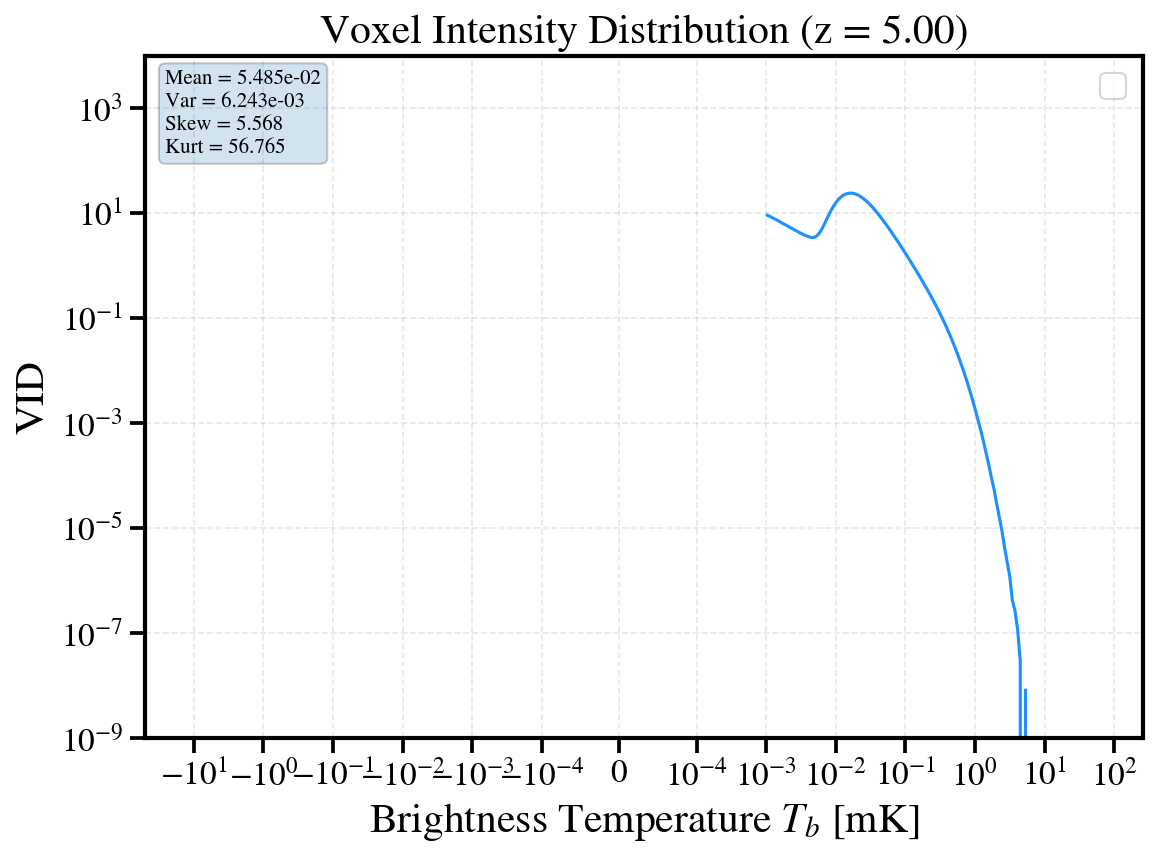

He_VID_450.csv is saved!


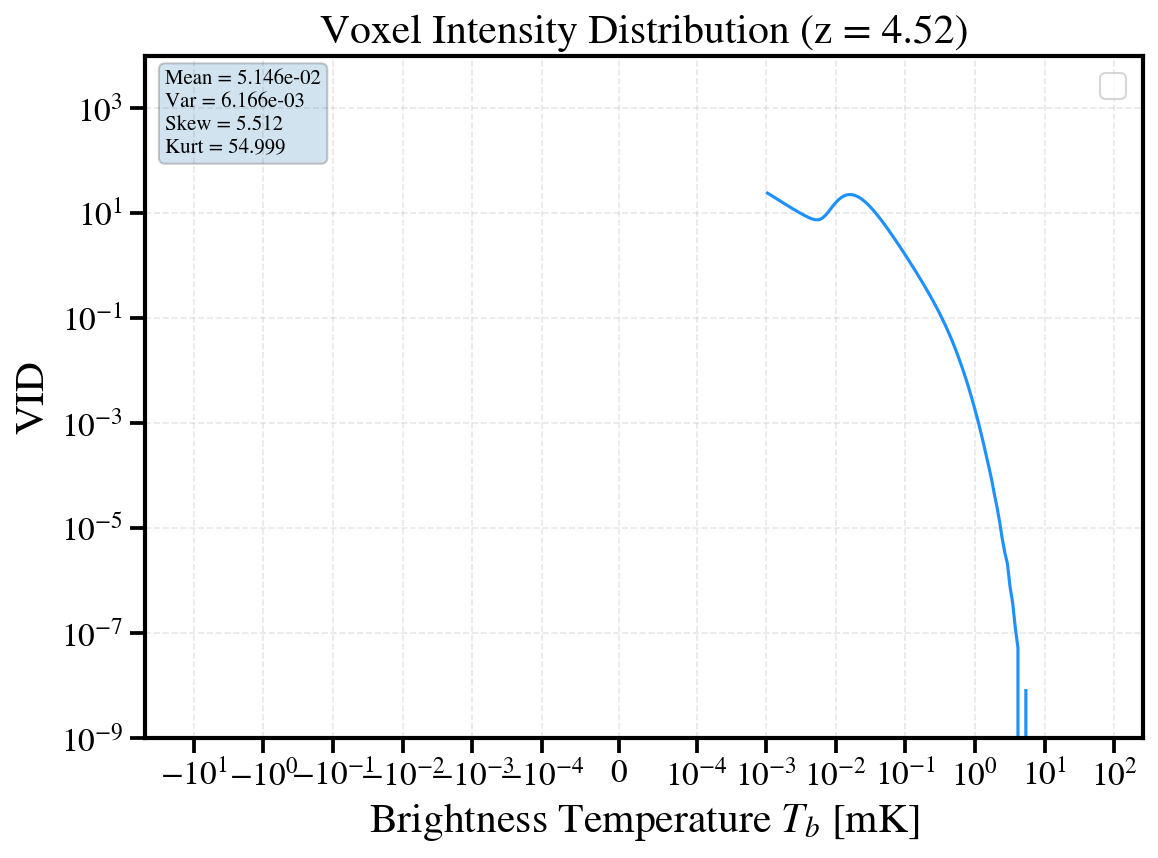

He_VID_471.csv is saved!


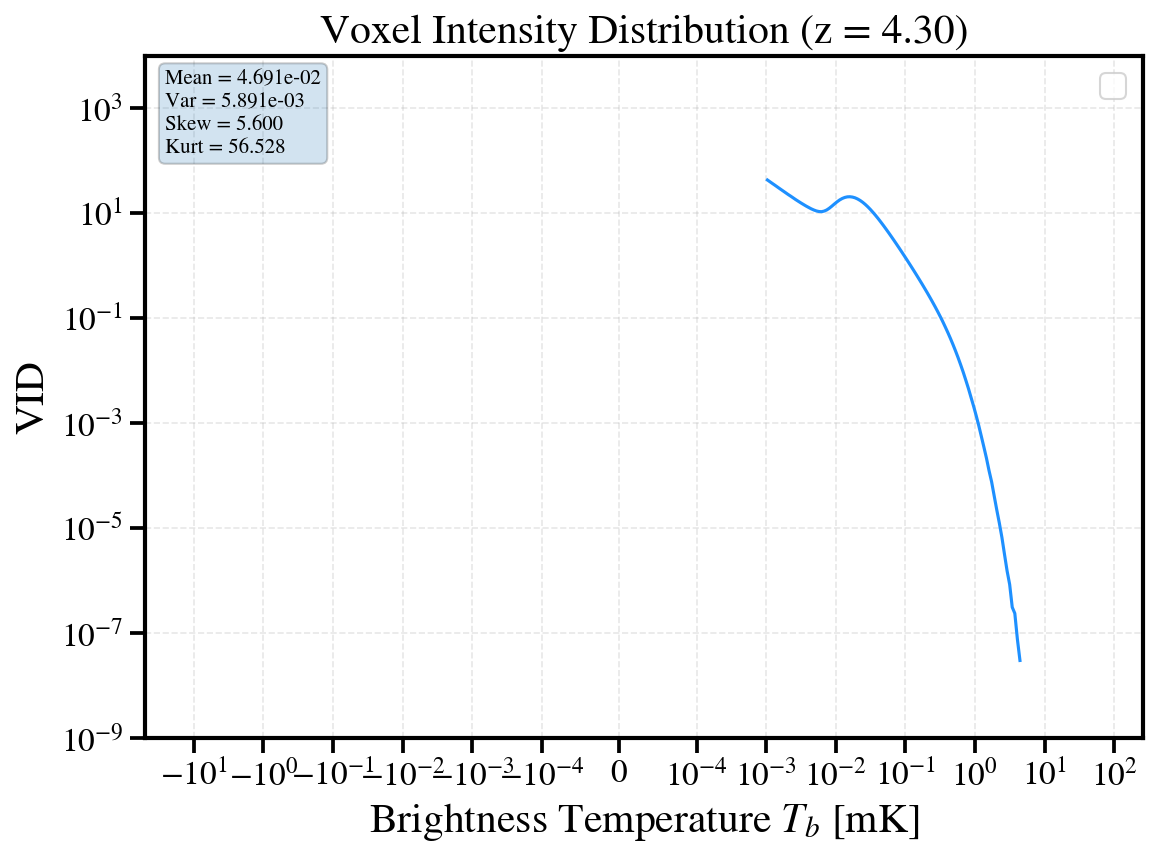

He_VID_487.csv is saved!


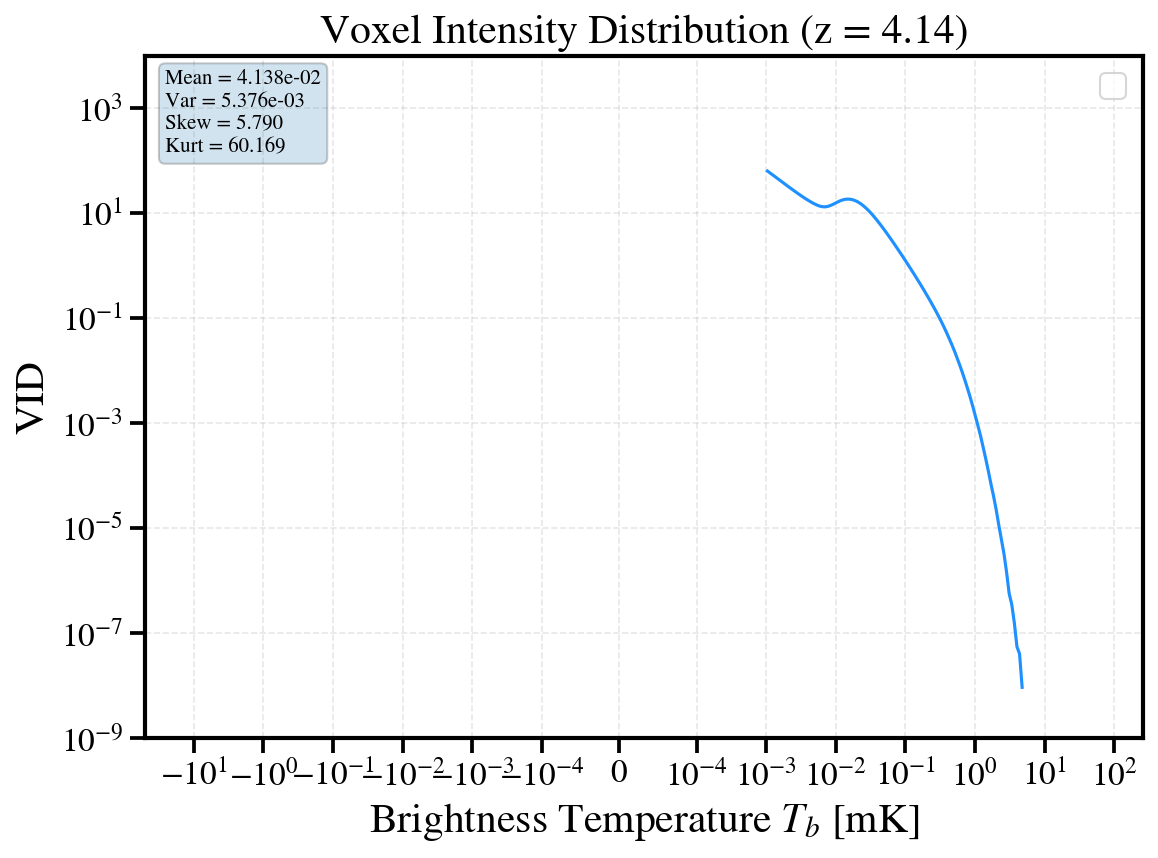

He_VID_500.csv is saved!


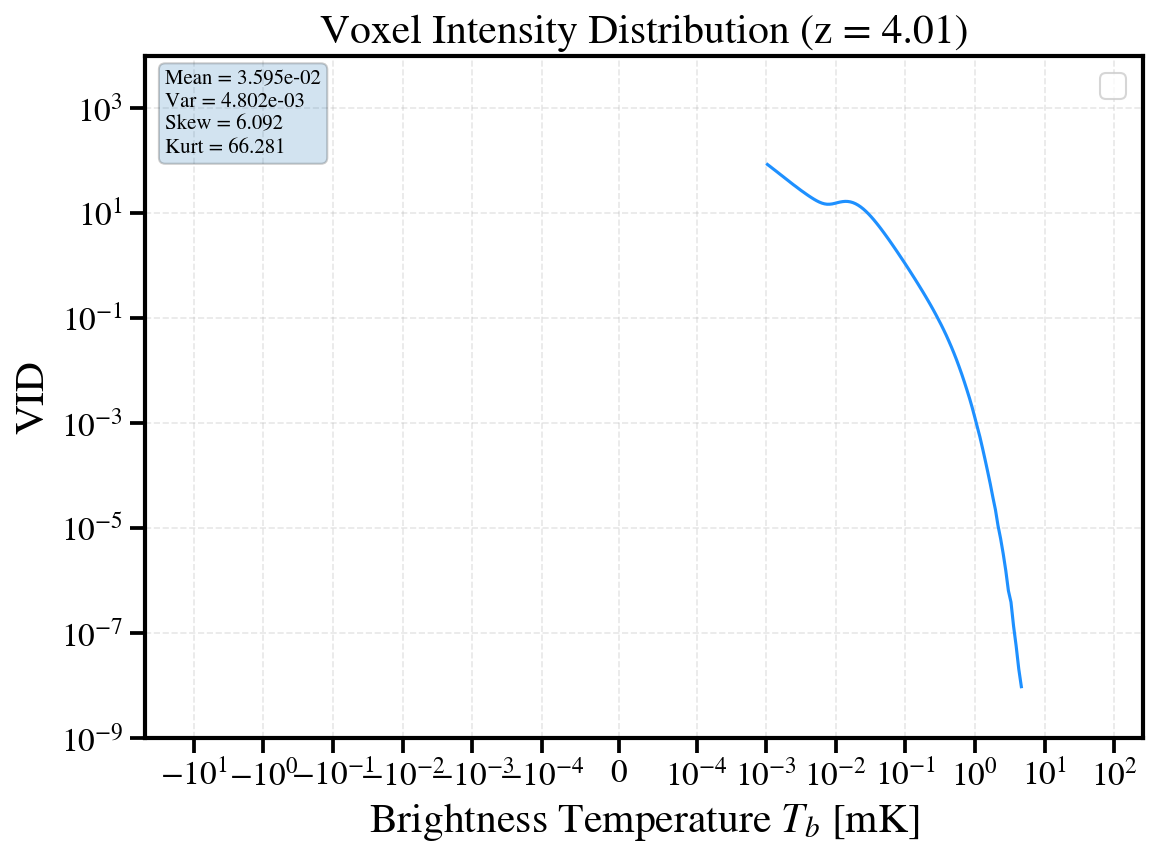

He_VID_514.csv is saved!


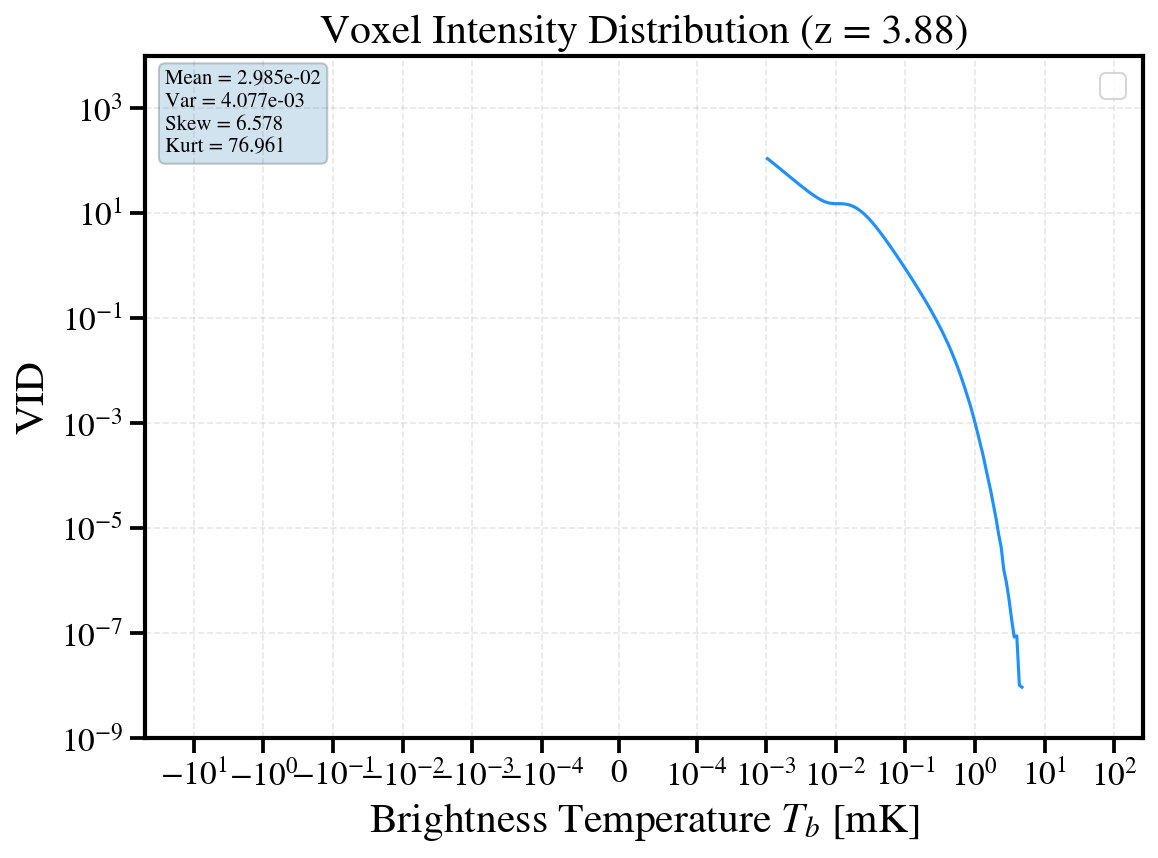

He_VID_529.csv is saved!


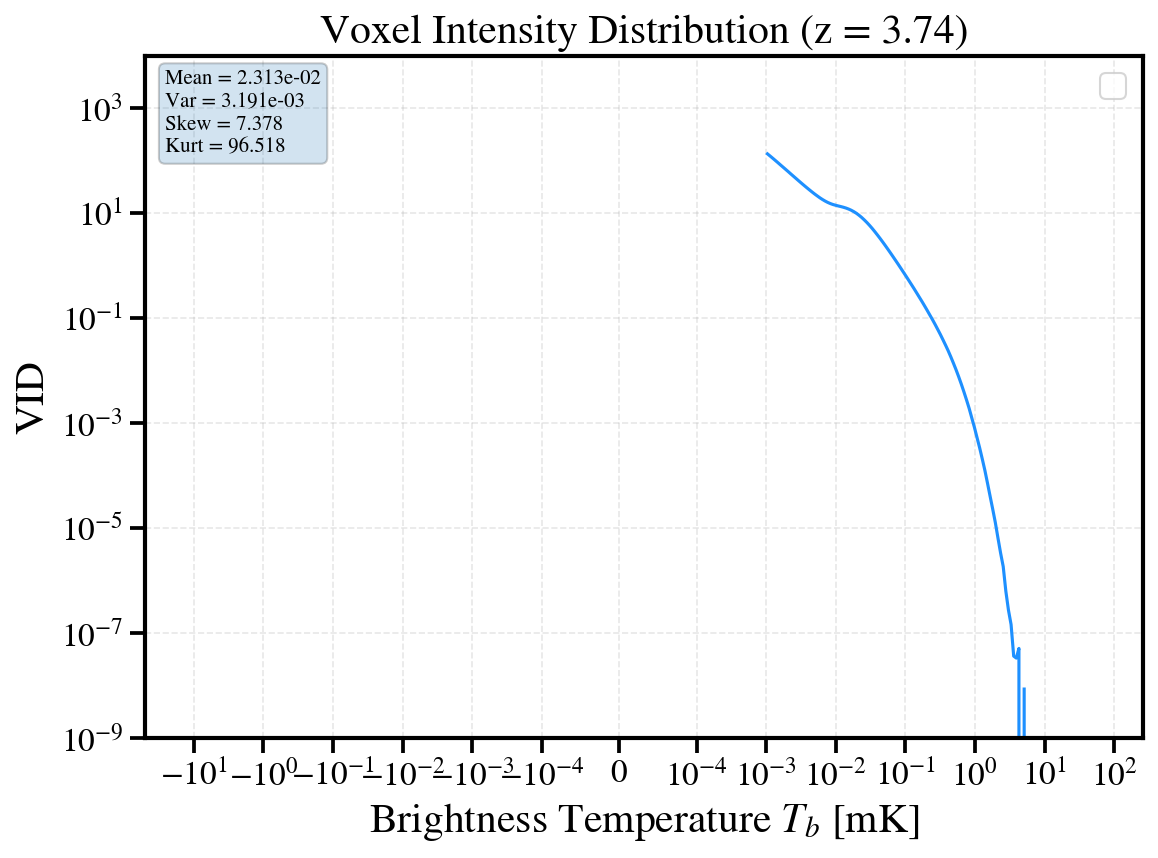

He_VID_558.csv is saved!


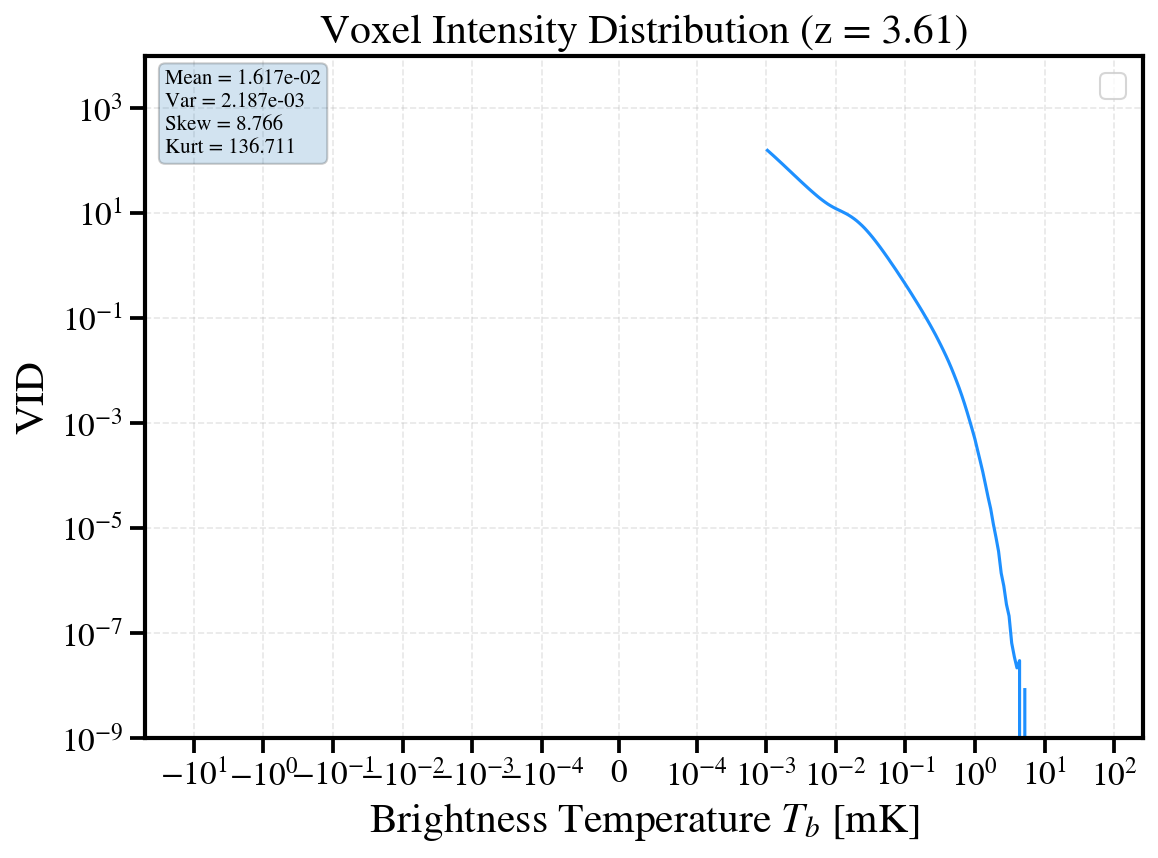

He_VID_596.csv is saved!


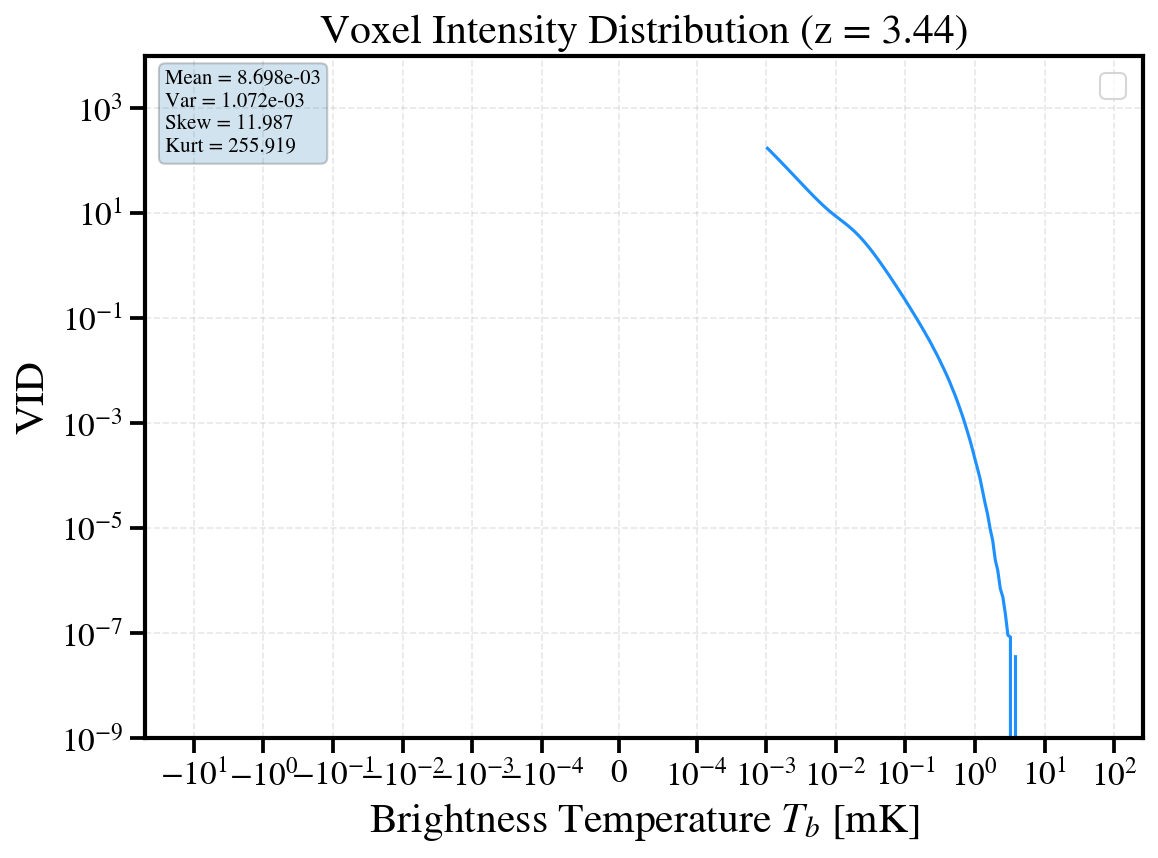

In [5]:
PS_files = [
    #"./TS_TK/He/Tb/PS_Tb_He_156.out",
    #"./TS_TK/He/Tb/PS_Tb_He_169.out",
    #"./TS_TK/He/Tb/PS_Tb_He_181.out",
    #"./TS_TK/He/Tb/PS_Tb_He_195.out",
    #"./TS_TK/He/Tb/PS_Tb_He_209.out",
    #"./TS_TK/He/Tb/PS_Tb_He_224.out",
    #"./TS_TK/He/Tb/PS_Tb_He_255.out",
    #"./TS_TK/He/Tb/PS_Tb_He_289.out",
    #"./TS_TK/He/Tb/PS_Tb_He_325.out",
    #"./TS_TK/He/Tb/PS_Tb_He_364.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_406.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_450.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_471.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_487.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_500.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_514.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_529.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_558.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_596.out",
]

voxel_res = 500 / 640

for PS_file in PS_files:

    # -----------------------------------
    # Snapshot number
    # -----------------------------------
    snap = int(PS_file.split("_")[-1].split(".")[0])

    hdf5_file = f"/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/RIN_{snap:03d}.hdf5"
    #PS_file = f"/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/He/Tb/PS_Tb_He_{snap:03d}.out"
    
    # -----------------------------------
    # Redshift
    # -----------------------------------
    z = get_redshift(PS_file)

    # -----------------------------------
    # NEW VID function
    # -----------------------------------
    results_pos, results_neg, stats = calculate_vid_logbins(
        hdf5_file=hdf5_file,
        resolution_cMpc=voxel_res,
        bins=100
    )


    #
    # Saving the results
    #
    save_vid_to_csv(
        results_pos,
        results_neg,
        stats,
        filename=f"./bubble_stats/All_He_VID_{snap:03d}.csv"
    )
    print(f"He_VID_{snap:03d}.csv is saved!")

    # -----------------------------------
    # NEW plotting function
    # -----------------------------------
    plot_vid(
        results_pos,
        results_neg,
        z=z,
        stats=stats,
        linthresh=0.0001
    )


<>:42: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:42: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
/tmp/ipykernel_707193/4125097616.py:42: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  ax.set_xlabel("Brightness Temperature $\delta T_b$ [$\mu$K]")


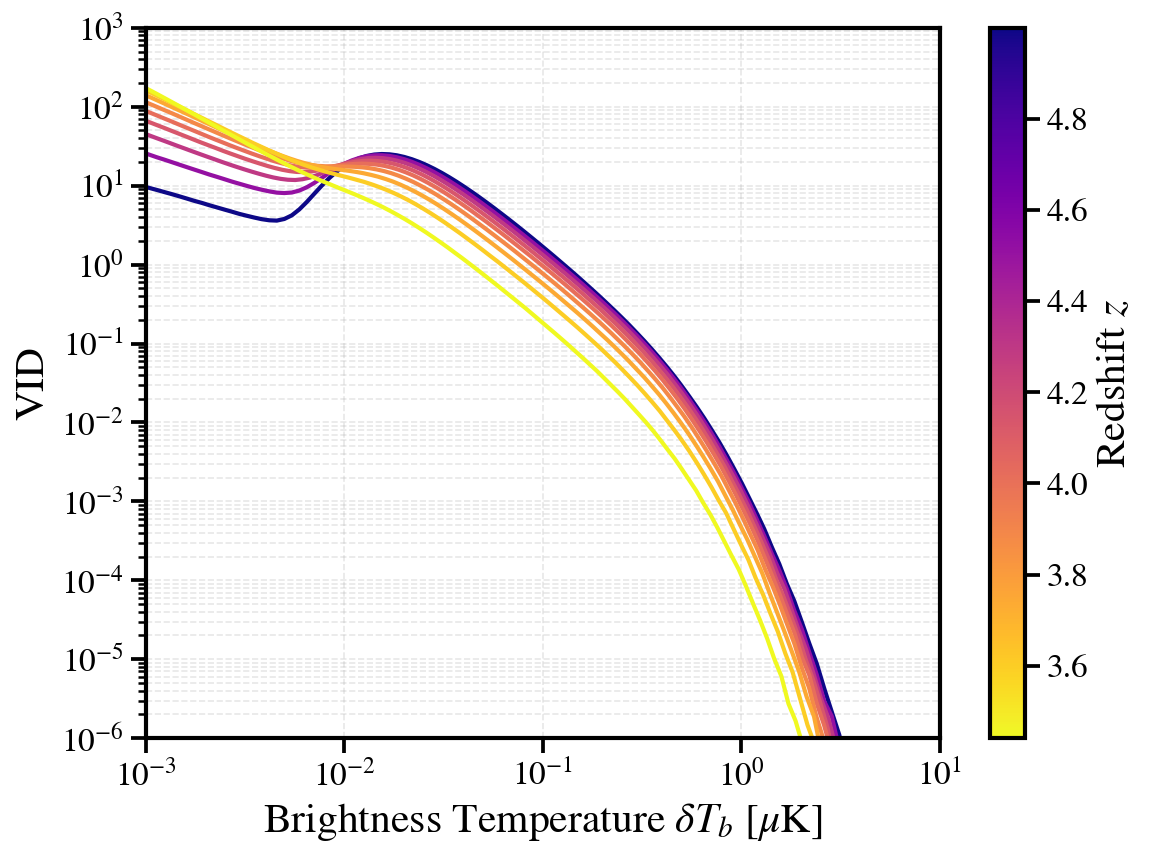

In [30]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

def plot_vid_from_csv(PS_files):

    fig, ax = plt.subplots(figsize=(8,6))   # ✅ FIX

    zs = []
    snaps = []

    for PS_file in PS_files:
        snap = int(PS_file.split("_")[-1].split(".")[0])
        z = get_redshift(PS_file)

        snaps.append(snap)
        zs.append(z)

    zs = np.array(zs)

    cmap = plt.get_cmap("plasma_r")
    norm = mpl.colors.Normalize(vmin=zs.min(), vmax=zs.max())

    for snap, z in zip(snaps, zs):

        filename = f"./bubble_stats/All_He_VID_{snap:03d}.csv"
        Tb, vid = load_vid_csv(filename)

        vid = np.where(vid > 0, vid, 1e-20)

        ax.plot(
            Tb,
            vid,
            color=cmap(norm(z)),
            lw=2
        )

    # Axes settings
    ax.set_xscale("symlog", linthresh=0.001)
    ax.set_yscale("log")

    ax.set_xlabel("Brightness Temperature $\delta T_b$ [$\mu$K]")
    ax.set_ylabel("VID")

    ax.set_xlim(1.0e-3, 10)
    ax.set_ylim(1e-6, 1e3)

    ax.grid(True, which="both", ls="--", alpha=0.3)

    # -----------------------------------
    # FIXED colorbar
    # -----------------------------------
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)   # ✅ THIS FIXES IT
    cbar.set_label(r"Redshift $z$")

    #ax.set_title("Voxel Intensity Distribution Evolution")

    plt.tight_layout()
    plt.show()

plot_vid_from_csv(PS_files)

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# =====================================
# Paths
# =====================================
base_hdf5 = "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He"
base_ps   = base_hdf5
import gc

# =====================================
# Snapshot range
# =====================================
snap_range = range(318, 706)  # 705 included

# =====================================
# Find all files and filter by range
# =====================================
hdf5_files_all = sorted(glob.glob(f"{base_hdf5}/RIN_*.hdf5"))

hdf5_files = []
for f in hdf5_files_all:
    snap = int(f.split("_")[-1].split(".")[0])
    if snap in snap_range:
        hdf5_files.append(f)

print(f"Using {len(hdf5_files)} snapshots in range 181–705")

all_stats = []

# =====================================
# Loop
# =====================================
for hdf5_file in hdf5_files:

    snap = int(hdf5_file.split("_")[-1].split(".")[0])
    ps_file = f"{base_ps}/PS_{snap}.out"

    if not os.path.exists(ps_file):
        print(f"[SKIP] Missing PS file for snapshot {snap}")
        continue

    print(f"Processing snapshot {snap}")

    # -----------------------------------
    # Run VID (unchanged)
    # -----------------------------------
    results_pos, results_neg, stats = calculate_vid_logbins(
        hdf5_file=hdf5_file,
        resolution_cMpc=500/640,
        bins=100
    )

    # -----------------------------------
    # Get redshift
    # -----------------------------------
    z = get_redshift(ps_file)

    # -----------------------------------
    # Store
    # -----------------------------------
    all_stats.append({
        "snap": snap,
        "z": z,
        "mean": stats["mean"],
        "variance": stats["variance"],
        "skewness": stats["skewness"],
        "kurtosis": stats["kurtosis"]
    })
    del results_pos, results_neg, stats
    gc.collect()


# =====================================
# Save CSV
# =====================================
df = pd.DataFrame(all_stats)
df = df.sort_values("z", ascending=False)

df.to_csv("All_vid_stats_summary_He.csv", index=False)

print("Saved: vid_stats_summary_He.csv")

Using 29 snapshots in range 181–705
Processing snapshot 325
Processing snapshot 406
Processing snapshot 450
Processing snapshot 452
Processing snapshot 471
Processing snapshot 487
Processing snapshot 500
Processing snapshot 501
Processing snapshot 514
Processing snapshot 529
Processing snapshot 540
Processing snapshot 549
Processing snapshot 558
Processing snapshot 565
Processing snapshot 574
Processing snapshot 582
Processing snapshot 589
Processing snapshot 596
Processing snapshot 610
Processing snapshot 620
Processing snapshot 630
Processing snapshot 640
Processing snapshot 650
Processing snapshot 660
Processing snapshot 670
Processing snapshot 680
Processing snapshot 690
Processing snapshot 700
Processing snapshot 705
Saved: vid_stats_summary_He.csv


/tmp/ipykernel_2304531/1160844872.py:280: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


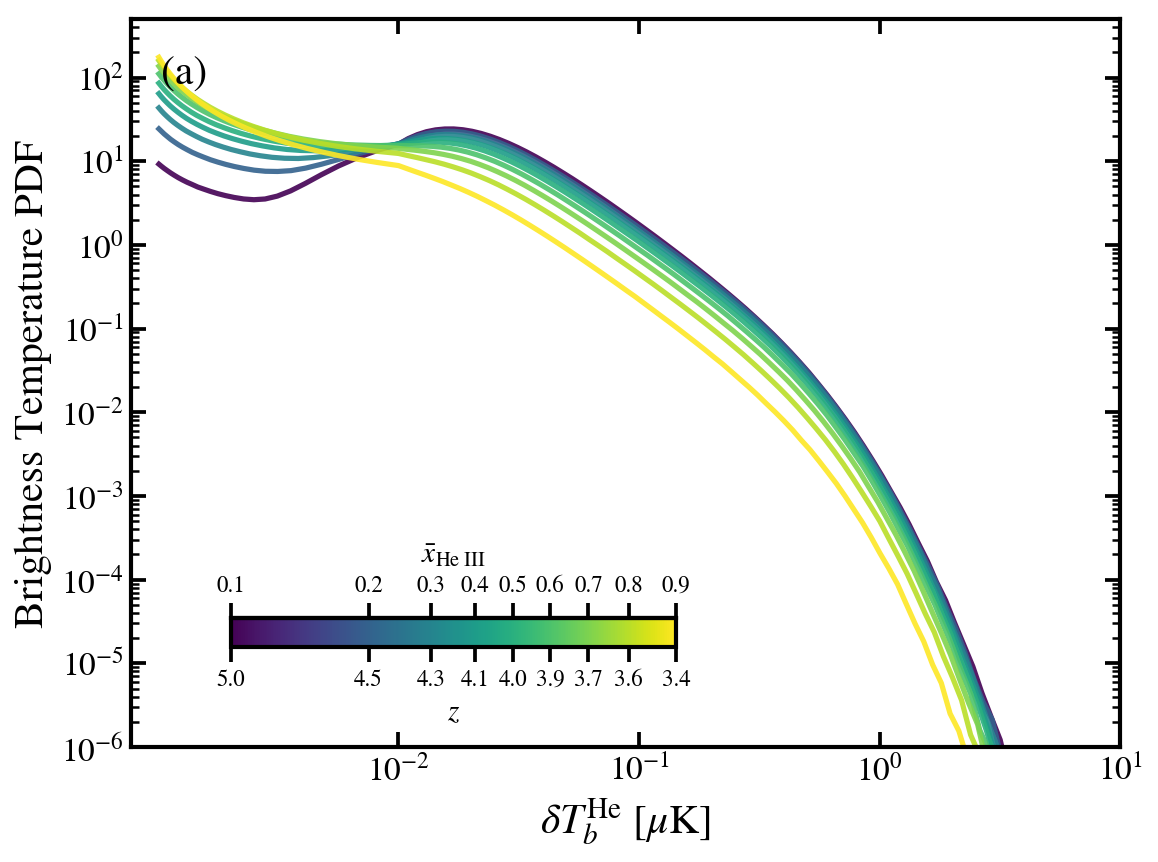

In [7]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# --------------------------------
# Publication-quality style
# --------------------------------

mpl.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,

    # thicker axis box
    "axes.linewidth": 2.0,

    # thicker major/minor ticks
    "xtick.major.width": 1.8,
    "ytick.major.width": 1.8,
    "xtick.minor.width": 1.2,
    "ytick.minor.width": 1.2,

    "xtick.major.size": 7,
    "ytick.major.size": 7,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,

    # figure quality
    "figure.dpi": 150,
    "savefig.dpi": 300,
})

# --------------------------------
# Input files
# --------------------------------

PS_files = [
    #"./TS_TK/He/Tb/PS_Tb_He_156.out",
    #"./TS_TK/He/Tb/PS_Tb_He_169.out",
    #"./TS_TK/He/Tb/PS_Tb_He_181.out",
    #"./TS_TK/He/Tb/PS_Tb_He_195.out",
    #"./TS_TK/He/Tb/PS_Tb_He_209.out",
    #"./TS_TK/He/Tb/PS_Tb_He_224.out",
    #"./TS_TK/He/Tb/PS_Tb_He_255.out",
    #"./TS_TK/He/Tb/PS_Tb_He_289.out",
    #"./TS_TK/He/Tb/PS_Tb_He_325.out",
    #"./TS_TK/He/Tb/PS_Tb_He_364.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_406.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_450.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_471.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_487.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_500.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_514.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_529.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_558.out",
    "/orcd/data/mvogelsb/004/chcho/compute_J_alpha_He/Tb_He/PS_596.out",
]
# --------------------------------
# Main function
# --------------------------------

def plot_vid_from_csv(PS_files):

    fig, ax = plt.subplots(figsize=(8, 6))

    zs = []
    snaps = []

    # --------------------------------
    # Collect redshifts
    # --------------------------------

    for PS_file in PS_files:
        snap = int(PS_file.split("_")[-1].split(".")[0])
        z = get_redshift(PS_file)

        snaps.append(snap)
        zs.append(z)

    zs = np.array(zs)

    # --------------------------------
    # Colormap
    # --------------------------------

    cmap = plt.get_cmap("viridis_r")
    norm = mpl.colors.Normalize(
        vmin=zs.min(),
        vmax=zs.max()
    )

    # --------------------------------
    # Plot curves
    # --------------------------------

    for snap, z in zip(snaps, zs):

        filename = f"./bubble_stats/All_He_VID_{snap:03d}.csv"

        Tb, vid = load_vid_csv(filename)

        # avoid log(0)
        vid = np.where(
            vid > 0,
            vid,
            1e-20
        )

        ax.plot(
            Tb,
            vid,
            color=cmap(norm(z)),
            lw=2.5,
            alpha=0.9
        )

    # --------------------------------
    # Axis scales
    # --------------------------------

    ax.set_xscale(
        "symlog",
        linthresh=0.01
    )

    ax.set_yscale("log")

    # --------------------------------
    # Labels
    # --------------------------------

    ax.set_xlabel(
        r"$\delta T_b^{\mathrm{He}}\ [\mu$K]"
    )

    # Better than just "VID"
    ax.set_ylabel(
        "Brightness Temperature PDF"
    )

    # --------------------------------
    # Limits
    # --------------------------------

    ax.set_xlim(1.0e-6, 10)
    ax.set_ylim(1e-6, 5e2)

    # --------------------------------
    # Tick style
    # --------------------------------

    ax.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True
    )

    ax.minorticks_on()

    # --------------------------------
    # Embedded horizontal colorbar
    # --------------------------------

    sm = mpl.cm.ScalarMappable(
        cmap=cmap,
        norm=norm
    )
    sm.set_array([])

    cax = inset_axes(
        ax,
        width="45%",
        height="4%",
        loc="lower left",
        borderpad=3.0
    )

    cbar = fig.colorbar(
        sm,
        cax=cax,
        orientation="horizontal"
    )

    cbar.set_label(
        r"$z$",
        fontsize=14
    )

    cbar.ax.tick_params(
        labelsize=11
    )

    # --------------------------------
    # Exact z ↔ x_HII mapping
    # --------------------------------

    # exact mapping
    xhii_vals = np.array([
        0.90,
        0.80,
        0.70,
        0.60,
        0.50,
        0.40,
        0.30,
        0.20,
        0.10
    ])
    
    z_match = np.array([
        3.439090,
        3.606240,
        3.746897,
        3.880495,
        4.011606,
        4.144300,
        4.299100,
        4.517370,
        4.999257
    ])

    # bottom ticks = z
    cbar.set_ticks(z_match)
    cbar.set_ticklabels(
        [f"{z:.1f}" for z in z_match]
    )

    # high-z on left
    cbar.ax.invert_xaxis()

    # --------------------------------
    # Top axis = ionized fraction
    # --------------------------------

    top_ax = cbar.ax.twiny()
    top_ax.set_xlim(
        cbar.ax.get_xlim()
    )

    top_ax.set_xticks(z_match)
    top_ax.set_xticklabels(
        [f"{x:.1f}" for x in xhii_vals],
        fontsize=11
    )

    top_ax.set_xlabel(
        r"$\bar{x}_{\mathrm{He \ III}}$",
        fontsize=14,
        labelpad=6
    )

    # --------------------------------
    # Panel label
    # --------------------------------

    ax.text(
        0.03,
        0.95,
        r"(a)",
        transform=ax.transAxes,
        fontsize=20,
        ha="left",
        va="top"
    )

    # --------------------------------
    # Save / show
    # --------------------------------

    # plt.savefig(
    #     "VID_HI.png",
    #     dpi=300,
    #     bbox_inches="tight"
    # )

    plt.tight_layout()
    plt.show()


# --------------------------------
# Run
# --------------------------------

plot_vid_from_csv(PS_files)

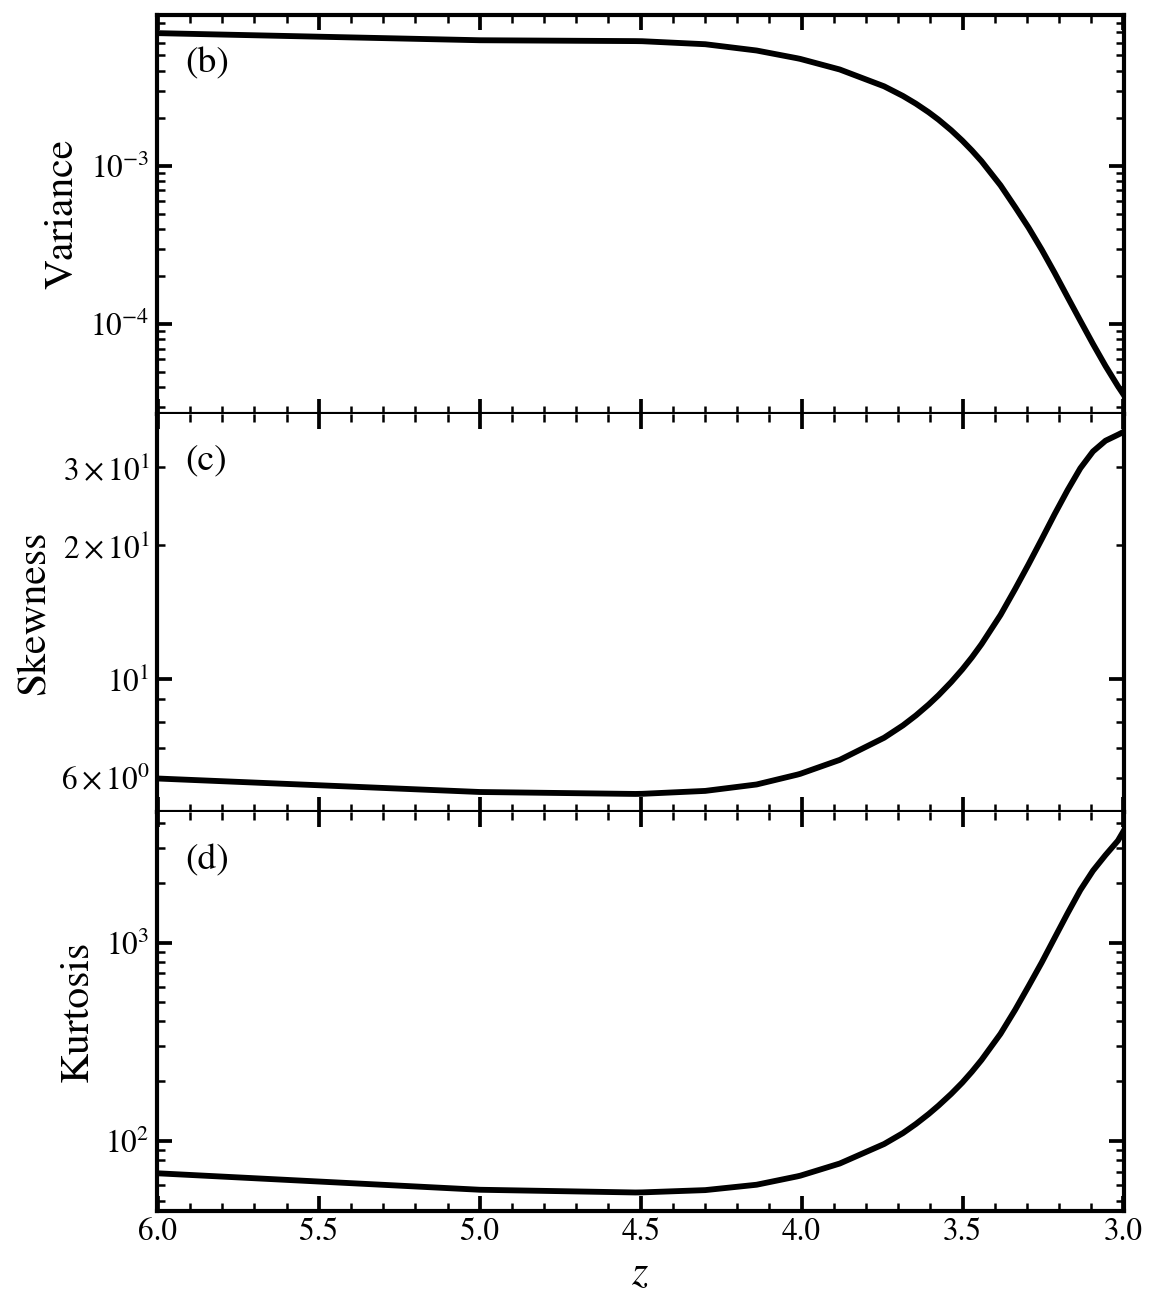

49398

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import gc

# =====================================
# Publication-quality style
# =====================================

mpl.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,

    # thicker axes box
    "axes.linewidth": 2.0,

    # thicker ticks
    "xtick.major.width": 1.8,
    "ytick.major.width": 1.8,
    "xtick.minor.width": 1.2,
    "ytick.minor.width": 1.2,

    "xtick.major.size": 7,
    "ytick.major.size": 7,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,

    # output quality
    "figure.dpi": 150,
    "savefig.dpi": 300,
})

# =====================================
# Read data
# =====================================

#df = pd.read_csv("All_vid_stats_summary_156_406.csv") # hydrogen
df = pd.read_csv("All_vid_stats_summary_He.csv") # helium


z = df["z"]

# =====================================
# Better colors
# =====================================

colors = {
    "variance": "black",# "royalblue",
    "skewness": "black",#"deeppink",
    "kurtosis": "black",#"limegreen"

}

labels = [
    r"Variance",
    r"Skewness",
    r"Kurtosis"
]

cols = [
    "variance",
    "skewness",
    "kurtosis"
]

panel_labels = [
    r"(b)",
    r"(c)",
    r"(d)"
]

# =====================================
# Figure (attached stacked panels)
# =====================================

fig, axes = plt.subplots(
    3, 1,
    figsize=(8, 9),
    sharex=True,
    gridspec_kw={"hspace": 0.0}   # <- attach panels tightly
)

# =====================================
# Plot each panel
# =====================================

for i, (ax, col, label, panel) in enumerate(
    zip(axes, cols, labels, panel_labels)
):

    values = df[col].copy()

    # safe for log scale
    values = np.where(values > 0, values, np.nan)

    ax.plot(
        z,
        values,
        color=colors[col],
        linewidth=2.8
    )

    # reverse redshift direction (high -> low)
    ax.set_xlim(max(z), min(z))

    # log y-axis
    ax.set_yscale("log")

    # ticks
    ax.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True
    )

    ax.minorticks_on()

    # y label
    ax.set_ylabel(label)

    # remove top spine overlap look
    if i != 0:
        ax.spines["top"].set_visible(False)

    # panel label
    ax.text(
        0.03,
        0.92,
        panel,
        transform=ax.transAxes,
        fontsize=18,
        ha="left",
        va="top"
    )

# =====================================
# X-axis only at bottom
# =====================================

axes[-1].set_xlabel(r"$z$")

for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)

# =====================================
# Tight layout
# =====================================

plt.tight_layout()

# plt.savefig(
#     "VID_statistics_stacked_log.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

gc.collect()

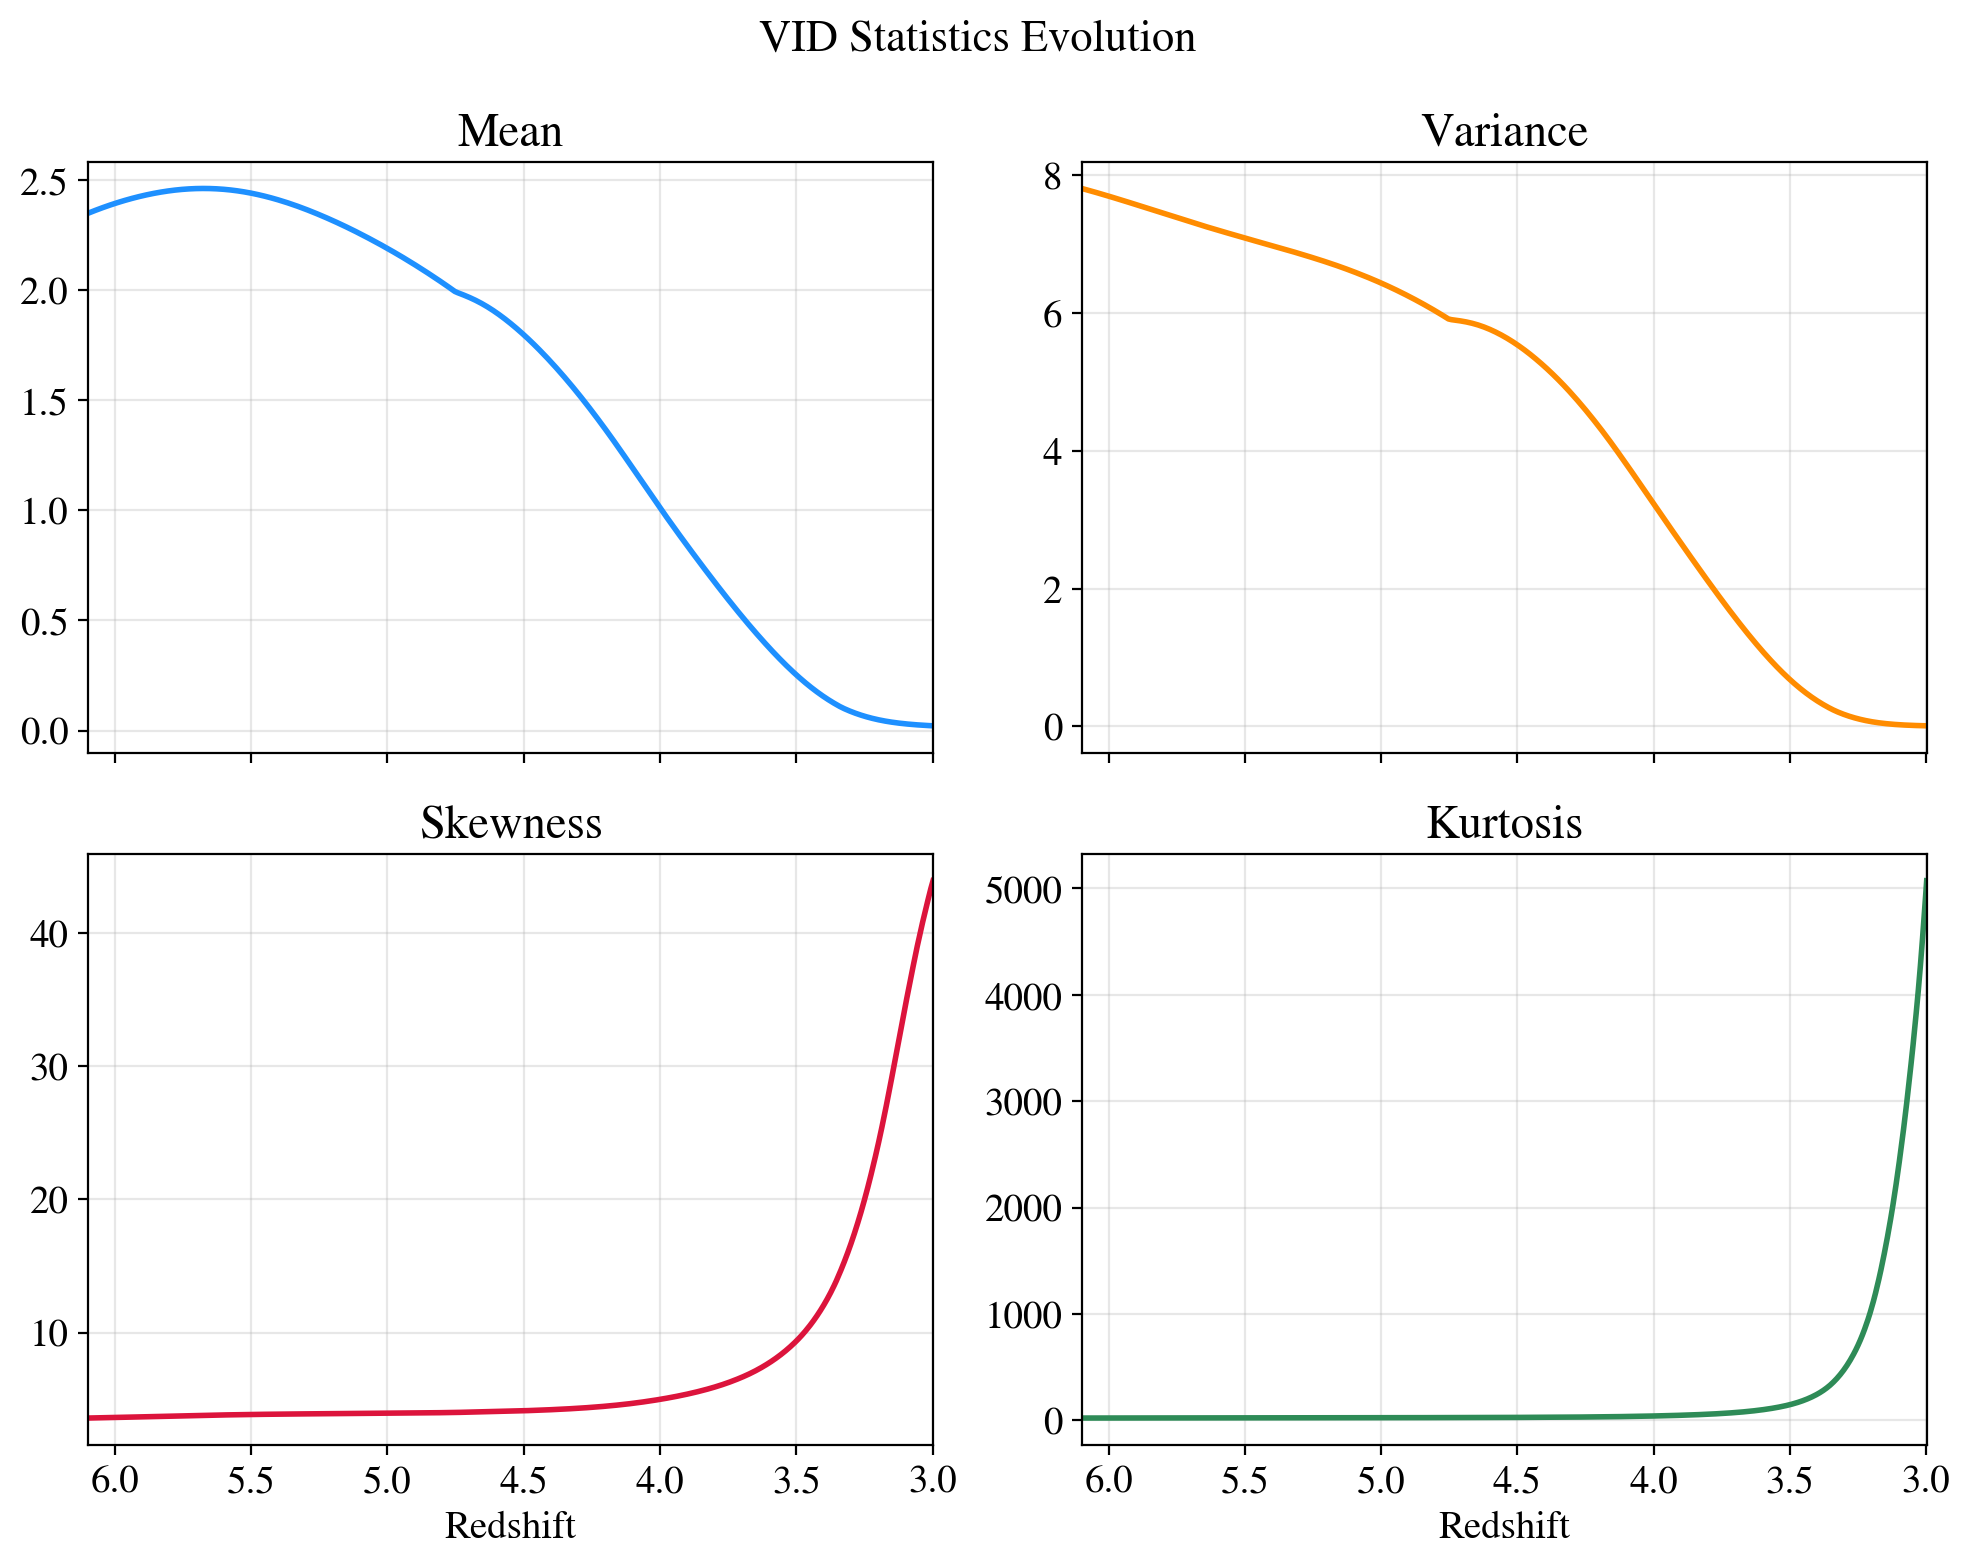

In [6]:

# =====================================
# Plot
# =====================================
#df = pd.read_csv("vid_stats_summary_He.csv")
z = df["z"]

colors = {
    "mean": "dodgerblue",
    "variance": "darkorange",
    "skewness": "crimson",
    "kurtosis": "seagreen"
}

fig, axes = plt.subplots(2, 2, figsize=(10,8), sharex=True)
axes = axes.flatten()

labels = ["Mean", "Variance", "Skewness", "Kurtosis"]
cols   = ["mean", "variance", "skewness", "kurtosis"]
markers = ["o", "s", "^", "D"]

for ax, col, label, m in zip(axes, cols, labels, markers):

    ax.plot(
        z,
        df[col],
        #marker=m,
        color=colors[col],
        linewidth=2
    )

    ax.set_title(label)
    ax.grid(alpha=0.3)

    # Force redshift direction (high → low)
    ax.set_xlim(max(z), min(z))

# Labels
axes[2].set_xlabel("Redshift")
axes[3].set_xlabel("Redshift")

# Optional: mark key epochs
#for ax in axes:
#    ax.axvline(7, linestyle="--", color="gray", alpha=0.5)
#    ax.axvline(6, linestyle="--", color="gray", alpha=0.5)

plt.suptitle("VID Statistics Evolution", fontsize=16)
plt.tight_layout()
plt.show()

--- 
## Dummy

In [19]:
import os
import h5py
import glob
import numpy as np
import pandas as pd
import math
from scipy.integrate import quad
from astropy import constants as const
from scipy.interpolate import interp1d
from scipy.interpolate import CubicSpline

from scipy.signal import savgol_filter

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['savefig.dpi'] = 300

import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 14,
})
import cmasher as cmr
import gc
gc.collect()

42714

In [ ]:
import numpy as np
import h5py
from scipy.stats import skew, kurtosis

def calculate_vid(hdf5_file, resolution_cMpc, bins=1000):
    """
    Compute voxel intensity distribution (VID)

    Returns:
    - bin_centers
    - vid_prob      (normalized PDF)
    - vid_physical  (dN/dT/dV)
    - stats
    """

    # -----------------------------------
    # Load data
    # -----------------------------------
    with h5py.File(hdf5_file, "r") as f:
        tb_cube = f["rin"][:]   # adjust if needed

    voxels = tb_cube.flatten()

    # -----------------------------------
    # Stats
    # -----------------------------------
    stats = {
        'mean': np.mean(voxels),
        'variance': np.var(voxels),
        'skewness': skew(voxels),
        'kurtosis': kurtosis(voxels)
    }

    # -----------------------------------
    # Histogram (raw counts)
    # -----------------------------------
    counts, bin_edges = np.histogram(voxels, bins=bins, density=False)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    dT = bin_edges[1] - bin_edges[0]

    # -----------------------------------
    # Probability VID
    # -----------------------------------
    vid_prob = counts / (len(voxels) * dT)

    # -----------------------------------
    # Physical VID
    # -----------------------------------
    voxel_volume = resolution_cMpc**3
    total_volume = len(voxels) * voxel_volume

    vid_physical = counts / (dT * total_volume)

    return bin_centers, vid_prob, vid_physical, stats

import matplotlib.pyplot as plt

def plot_vid(bin_centers, vid_prob, vid_physical, z, stats=None):
    """
    Plot voxel intensity distribution with redshift annotation

    Parameters:
    - bin_centers: array
    - vid_prob: normalized PDF
    - vid_physical: dN/dT/dV
    - z: redshift
    - stats: optional dict
    """

    fig = plt.figure(figsize=(8,6))

    # -----------------------------------
    # Plot
    # -----------------------------------
    plt.plot(bin_centers, vid_prob, label="Probability VID")
    #plt.plot(bin_centers, vid_physical, linestyle='--', label="Physical VID")

    # -----------------------------------
    # Labels
    # -----------------------------------
    plt.xlabel("Brightness Temperature $T_b$")
    plt.ylabel("VID")

    plt.xscale("log")
    plt.yscale("log")

    plt.xlim(-50, 260)
    plt.ylim(1.0e-9, 1.0)
    plt.grid(True, alpha=0.3)

    # -----------------------------------
    # Title with redshift
    # -----------------------------------
    plt.title(f"Voxel Intensity Distribution (z = {z:.2f})")

    #plt.legend()

    # -----------------------------------
    # Stats box (top-left)
    # -----------------------------------
    if stats is not None:
        textstr = (
            f"z = {z:.2f}\n"
            f"Mean = {stats['mean']:.3e}\n"
            f"Var = {stats['variance']:.3e}\n"
            f"Skew = {stats['skewness']:.3f}\n"
            f"Kurt = {stats['kurtosis']:.3f}"
        )

        plt.text(0.02, 0.98, textstr,
                 transform=plt.gca().transAxes,
                 verticalalignment='top',
                 fontsize=10,
                 bbox=dict(boxstyle="round", alpha=0.2))
    
    plt.tight_layout()
    plt.show()

def get_redshift(ps_file):
    with open(ps_file) as f:
        return float(f.readline().strip())

PS_files = [
    "./TS_TK/H/Tb/PS_Tb_H_156.out",
    "./TS_TK/H/Tb/PS_Tb_H_181.out",
    "./TS_TK/H/Tb/PS_Tb_H_209.out",
    "./TS_TK/H/Tb/PS_Tb_H_255.out",
    "./TS_TK/H/Tb/PS_Tb_H_289.out",
    "./TS_TK/H/Tb/PS_Tb_H_325.out",
    "./TS_TK/H/Tb/PS_Tb_H_364.out",
    "./TS_TK/H/Tb/PS_Tb_H_406.out",
]

voxel_res = 500/640

for PS_file in PS_files:
    
    # Extract snapshot number from filename
    snap = int(PS_file.split("_")[-1].split(".")[0])
    
    # Build matching HDF5 file path
    hdf5_file = f"/orcd/data/mvogelsb/004/chcho/PS_21cm/TS_TK/H/Tb/Tb_H_{snap:03d}.hdf5"
    
    # Get redshift
    z = get_redshift(PS_file)
    
    # Run VID
    bin_centers, vid_pdf, stats, voxels = calculate_vid(
        hdf5_file=hdf5_file,
        resolution_cMpc=voxel_res,
        bins=1000
    )
    
    # Plot each snapshot separately
    plot_vid(bin_centers, vid_pdf, stats, z=z)